# SENDAs Agreement 1 Update 2010-2022 (Prediction, step 2.1, full models)

This notebook was converted automatically from `prediction21.qmd`.
Quarto-specific YAML/options were preserved in the first raw cell; some chunk options remain as comments inside code cells.

<style type="text/css">
.showopt {
background-color: #004c93; color: #FFFFFF; width: 100px; height: 20px; text-align: center; vertical-align: middle !important; float: right; font-family: sans-serif; border-radius: 8px;
}
.showopt:hover {
background-color: #dfe4f2;
color: #004c93;
}
pre.plot {
background-color: white !important;
}
.tablelines table, .tablelines td, .tablelines th {
border: 1px solid black;
}
.centrado {
text-align: center;
}
.table.center {
margin-left:auto;
margin-right:auto;
}
/* https://vivekjaiskumar.medium.com/css-is-and-not-selector-17c942ec83f :is()*/
/* Applies to outputs that are not code other than R*/
pre {
overflow-x: auto !important;
}
pre code {
word-wrap: normal !important;
white-space: pre !important;
}
/*
pre:not(.sourceCode) {
white-space: nowrap !important;
}
*/
.sourceCode { /* Important gives precedence */
font-size: 10px !important;
line-height: 50% !important;
}
body{ /* Normal */
text-align: justify;
}
.superbigimage{
overflow-y:scroll;
height:350px;
white-space: nowrap;
overflow-x: auto;
width:100%;
}
.superbigimage img{
overflow-y: scroll;
overflow-x: hidden;
}
.message { color:#446C6E; font-family: monospace;font-size: 10px; line-height: 110%; font-weight: bold;}
div.blue { background-color:#e6f0ff; border-radius: 5px; padding: 5px; text-align: justify;}
div.red { background-color:#e6bab1; border-radius: 5px; padding: 5px; text-align: justify;}
.pandoc-table { /* Should add !important; but it seems no necessary */
margin-left:auto; /* To center */
margin-right:auto;
border-collapse: collapse;
table-layout: auto;
font-size: 11px;
overflow-y: auto;
max-height:450px !important;
white-space: nowrap;
overflow-x: auto;
width:450px;
}
.pandoc-table th {/* header */
text-align: center !important;
font-size: 10px;
padding: 0px;
}
.pandoc-table td {
text-align: left !important;
font-size: 9px;
padding: 0px;
}
.pandoc-table caption {
text-align: left !important;
font-size: 11px !important;
}
.center-table {
text-align: left !important;
font-size: 9px;
overflow-y:scroll;
height:450px;
overflow-x: scroll;
}
.controlly{
overflow-y:scroll;
height:350px;
overflow-x: scroll;
}
/*2025-03-07*/
.callout-warning,
.callout-error,
.callout-message {
  font-size: 0.7rem !important;  /* Adjust this value as needed */
}
.alert, .message {
    font-size: 0.7em !important;
}
.alert.alert-warning,
.alert.alert-danger,
.message {
    font-size: 0.7em !important;
}
</style>

<style>
#| label: css-format
h1 {
    color: var(--heading-color);
    font-size: 2rem;
    margin-bottom: 1vh;
}
p {
  font-size: 1.1rem;
  line-height: 1.6rem;
}
a {
  color: var(--primary-color);
  text-decoration: none;
  border-bottom: 3px solid transparent;
  font-weight: bold;
  &:hover, &:focus {
      border-bottom: 3px solid currentColor;
  }
}
section {
  margin: 0 auto;
}
.post-meta {
  font-size: 1rem;
  font-style: italic;
  display: block;
  margin-bottom: 4vh;
  color: var(--secondary-color);
}
nav {
  display: flex;
  justify-content: flex-end;
  padding: 20px 0;
}
/*slider switch css */
.theme-switch-wrapper {
  display: flex;
  align-items: center;
  
  em {
    margin-left: 10px;
    font-size: 1rem;
  }
}
.theme-switch {
  display: inline-block;
  height: 34px;
  position: relative;
  width: 60px;
}
.theme-switch input {
  display:none;
}
.slider {
  background-color: #ccc;
  bottom: 0;
  cursor: pointer;
  left: 0;
  position: absolute;
  right: 0;
  top: 0;
  transition: .4s;
}
.slider:before {
  background-color: #fff;
  bottom: 4px;
  content: "";
  height: 26px;
  left: 4px;
  position: absolute;
  transition: .4s;
  width: 26px;
}
input:checked + .slider {
  background-color: #66bb6a;
}
input:checked + .slider:before {
  transform: translateX(26px);
}
.slider.round {
  border-radius: 34px;
}
.slider.round:before {
  border-radius: 50%;
}
</style>

<script>
function myFunction1() {
var x = document.getElementById("myDIV");
if (x.style.display === "none") {
x.style.display = "block";
} else {
x.style.display = "none";
}
}
</script>
<script>
function myFunction2() {
var x = document.getElementById("myDIV2");
if (x.style.display === "none") {
x.style.display = "block";
} else {
x.style.display = "none";
}
}
</script>

<style>
.scrollable-content {
  max-height: 350px;
  overflow-y: auto;
}
pre.scrollable-code {
  max-height: 350px;
  overflow-y: auto;
}
.superbigimage {
  overflow-x: scroll;
  white-space: nowrap;
}
.superbigimage img, 
.superbigimage svg {
  max-width: none;
  height: auto;
}
</style>
<br>

# Data Loading and Exploration

## Loading Packages and uniting databases

<div class="scrollable-content">

In [1]:
#| label: load
#| message: false
#| include: true
#| warning: false
#| results: "hold"
# invisible("Only run from Ubuntu")
# if (!(Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv"))) {
#   if(Sys.info()["sysname"]!="Windows"){
#     Sys.setenv(RETICULATE_PYTHON = "/home/fondecytacc/.pyenv/versions/3.11.5/bin/python")
#   }
# }

unlink("_freeze", recursive = TRUE)
unlink("*_cache", recursive = TRUE)

#clean enviroment
rm(list = ls()); gc()
time_before_dedup2<-Sys.time()
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Busca .mamba_root/envs/py311/python.exe desde getwd() hacia padres
# find_python_rel <- function(start = getwd(),
#                            rel = file.path(".mamba_root","envs","py311","python.exe")) {
#  cur <- normalizePath(start, winslash = "/", mustWork = FALSE)
#  repeat {
#    cand <- normalizePath(file.path(cur, rel), winslash = "/", mustWork = FALSE)
#    if (file.exists(cand)) return(cand)
#    parent <- dirname(cur)
#    if (identical(parent, cur)) return(NA_character_)  # llegó a la raíz
#    cur <- parent
#  }
# }
# --- Bootstrap reticulate con ruta relativa a getwd() ---
# if(Sys.info()["sysname"]!="Windows"){
#  Sys.setenv(RETICULATE_PYTHON = "usr/bin/python3")
#  reticulate::py_config()
# } else {
#  py <- find_python_rel()
#  if (is.na(py)) {
#    stop("No se encontró Python relativo a getwd() (buscando '.mamba_root/envs/py311/python.exe').\n",
#         "Directorio actual: ", getwd())
#  }
#  # Forzar ese intérprete
#  Sys.unsetenv(c("RETICULATE_CONDAENV","RETICULATE_PYTHON_FALLBACK"))
#  Sys.setenv(RETICULATE_PYTHON = py)
#  #reticulate::use_python(py, required=T)
#  reticulate::py_config()  # verificación
# }
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# --- Load pred1_ndp_2026_01_05.Rdata (simple, project-root aware, no functions) ---
# 1) Locate the file anywhere under the project root (current WD with a trailing "/cons" trimmed)
project_root <- sub("(/)?cons/?$", "", normalizePath(getwd(), winslash = "/", mustWork = FALSE))
fname        <- "pred1_ndp_2026_01_05.Rdata"
hits <- list.files(project_root, pattern = paste0("^", fname, "$"),
                   recursive = TRUE, full.names = TRUE, ignore.case = TRUE)
if (!length(hits)) stop("File not found: ", fname, "\nSearched under: ", project_root)
path <- hits[1]  # take first match
message("Loading: ", path)
# 2) Load into a dedicated environment (keeps .GlobalEnv clean)
env_pred <- new.env(parent = emptyenv())
loaded_objects <- load(path, envir = env_pred)
message("Loaded ", length(loaded_objects), " object(s): ", paste(loaded_objects, collapse = ", "))
# 3) Quick sanity check for each loaded object
for (obj_name in loaded_objects) {
  obj <- get(obj_name, envir = env_pred)
  message("\n--- ", obj_name, " ---")
  if (is.data.frame(obj)) {
    message("Rows: ", nrow(obj), " | Cols: ", ncol(obj))
  } else {
    message("Class: ", paste(class(obj), collapse = ", "), " | Length/Size: ", length(obj))
  }
  #print(str(obj))
}
# 4) Extract all loaded objects to global environment
for (obj_name in loaded_objects) {
  assign(obj_name, get(obj_name, envir = env_pred), envir = .GlobalEnv)
}
# Clean up temporary environment
rm(env_pred)
# (Optional) If you want it in the global env, uncomment:
# list2env(env_prev1y, envir = .GlobalEnv)

Loading: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred1_ndp_2026_01_05.Rdata


by .GlobalEnv when processing object ‘.QuartoInlineRender’
by .GlobalEnv when processing object ‘p’
by .GlobalEnv when processing object ‘p’


Loaded 154 object(s): km_df, icd10_broad, table_one_clean, dummified_lvls_vars, get_all_oobs, n0_runs, wdpath, m4_cases_red, lab_post_orig_clean, time_before_dedup2, check_docker_running, ci2, mode_pick_int, sesion_info, factor_vars, fname, decrypt_column, t_grid, series_dummies, sf_c1, sf_c2, n0_cases, key_exists, lab_proc, m4_runs_red, safe_min_where_int, gr, infectious_set, categorical_vars, .QuartoInlineRender, .start_date, lab_post_orig, lab_orig_clean, classify_dx_vec, num_vars, labels_map, toString2, lab_flag, pair_str, n_patients_meet, n_drop_predeath, extra_num, py, imputed_data, hits, is_stata_ok, df23_ndp_20250824_SISTRAT23_c1_1024, lab_discard_first, numerical_vars2, escape_regex, m3_cases, get_cif_by_code, safe_min_where_date, SISTRAT23_c1_2010_2024_df_model, extra_cat, lab_final, cif_d_after, envpath, .Random.seed, t_end, cif_d_before, most_frequent, corrected_datasets, safe_min_date, m3, lab_orig, SISTRAT23_c1_2010_2024_df_prev1t, m4, format_cells, pat, ftime_first, dumm

In [ ]:
options(jupyter.max_output_size = Inf)

In [6]:
project_root

[1] "G:/My Drive/Alvacast/SISTRAT 2023"

In [9]:
Sys.setenv(RENV_PROJECT = project_root)
source(paste0(project_root,"/renv/activate.R"))
getwd()
Sys.getenv("RENV_PROJECT")

unlink("renv/staging", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/geepack", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/V8", recursive = TRUE, force = TRUE)

- Project 'G:/My Drive/Alvacast/SISTRAT 2023' loaded. [renv 1.1.5]


In [ ]:
renv::status()
renv::restore(exclude = c("polars"))

No issues found -- the project is in a consistent state.


In [ ]:
#| label: setup
#| results: "hold"
#renv falls back to copying rather than symlinking, which is evidently very slow in this configuration.
renv::settings$use.cache(FALSE)
#only use explicit dependencies (in DESCRIPTION)
renv::settings$snapshot.type("implicit")
#check if rstools is installed
if(Sys.info()["sysname"]=="Windows"){
try(installr::install.Rtools(check_r_update=F))
}
check_quarto_version <- function(required = "1.7.29", comparator = c("ge","gt","le","lt","eq")) {
  comparator <- match.arg(comparator)
  current <- package_version(paste(unlist(quarto::quarto_version()), collapse = "."))
  req     <- package_version(required)
  ok <- switch(comparator,
               ge = current >= req,
               gt = current >  req,
               le = current <= req,
               lt = current <  req,
               eq = current == req)
  if (!ok) {
    stop(sprintf("Quarto version check failed: need %s %s (installed: %s).",
                 comparator, required, current), call. = FALSE)
  }
  invisible(TRUE)
}
check_quarto_version("1.7.29", "ge") 
#change repository to CL
local({
  r <- getOption("repos")
  r["CRAN"] <- "https://cran.dcc.uchile.cl/"
  options(repos=r)
})
if(!require(pacman)){install.packages("pacman");require(pacman)}
if(!require(pak)){install.packages("pak");require(pak)}
pacman::p_unlock(lib.loc = .libPaths()) #para no tener problemas reinstalando paquetes
if(Sys.info()["sysname"]=="Windows"){
if (getRversion() != "4.4.1") { stop("Requires R version 4.4.1; Actual: ", getRversion()) }
}
#check docker
check_docker_running <- function() {
  # Try running 'docker info' to check if Docker is running
  system("docker info", intern = TRUE, ignore.stderr = TRUE)
}
if(Sys.info()["sysname"]=="Windows"){
  install_docker <- function() {
    # Open the Docker Desktop download page in the browser for installation
    browseURL("https://www.docker.com/products/docker-desktop")
  }
  # Main logic
  if (inherits(try(check_docker_running(), silent = TRUE), "try-error")) {
    liftr::install_docker()
  } else {
    message("Docker is running.")
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#PACKAGES#######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
unlink("*_cache", recursive=T)
pak::pak_sitrep()
# pak::sysreqs_check_installed(unique(unlist(paks)))
#pak::lockfile_create(unique(unlist(paks)),  "dependencies_duplicates24.lock", dependencies=T)
#pak::lockfile_install("dependencies_duplicates24.lock")
#https://rdrr.io/cran/pak/man/faq.html
#pak::cache_delete()
library(tidytable)
library(ggplot2)
library(readr)
library(tableone)
library(survivalmodels)
#renv::install("patchwork@1.2.0")
library(rms)
library(survidm)
library(caret)
library(survival)
library(caret)
library(dplyr)
library(survex)
library(pec)
library(future)
library(future.apply)
library(parallel)
library(mice)
library(riskRegression)
library(tidyr)
library(doFuture)
library(vcd)
library(survAUC)

if(!require(future.callr)){install.packages("future.callr")}

#flexsurv
#if(!require(compareCstat)){install.pacakges("compareCstat")}
# library(shapr)#https://norskregnesentral.github.io/shapr/
# library(SemiMarkov)#https://www.degruyterbrill.com/document/doi/10.1515/ijb-2020-0083/html?lang=en
# #https://www.jclinepi.com/article/S0895-4356(24)00142-2/fulltext
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 3. Activate polars code completion (safe to try even if it fails)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
#try(polars_code_completion_activate())
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 4. BPMN from GitHub (not on CRAN, so install via devtools if missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
if (!requireNamespace("bpmn", quietly = TRUE)) {
  devtools::install_github("bergant/bpmn")
}
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 5. PhantomJS Check (use webshot if PhantomJS is missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# if (!webshot::is_phantomjs_installed()) {
#   webshot::install_phantomjs()
# }
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#FUNCTIONS######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
# NO MORE DEBUGS
options(error = NULL)        # si antes tenías options(error = recover) o browser)
options(browserNLdisabled = FALSE)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#NAs are replaced with "" in knitr kable
options(knitr.kable.NA = '')
pander::panderOptions('big.mark', ',')
pander::panderOptions('decimal.mark', '.')
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#to format rows in bold
format_cells <- function(df, rows ,cols, value = c("italics", "bold", "strikethrough")){
  # select the correct markup
  # one * for italics, two ** for bold
  map <- setNames(c("*", "**", "~~"), c("italics", "bold", "strikethrough"))
  markup <- map[value]  
  for (r in rows){
    for(c in cols){
      # Make sure values are not factors
      df[[c]] <- as.character( df[[c]])
      # Update formatting
      df[r, c] <- ifelse(nchar(df[r, c])==0,"",paste0(markup, gsub(" ", "", df[r, c]), markup))
    }
  }
  return(df)
}
#To produce line breaks in messages and warnings
knitr::knit_hooks$set(
   error = function(x, options) {
     paste('\n\n<div class="alert alert-danger" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Error', '**Error**', x)),
           '</div>', sep = '\n')
   },
   warning = function(x, options) {
     paste('\n\n<div class="alert alert-warning" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Warning:', '**Warning**', x)),
           '</div>', sep = '\n')
   },
   message = function(x, options) {
     paste('<div class="message" style="font-size: small !important;">',
           gsub('##', '\n', x),
           '</div>', sep = '\n')
   }
)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
sum_dates <- function(x){
  cbind.data.frame(
    min= as.Date(min(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01"),
    p001= as.Date(quantile(unclass(as.Date(x)), .001, na.rm=T), origin = "1970-01-01"),
    p005= as.Date(quantile(unclass(as.Date(x)), .005, na.rm=T), origin = "1970-01-01"),
    p025= as.Date(quantile(unclass(as.Date(x)), .025, na.rm=T), origin = "1970-01-01"),
    p25= as.Date(quantile(unclass(as.Date(x)), .25, na.rm=T), origin = "1970-01-01"),
    p50= as.Date(quantile(unclass(as.Date(x)), .5, na.rm=T), origin = "1970-01-01"),
    p75= as.Date(quantile(unclass(as.Date(x)), .75, na.rm=T), origin = "1970-01-01"),
    p975= as.Date(quantile(unclass(as.Date(x)), .975, na.rm=T), origin = "1970-01-01"),
    p995= as.Date(quantile(unclass(as.Date(x)), .995, na.rm=T), origin = "1970-01-01"),
    p999= as.Date(quantile(unclass(as.Date(x)), .999, na.rm=T), origin = "1970-01-01"),
    max= as.Date(max(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01")
  )
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Define the function adapted for Polars
sum_dates_polars <- function(df, date_col) {
  # Create the list of quantiles
  quantiles <- c(0.001, 0.005, 0.025, 0.25, 0.5, 0.75, 0.975, 0.995, 0.999)
  # Create expressions to calculate min and max
  expr_list <- list(
    pl$col(date_col)$min()$alias("min"),
    pl$col(date_col)$max()$alias("max")
  )
  # Add expressions for quantiles
  for (q in quantiles) {
    expr_list <- append(expr_list, pl$col(date_col)$quantile(q)$alias(paste0("p", sub("\\.", "", as.character(q)))))
  }
  # Apply the expressions and return a DataFrame with the results
  df$select(expr_list)
}
# Custom function for sampling with a seed
sample_n_with_seed <- function(data, size, seed) {
  set.seed(seed)
  dplyr::sample_n(data, size)
}
# Function to get the most frequent value 
most_frequent <- function(x) { 
  uniq_vals <- unique(x)
  freq_vals <- sapply(uniq_vals, function(val) sum(x == val))
  most_freq <- uniq_vals[which(freq_vals == max(freq_vals))]
  
  if (length(most_freq) == 1) {
    return(most_freq)
  } else {
    return(NA)
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#CONFIG #######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
options(scipen=2) #display numbers rather scientific number
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# Define the function first
#joins these values with semicolons and optionally truncates the result if it exceeds a specified width.
toString2 <- function(x, width = NULL, ...) {
    string <- paste(x, collapse = "; ")
    if (missing(width) || is.null(width) || width == 0) 
        return(string)
    if (width < 0) 
        stop("'width' must be positive")
    if (nchar(string, type = "w") > width) {
        width <- max(6, width)
        string <- paste0(substr(string, 1, width - 3), "...")
    }
    string
}
normalize_txt <- function(x) {
  x|>
    stringi::stri_trans_general("Latin-ASCII")|>
    tolower()|>
    trimws()
}
pair_str <- function(main, sub) {
  main <- as.character(main)
  sub  <- as.character(sub)
  both_na <- is.na(main) & is.na(sub)
  out <- paste0(
    tidytable::coalesce(main, "NA"),
    "::",
    tidytable::coalesce(sub,  "NA")
  )
  out[both_na] <- NA_character_
  out
}
# ── Helpers ────────────────────────────────────────────────────────────
mode_pick_int <- function(x){
  x <- x[!is.na(x)]
  if(length(x)==0) return(NA_integer_)
  tx <- sort(table(x), decreasing = TRUE)
  as.integer(names(tx)[1L])
}
subkey_to_label <- function(x){
  y <- gsub("_"," ", tolower(x))
  y <- gsub("amphetamine type stimulants","amphetamine-type stimulants", y)
  y <- gsub("tranquilizers hypnotics","tranquilizers/hypnotics", y)
  y
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Encryption ────────────────────────────────────────────────────────
# Pack: [24-byte nonce][ciphertext] -> hex
encrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        ct <- sodium::data_encrypt(charToRaw(as.character(v)), key)
        nonce <- attr(ct, "nonce")                 # 24 bytes
        sodium::bin2hex(c(nonce, ct))              # pack nonce + ct
    }, FUN.VALUE = character(1))
}
# Unpack: hex -> [nonce|ciphertext], restore attr(nonce), then decrypt
decrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        buf <- sodium::hex2bin(v)
        if (length(buf) < 25L) stop("Ciphertext too short or corrupted.")
        nonce <- buf[1:24]
        ct    <- buf[-(1:24)]
        attr(ct, "nonce") <- nonce
        rawToChar(sodium::data_decrypt(ct, key))
    }, FUN.VALUE = character(1))
}
# Function to encrypt a character vector
encrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item) || item == "") {
      return(NA_character_)
    }
    encrypted_raw <- sodium::data_encrypt(charToRaw(item), key)
    base64enc::base64encode(encrypted_raw)  # Convert to base64 for storage
  }, USE.NAMES = FALSE)
}
decrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item)) return(NA_character_)
    encrypted_raw <- base64enc::base64decode(item)
    rawToChar(sodium::data_decrypt(encrypted_raw, key))
  }, USE.NAMES = FALSE)
}
is_stata_ok <- function(x) {
  nchar(x) <= 32 & grepl("^[A-Za-z][A-Za-z0-9_]*$", x)
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Tidy RMS ────────────────────────────────────────────────────────
tidy_cph <- function(model) {
  if (!inherits(model, "cph")) stop("Model must be an rms::cph object")
  
  # run summary
  s <- summary(model)
  df_s <- as.data.frame(unclass(s))
  df_s$rown <- rownames(s)
  
  # find rows that are "Hazard Ratio"
  hr_rows <- trimws(df_s$rown) == "Hazard Ratio"
  
  # build tidy tibble
  tibble::tibble(
    term     = trimws(rownames(s)[which(hr_rows) - 1L]), # previous row = variable name
    estimate = df_s$Effect[hr_rows],                     # Hazard Ratio
    conf.low = df_s$`Lower 0.95`[hr_rows],
    conf.high= df_s$`Upper 0.95`[hr_rows],
    p.value  = df_s$P[hr_rows]
  )
}

#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
find_latest_file <- function(project_root, prefix) {
  # Get all files matching the pattern
  pattern <- paste0(prefix, "_\\d{8}_\\d{4}\\.csv$")
  files <- list.files(
    path = project_root,
    pattern = pattern,
    full.names = TRUE
  )
  if (length(files) == 0) {
    stop(paste("No files found matching pattern:", pattern))
  }
  # Extract timestamps from filenames (format: YYYYMMDD_HHMM)
  extract_timestamp <- function(filename) {
    matches <- regmatches(
      basename(filename),
      gregexpr("\\d{8}_\\d{4}", basename(filename))
    )
    if (length(matches[[1]]) == 0) {
      return(NA)
    }
    timestamp_str <- matches[[1]][length(matches[[1]])]
    return(timestamp_str)
  }
  timestamps <- sapply(files, extract_timestamp)
  # Remove any files where timestamp extraction failed
  valid_idx <- !is.na(timestamps)
  files <- files[valid_idx]
  timestamps <- timestamps[valid_idx]
  if (length(files) == 0) {
    stop("No valid timestamps found in filenames")
  }
  # Sort by timestamp (descending) and return the latest
  latest_idx <- order(timestamps, decreasing = TRUE)[1]
  return(files[latest_idx])
}

Installing package into ‘G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32’
(as ‘lib’ is unspecified)


trying URL 'https://packagemanager.posit.co/cran/latest/bin/windows/contrib/4.4/pkgbuild_1.4.8.zip'
Content type 'binary/octet-stream' length 211749 bytes (206 KB)
downloaded 206 KB



package ‘pkgbuild’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\andre\AppData\Local\Temp\RtmpC6c9zP\downloaded_packages
Loading required package: pkgbuild
No need to install Rtools - You've got the relevant version of Rtools installed
Loading required package: pacman
Loading required package: pak

No 00LOCK detected in:
 G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
No 00LOCK detected in:
 C:/Users/andre/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43
Docker is running.


Warning message:
In system("docker info", intern = TRUE, ignore.stderr = TRUE) :
  running command 'docker info' had status 1


* pak version:
- 0.8.0.1
* Version information:
- pak platform: x86_64-w64-mingw32 (current: x86_64-w64-mingw32, compatible)
- pak repository: - (local install?)
* Optional packages installed:
- pillar
* Library path:
- G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
- C:/Users/andre/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43
* pak is installed at G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32/pak.
* Dependency versions:
- callr      3.7.6      
- cli        3.6.2      
- curl       5.2.1      
- desc       1.4.3      
- filelock   1.0.3      
- jsonlite   1.8.8      
- lpSolve    5.6.23.9000
- pkgbuild   1.4.4      
- pkgcache   2.2.2.9000 
- pkgdepends 0.7.2.9000 
- pkgsearch  3.1.3.9000 
- processx   3.8.4      
- ps         1.7.6      
- R6         2.5.1      
- zip        2.3.1      
* Dependencies can be loaded

Attaching package: ‘tidytable’

The following objects are masked from

In [ ]:
# Define project root
# 'here' siempre apunta a la carpeta que contiene el archivo .Rproj
root <- here::here()

# Si necesitas la ruta "padre" de /cons (como haces en tu script):
project_root <- gsub("/cons$", "", root) 

# Definir carpetas de salida de forma relativa
data_out <- file.path(project_root, "data", "20241015_out")
figs_out <- file.path(root, "_figs")

<br>

::: {.callout-note}
**Aims**
- To identify key prognostic and predictive factors associated with the risk of, and time to, the first readmission to treatment among patients aged 18-64 undergoing initial treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
- To identify key prognostic and predictive factors associated with the risk of, and time to, all-cause mortality among the same cohort of patients undergoing initial treatment for SUD in Chile.
- To predict the risk and timing of first treatment readmission and all-cause mortality simultaneously, treating these outcomes within a semi-competing risks framework. This will allow for the estimation of cumulative incidence for each event in the presence of the other for patients aged 18-64 who initiated SUD treatment in Chile between 2010 and 2020.
This study has three primary objectives. First, we aim to identify key prognostic and predictive factors associated with the risk and timing of two critical outcomes: (i) first readmission to treatment and (ii) all-cause mortality. Second, using a semi-competing risks framework, we will develop a model to simultaneously predict these two outcomes, accounting for the fact that death precludes the possibility of readmission. Finally, this model will be used to estimate the probability of various patient trajectories over time following initial treatment. The study population includes all patients aged 18-64 who began treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
:::
<br>

## 0. Prepare data

In this step, we imported the center identifiers and then applied a correction procedure across all imputed datasets to ensure consistency in event-time definitions. Specifically, we converted time and event variables to numeric and integer formats, identified cases where death occurred before or at the readmission endpoint (competing risks), and adjusted follow‑up times and event indicators accordingly by censoring readmission in those situations. After cleaning up temporary variables, we added the center ID as a factor to each dataset. We also excluded `high_uncertainty_imps`, which encompassed predictors with were not reliable. Finally, we exported the corrected datasets both individually as `.parquet` files named as `corrected_datasets_nondum` (nondum= not-dummified) and collectively as a single `.Rds` object, creating a clean and reproducible output ready for downstream analyses.

In [14]:
#| label: prepare-data
#| echo: true
#| error: false
#| warning: true
#| message: true
#| paged.print: true
#| results: "hold"
#| eval: true

id_centro_vec <- rio::import(paste0(data_out, "/pred1/id_centro.Rds"))

# 1. Apply Correction to Each Dataset in the List
corrected_datasets_nondum <- map(filled_datasets, function(df) {
  # Ensure columns are numeric for comparison
  df <- df|> 
    mutate(
      readmit_time = as.numeric(readmit_time_from_disch_m),
      death_time   = as.numeric(death_time_from_disch_m),
      # Ensure events are 0/1 integers
      readmit_event = as.integer(as.character(readmit_event)), 
      death_event   = as.integer(as.character(death_event))
    )
  # --- THE CORRECTION LOGIC ---
  df <- df|>
    dplyr::mutate(
      # condition: Patient died (death_event==1) AND death happened before (or at) the readmission endpoint
      is_competing_risk = (death_event == 1) & (death_time <= readmit_time),
      # 1. Update Time: If competing risk, cut follow-up at death time. Otherwise keep original.
      readmit_time_from_disch_m = dplyr::if_else(is_competing_risk, death_time, readmit_time),
      # 2. Update Event: If competing risk, censor readmission (set to 0). Otherwise keep original.
      readmit_event = dplyr::if_else(is_competing_risk, 0, readmit_event)
    )|>
    # Remove temporary helper columns if you want to keep the dataset clean
    dplyr::select(-readmit_time, -death_time, -is_competing_risk)|>
    dplyr::select(any_of(
      setdiff(c(num_vars, cat_vars, "readmit_event", "death_event", "readmit_time_from_disch_m","death_time_from_disch_m"), high_uncertainty_imps)
    ))|>
    dplyr::mutate(center_id= factor(id_centro_vec))
  return(df)
})

Warning message:
Missing `trust` will be set to FALSE by default for RDS in 2.0.0. 


# Split database

Assuming that `corrected_datasets_nondum` has not been modified since its last update on February 21, the order of the relevant rows in the dataset should remain unchanged (n=88,504). Therefore, the train–test split should be identical to the one used in Python. For this reason, we loaded `death_split_seed2125_test20.parquet` to partition observations into training and test sets.

In [16]:
#| label: import-parquet

split2125<- 
nanoparquet::read_parquet(paste0(project_root, "/cons/_out/comb_split_seed2125_test20_mar26.parquet"))

if(length(colnames(split2125))<4){
  stop("Loading an incomplete database without consistency checks")
  }

In [ ]:
# 2. Filter the dataset list
corrected_datasets_nondum_filt <- corrected_datasets_nondum |> 
  purrr::map(\(df) df |> 
    dplyr::mutate(esto= dplyr::case_when(grepl("adm reasons",tr_outcome) & death_event==1 & death_time_from_disch_m <= 0.23~"artifact", grepl("other", tr_outcome)~"other", T~NA_character_)) |> 
    dplyr::filter(is.na(esto)) |> 
    dplyr::select(-esto))

corrected_datasets_nondum[[1]] |> 
  dplyr::mutate(esto= dplyr::case_when(grepl("adm reasons",tr_outcome) & death_event==1 & death_time_from_disch_m <= 0.23~"artifact", grepl("other", tr_outcome)~"other", T~NA_character_)) |> 
  janitor::tabyl(esto) |> 
  knitr::kable("markdown", caption="Distribution of Excluded Observations")
#      esto     n     percent valid_percent
#  artifact   137 0.001547953     0.3892045
#     other   215 0.002429269     0.6107955
#      <NA> 88152 0.996022779            NA    
# 


[1] 88152

In [ ]:
nrow(corrected_datasets_nondum_filt[[1]])#88152

In [54]:
# Original Quarto chunk header: {r flowchart-paper1, echo=FALSE, fig.align="center", message=FALSE, warning=FALSE, dev.args=list(bg = "transparent"), fig.cap="Flowchart of cohort construction", out.width="450px"}

library(DiagrammeR)

# Labels
lab_orig <- paste0(
  "Original C1 Registry\\n",
  "(n = 259,395; Patients = 121,464)"
)

lab_orig_clean <- paste(
  "Pre-processing and quality checks",
  "&#8226; Remove exact duplicate records",
  "&#8226; Resolve overlapping episodes (keep longest / merge)",
  "&#8226; Correct inconsistent admission/discharge dates",
  "&#8226; Correct implausible birth dates/ages",
  "&#8226; Remove negative or implausible treatment duration",
  sep = "\\l"
)

lab_post_orig <- paste0(
  "Pre-processed C1 Registry\\n",
  "(n = 173,728; Patients = 121,299)"
)

lab_post_orig_clean <- paste(
  "Additional treatment harmonization",
  "&#8226; Collapse consecutive linked treatments",
  "  (gap <= 45 days and referral = yes)",
  sep = "\\l"
)

lab_proc <- paste0(
  "Cleaned and collapsed C1 Registry\\n",
  "(n = 162,897; Patients = 121,299)"
)

lab_flag <- "Chronologically ordered episodes\\n+ qualifying episode flag"

lab_discard_first <- paste(
  "Eligibility and episode selection",
  "&#8226; Adults aged 18-64 years",
  "&#8226; Admission between 2010 and 2020",
  "&#8226; Retained up to the second qualifying treatment episode",
  "&#8226; Third or later qualifying episodes set aside",
  paste0(
    "Episodes set aside: ",
    formatC(162897 - 107702, format = "f", digits = 0, big.mark = ",")
  ),
  paste0(
    "Patients with >=1 qualifying episode: ",
    formatC(88632, format = "f", digits = 0, big.mark = ",")
  ),
  sep = "\\l"
)

lab_after <- paste0(
  "Qualifying treatment episodes retained for outcome construction\\n",
  "(n = 107,702; Patients = 88,632)"
)

lab_discard_single <- paste(
  "One index episode per patient",
  "&#8226; Retained the first qualifying treatment episode",
  "&#8226; First subsequent qualifying admission used to define readmission",
  sep = "\\l"
)

lab_first_index <- paste0(
  "First qualifying treatment per patient\\n",
  "(n = 88,632; Patients = 88,632)"
)

lab_excl_final <- paste(
  "Final exclusions",
  "&#8226; Ongoing treatment at database closure: 128",
  "&#8226; Administratively incomplete episodes with indeterminate duration: 215",
  "&#8226; Temporal artifacts: 137",
  "   (administrative discharge within 7 days before death,",
  "    suggesting likely miscoding of discharge status)",
  sep = "\\l"
)

lab_final <- paste0(
  "Final modeling sample\\n",
  "(n = 88,152; Patients = 88,152)"
)

gr <- DiagrammeR::grViz(
  paste0(
'digraph flowchart {
  graph [layout = dot, rankdir = TB, bgcolor = "transparent"]

  node [fontname = "Times", shape = rectangle, fontsize = 28, style = filled, fillcolor = white]

  pre_original   [label = "', lab_orig, '", fillcolor = lightgray, shape = box]
  pre_clean      [label = "', lab_orig_clean, '", shape = note, fillcolor = white]

  pre2_original  [label = "', lab_post_orig, '", fillcolor = white, shape = box]
  pre2_clean     [label = "', lab_post_orig_clean, '", shape = note, fillcolor = lemonchiffon]

  original       [label = "', lab_proc, '", fillcolor = lightgray, shape = box]
  marked         [label = "', lab_flag, '", shape = box]
  after_rule     [label = "', lab_after, '", shape = box]
  first_index    [label = "', lab_first_index, '", shape = box]
  final_dataset  [label = "', lab_final, '", fillcolor = lightgray, shape = box]

  discard_first  [label = "', lab_discard_first, '", shape = note, fillcolor = mistyrose]
  discard_single [label = "', lab_discard_single, '", shape = note, fillcolor = mistyrose]
  discard_final  [label = "', lab_excl_final, '", shape = note, fillcolor = mistyrose]

  v00 [shape = point, width = 0, style = invis]
  v0  [shape = point, width = 0, style = invis]
  v1  [shape = point, width = 0, style = invis]
  v2  [shape = point, width = 0, style = invis]
  v3  [shape = point, width = 0, style = invis]
  v4  [shape = point, width = 0, style = invis]

  pre_original -> v00 [arrowhead = none]
  v00 -> pre2_original

  pre2_original -> v0 [arrowhead = none]
  v0 -> original

  original -> v1 [arrowhead = none]
  v1 -> marked

  marked -> v2 [arrowhead = none]
  v2 -> after_rule

  after_rule -> v3 [arrowhead = none]
  v3 -> first_index

  first_index -> v4 [arrowhead = none]
  v4 -> final_dataset

  v00 -> pre_clean      [color = black]
  v0  -> pre2_clean     [color = black]
  v2  -> discard_first  [color = black]
  v3  -> discard_single [color = black]
  v4  -> discard_final  [color = black]

  { rank = same; pre_clean; v00 }
  { rank = same; pre2_clean; v0 }
  { rank = same; discard_first; v2 }
  { rank = same; discard_single; v3 }
  { rank = same; discard_final; v4 }
}'
  ),
  width = 700,
  height = 1200
)

Exported the graph into png fortmat.

In [19]:
#| class-output: center-table
#| message: true
#| include: true
#| warning: true
#| error: true
#| label: post-flowchart2-exp
#| results: "hide"
#| fig.show: hide

unlink(paste0(gsub("/cons","",getwd()),"/cons/_figs/_flowchart_pred2_files"), recursive = TRUE)
htmlwidgets::saveWidget(gr, paste0(gsub("/cons","",getwd()),"/cons/_figs/_flowchart_pred2.html"))
webshot::webshot(paste0(gsub("/cons","",getwd()),"/cons/_figs/_flowchart_pred2.html"), 
                 paste0(gsub("/cons","",getwd()),"/cons/_figs/_flowchart_pred2.png"),
                 vwidth = 300, vheight = 300*1.5,  zoom=10, expand=100)  # Prueba con diferentes coordenadas top, left, width, and height

Registered S3 methods overwritten by 'callr':
  method                    from
  format.callr_status_error     
  print.callr_status_error      


In [ ]:
# R
out_html <- file.path(gsub("/cons","",getwd()), "cons/_figs/_flowchart_pred2.html")
html <- paste(readLines(out_html, warn = FALSE), collapse = "\n")
iframe <- htmltools::tags$iframe(srcdoc = html, style = "width:100%;height:700px;border:0;")
htmltools::browsable(iframe)
# En un chunk de knitr/Quarto: use cat(as.character(iframe)) con results='asis'

<iframe srcdoc="&lt;!DOCTYPE html&gt;&#10;&lt;html&gt;&#10;&lt;head&gt;&#10;&lt;meta charset=&quot;utf-8&quot; /&gt;&#10;&lt;title&gt;grViz&lt;/title&gt;&#10;&lt;script&gt;(function() {&#10;  // If window.HTMLWidgets is already defined, then use it; otherwise create a&#10;  // new object. This allows preceding code to set options that affect the&#10;  // initialization process (though none currently exist).&#10;  window.HTMLWidgets = window.HTMLWidgets || {};&#10;&#10;  // See if we&#39;re running in a viewer pane. If not, we&#39;re in a web browser.&#10;  var viewerMode = window.HTMLWidgets.viewerMode =&#10;      /\bviewer_pane=1\b/.test(window.location);&#10;&#10;  // See if we&#39;re running in Shiny mode. If not, it&#39;s a static document.&#10;  // Note that static widgets can appear in both Shiny and static modes, but&#10;  // obviously, Shiny widgets can only appear in Shiny apps/documents.&#10;  var shinyMode = window.HTMLWidgets.shinyMode =&#10;      typeof(window.Shiny) !== &

In [20]:
# 1. Read Python's split file
py_split <- split2125
cat("Python split:\n")
cat("Total rows:", nrow(py_split), "\n")
cat("Train:", sum(py_split$is_train), "\n")
cat("Test:", sum(!py_split$is_train), "\n\n")

# 2. Check your R data dimensions
cat("Your R data:\n")
cat("Rows in corrected_datasets_nondum_filt[[1]]:", nrow(corrected_datasets_nondum_filt[[1]]), "\n")

# 3. Create matching signature in R (combine death_time + age)
r_data <- corrected_datasets_nondum_filt[[1]] %>%
  mutate(
    row_id = row_number(),  # 1-based row number
    # Adjust column names if yours are different!
    death_time_r = round(death_time_from_disch_m, 2),  # or your death time column
    adm_age_r = adm_age_rec3,  # or your age column
    # Create signature for matching
    signature = paste0("d", death_time_r, "_a", adm_age_r)
  )

# 4. Create same signature in Python data
py_split$signature <- paste0("d", py_split$death_time_from_disch_m, "_a", py_split$adm_age_rec3)

# 5. Find discrepancies
in_py_not_r <- py_split %>% filter(!signature %in% r_data$signature)
in_r_not_py <- r_data %>% filter(!signature %in% py_split$signature)

cat("\n--- MISMATCHES ---\n")
cat("In Python but NOT in R:", nrow(in_py_not_r), "rows\n")
cat("In R but NOT in Python:", nrow(in_r_not_py), "rows\n")

# 6. Show examples of missing rows
if(nrow(in_py_not_r) > 0) {
  cat("\nFirst 10 rows in Python but missing in R:\n")
  print(head(in_py_not_r[, c("row_id", "is_train", "death_time_from_disch_m", "adm_age_rec3")], 10))
}

if(nrow(in_r_not_py) > 0) {
  cat("\nFirst 10 rows in R but missing in Python:\n")
  print(head(in_r_not_py[, c("row_id", "death_time_r", "adm_age_r")], 10))
}

# 7. Check if row_id ranges match
cat("\n--- ROW ID RANGES ---\n")
cat("Python row_id range:", min(py_split$row_id), "-", max(py_split$row_id), "\n")
cat("R row_id range:", min(r_data$row_id), "-", max(r_data$row_id), "\n")

Python split:
Total rows: 88152 
Train: 70521 
Test: 17631 

Your R data:
Rows in corrected_datasets_nondum_filt[[1]]: 88152 

--- MISMATCHES ---
In Python but NOT in R: 0 rows
In R but NOT in Python: 0 rows

--- ROW ID RANGES ---
Python row_id range: 1 - 88152 
R row_id range: 1 - 88152 


We generated a defensive reproducibility check with automatic triggers that stop execution if something changed of the 80/20 split (row order, split mismatch, unexpected counts, etc.).

In [21]:
#| label: format-python-split
df <- cbind.data.frame(corrected_datasets_nondum_filt[[1]], dplyr::select(split2125, is_train))|> 
  dplyr::filter(is_train==T)
message(paste0("The training database is composed of ", nrow(df)," observations"))
expected_n_train <- 70521   # replace with known expected value
if (nrow(df) != expected_n_train) {
  stop("❌ Inconsistency detected: Training sample size does not match expected value.")
} else {
  message("✔ Training sample size verified.")
}

observed_foreign_n <- df |>
  dplyr::summarise(n = sum(national_foreign == 1, na.rm = TRUE)) |>
  dplyr::pull(n)
if (observed_foreign_n != 453) {
  stop(paste0("❌ Inconsistency detected: national_foreign count is ",
              observed_foreign_n,
              " but expected ",
              expected_foreign_n))
} else {
  message("✔ national_foreign count verified.")
}
if (abs(mean(df$adm_age_rec3, na.rm = TRUE) -  35.7256) > 0.01) {
  stop("❌ Age distribution changed — possible split mismatch.")
}

The training database is composed of 70521 observations
✔ Training sample size verified.
✔ national_foreign count verified.


To ensure consistency between our R and Python modeling environments, we implemented a harmonized feature preprocessing pipeline. First, we isolated and preserved our target and metadata variables (such as readmission and death events, time-to-event tracking, and center identifiers) to ensure they remained unaltered during transformations. We then generated **dummy variables** (one-hot encoding with k-1 categories) for nominal and ordinal features (such as housing status, urbanicity, clinical evaluations, and educational attainment). Crucially, we explicitly defined the **reference category** for each variable (e.g., 'marihuana' for the primary substance `primary_sub_mod` and first substance `first_sub_used`, and 'pg-pab' for the treatment plan type) to guarantee that both environments dropped the exact same baseline category. 

To overcome native differences in how R and Python name generated dummy variables, we implemented a **custom string harmonization** step in R to perfectly replicate Python's snake_case format. Finally, to handle high cardinality and sparse dummy variables within the first_sub_used feature, we **collapsed low-frequency substances** (such as opioids, hallucinogens, inhalants, tranquilizers, and amphetamines) into a single, aggregated first_sub_used_other indicator. This combination of strict reference matching, naming harmonization, and dimensionality reduction guaranteed a uniform input shape of exactly 62 identically named columns (56 features and 6 metadata variables) across all datasets in both programming environments.

In [22]:
#| label: discard-great-databases
# 1. Define your threshold in MB
threshold_mb <- 50 
# 2. Identify large objects that ARE NOT in your keep list
heavy_to_remove <- Filter(function(x) {
  # Calculate size in MB
  obj_size <- object.size(get(x)) / (1024^2)
  # Logic: Is it heavy AND is it NOT one of my protected objects?
  obj_size > threshold_mb && !(x %in% c("corrected_datasets_nondum_filt", "py_corrected_datasets"))
}, ls())
# Excepting the databases of focus
heavy_to_remove<- setdiff(heavy_to_remove , c("py_corrected_datasets", "corrected_datasets_nondum_filt"))
# 3. Remove them and clean up
if (length(heavy_to_remove) > 0) {
  rm(list = heavy_to_remove)
  message("Removed: ", paste(heavy_to_remove, collapse = ", "))
} else {
  message("No objects found above the threshold (excluding protected datasets).")
}
# 4. Release memory to Windows
gc()

Removed: corrected_datasets, corrected_datasets_nondum, df2, df23_ndp_20250824_SISTRAT23_c1_1024, df3, filled_datasets, imputed_data, multi_tokens, processed_datasets, SISTRAT23_c1_2010_2024_df_model, SISTRAT23_c1_2010_2024_df_prev1t, SISTRAT23_c1_2010_2024_df_prev1y, SISTRAT23_c1_2010_2024_df_prev1z


            used   (Mb) gc trigger   (Mb)  max used   (Mb)
Ncells   6042075  322.7    9671904  516.6   9671904  516.6
Vcells 295835986 2257.1  498389732 3802.5 415200239 3167.8

In [23]:
#| label: format-db-to-python
#dg_psiq_cie_10_dg: This looks like a broader psychiatric diagnosis. Is it categorical or already a dummy?= this is the diagnosis of drug consumption
#ehtnicity is ok
#national_foreign is ok
# ==========================================
# 1. DEFINE TARGET COLUMNS TO ENFORCE
# ==========================================
meta_cols <- c(
  "readmit_event", "death_event", 
  "readmit_time_from_disch_m", "death_time_from_disch_m", 
  "center_id", "row_id"
)
cox_columns <- c(
  # 1. Numerical and natural binary variables (Unchanged)
  "adm_age_rec3", "porc_pobr", "dit_m", "national_foreign", 
  "ethnicity", "dg_psiq_cie_10_instudy", "dg_psiq_cie_10_dg", 
  "dx_f3_mood", "dx_f6_personality", "dx_f_any_severe_mental", 
  "any_phys_dx", "polysubstance_strict",
  # 2. Original categorical dummies (Already existing in your vector)
  "sex_rec_woman", "cohabitation_family_of_origin", 
  "cohabitation_with_couple_children", "cohabitation_others", 
  "sub_dep_icd10_status_drug_dependence", 
  "any_violence_1_domestic_violence_sex_abuse", "tr_outcome_referral", 
  "tr_outcome_dropout", "tr_outcome_adm_discharge_rule_violation_undet", 
  "tr_outcome_adm_discharge_adm_reasons", #"tr_outcome_other", 
  "adm_motive_sanitary_sector", "adm_motive_another_sud_facility_fonodrogas_senda_previene", 
  "adm_motive_justice_sector", "adm_motive_other", "first_sub_used_alcohol", 
  "first_sub_used_cocaine_paste", "first_sub_used_cocaine_powder", "first_sub_used_other",
  "primary_sub_mod_cocaine_paste", "primary_sub_mod_cocaine_powder", #"primary_sub_mod_marijuana",
   "primary_sub_mod_alcohol", "primary_sub_mod_others", 
  "tipo_de_vivienda_rec2_other_unknown", "plan_type_corr_pg_pr", 
  "plan_type_corr_m_pr", "plan_type_corr_pg_pai", "plan_type_corr_m_pai", 
  "occupation_condition_corr24_unemployed", "occupation_condition_corr24_inactive", 
  "marital_status_rec_single", "marital_status_rec_separated_divorced_annulled_widowed", 
  # 3. NEW Dummies for ordinal variables
  # (Automatically excluding your chosen reference categories) 
  # Tenure status (Ref: owner/transferred dwellings/pays dividends)
  "tenure_status_household_renting", 
  "tenure_status_household_others", 
  "tenure_status_household_stays_temporarily_with_a_relative", 
  "tenure_status_household_illegal_settlement",
  # Urbanicity (Reference: 3.Urban)
  "urbanicity_cat_2_mixed", 
  "urbanicity_cat_1_rural",
  # Clinical evaluation variables (Reference: logro alto / high achievement)
  "evaluacindelprocesoteraputico_logro_intermedio", "evaluacindelprocesoteraputico_logro_minimo",
  "eva_consumo_logro_intermedio", "eva_consumo_logro_minimo",
  "eva_fam_logro_intermedio", "eva_fam_logro_minimo",
  "eva_relinterp_logro_intermedio", "eva_relinterp_logro_minimo",
  "eva_ocupacion_logro_intermedio", "eva_ocupacion_logro_minimo",
  "eva_sm_logro_intermedio", "eva_sm_logro_minimo",
  "eva_fisica_logro_intermedio", "eva_fisica_logro_minimo",
  "eva_transgnorma_logro_intermedio", "eva_transgnorma_logro_minimo",
  # Substance use frequency (Reference: 1.≤1 day/wk)
  "prim_sub_freq_rec_2_2_6_days_wk", 
  "prim_sub_freq_rec_3_daily",
  # Educational attainment (Reference: 1-More than high school)
  "ed_attainment_corr_2_completed_high_school_or_less", 
  "ed_attainment_corr_3_completed_primary_school_or_less"
)
python_columns <- cox_columns
# ==========================================
# 2. HELPER FUNCTION
# ==========================================
get_mode_numeric <- function(x) {
  x_no_na <- x[!is.na(x)]
  if (!length(x_no_na)) return(NA_real_)
  tab <- table(x_no_na)
  as.numeric(names(tab)[which.max(tab)])
}
# ==========================================
# 3. MAIN PREPROCESSING FUNCTION
# ==========================================
# Keep meta_cols and cox_columns exactly as you already defined above.
# Compatibility alias if anything else still expects python_columns:
python_columns <- cox_columns
get_mode_numeric <- function(x) {
  x_no_na <- x[!is.na(x)]
  if (!length(x_no_na)) return(NA_real_)
  tab <- table(x_no_na)
  as.numeric(names(tab)[which.max(tab)])
}
DUMMY_REFERENCE <- c(
  sex_rec = "man",
  plan_type_corr = "pg-pab",
  marital_status_rec = "married/cohabiting",
  cohabitation = "alone",
  sub_dep_icd10_status = "hazardous consumption",
  tr_outcome = "completion",
  adm_motive = "spontaneous consultation",
  tipo_de_vivienda_rec2 = "formal housing",
  occupation_condition_corr24 = "employed",
  any_violence = "0.No domestic violence/sex abuse",
  first_sub_used = "marijuana",
  primary_sub_mod = "marijuana",
  tenure_status_household = "owner/transferred dwellings/pays dividends",
  urbanicity_cat = "3.Urban",
  evaluacindelprocesoteraputico = "logro alto",
  eva_consumo = "logro alto",
  eva_fam = "logro alto",
  eva_relinterp = "logro alto",
  eva_ocupacion = "logro alto",
  eva_sm = "logro alto",
  eva_fisica = "logro alto",
  eva_transgnorma = "logro alto",
  prim_sub_freq_rec = "1.≤1 day/wk",
  ed_attainment_corr = "1-More than high school"
)
apply_ordered_mappings <- function(df, ordered_mappings = NULL) {
  if (is.null(ordered_mappings) || !length(ordered_mappings)) return(df)
  for (col in intersect(names(ordered_mappings), names(df))) {
    raw_values <- trimws(as.character(df[[col]]))
    mapped <- as.numeric(unname(ordered_mappings[[col]][raw_values]))
    failed <- is.na(mapped) & !is.na(raw_values) & nzchar(raw_values)
    if (any(failed)) warning(paste("Mapping failed for some values in:", col))
    mode_val <- get_mode_numeric(mapped)
    mapped[is.na(mapped)] <- mode_val
    df[[col]] <- mapped
  }
  df
}
set_reference_levels <- function(df, refs = DUMMY_REFERENCE) {
  for (col in intersect(names(refs), names(df))) {
    values <- trimws(as.character(df[[col]]))
    ref <- refs[[col]]
    cats <- unique(values)
    df[[col]] <- if (ref %in% cats) {
      factor(values, levels = c(ref, cats[cats != ref]), ordered = FALSE)
    } else {
      factor(values, ordered = FALSE)
    }
  }
  df
}
make_dummies <- function(df) {
  cat_cols <- names(df)[vapply(df, function(x) is.character(x) || is.factor(x), logical(1))]
  if (!length(cat_cols)) return(df)
  cat_df <- as.data.frame(df[cat_cols], stringsAsFactors = FALSE)
  cat_df[] <- lapply(cat_df, function(x) {
    x <- factor(x)
    x <- addNA(x, ifany = TRUE)
    lev <- levels(x)
    lev[is.na(lev)] <- "__MISSING__"
    levels(x) <- paste0("_", lev)
    x
  })
  mm <- model.matrix(~ ., data = cat_df) |> as.data.frame(check.names = FALSE)
  mm[["(Intercept)"]] <- NULL
  cbind(df[setdiff(names(df), cat_cols)], mm)
}
preprocess_features_robust <- function(
  df,
  split_info = split2125,
  recode_first_sub_used_to_other = FALSE,
  do_dummies = TRUE,
  ordered_mappings = NULL
) {
  if (!"is_train" %in% names(split_info)) stop("split_info must include `is_train`.")
  if (nrow(df) != nrow(split_info)) stop("`df` and `split_info` must have the same number of rows.")
  df_clean <- df |>
    as.data.frame(stringsAsFactors = FALSE) |>
    dplyr::bind_cols(dplyr::select(as.data.frame(split_info), is_train)) |>
    dplyr::filter(is_train) |>
    dplyr::select(-is_train)
  if ("center_id" %in% names(df_clean)) {
    df_clean$center_id <- suppressWarnings(as.numeric(df_clean$center_id))
  }
  if (isTRUE(recode_first_sub_used_to_other) && "first_sub_used" %in% names(df_clean)) {
    to_other <- c(
      "hallucinogens", "opioids", "amphetamine-type stimulants",
      "tranquilizers/hypnotics", "inhalants", "others"
    )
    s <- df_clean[["first_sub_used"]] |> as.character() |> trimws() |> tolower()
    s[s %in% to_other] <- "other"
    df_clean[["first_sub_used"]] <- factor(s)
  }
  df_clean <- df_clean |>
    apply_ordered_mappings(ordered_mappings = ordered_mappings) |>
    set_reference_levels(refs = DUMMY_REFERENCE)
  if (!isTRUE(do_dummies)) return(df_clean)
  make_dummies(df_clean)
}
collapse_first_sub_used_other <- function(df) {
  cols_to_group <- c(
    "first_sub_used_opioids", "first_sub_used_others",
    "first_sub_used_hallucinogens", "first_sub_used_inhalants",
    "first_sub_used_tranquilizers_hypnotics",
    "first_sub_used_amphetamine_type_stimulants"
  )
  cols_present <- intersect(cols_to_group, names(df))
  df$first_sub_used_other <- if (length(cols_present)) {
    as.integer(rowSums(df[cols_present], na.rm = TRUE) > 0)
  } else {
    0L
  }
  df
}
idx <- seq_len(min(5, length(corrected_datasets_nondum_filt)))
all_required_cols <- c(meta_cols, cox_columns)
py_corrected_datasets <- purrr::map(
  corrected_datasets_nondum_filt[idx],
  \(x) {
    x_proc <- x |>
      preprocess_features_robust(
        split_info = split2125,
        recode_first_sub_used_to_other = FALSE,
        do_dummies = TRUE,
        ordered_mappings = NULL  # pass list(...) if you want ordinal encoding enabled
      ) |>
      janitor::clean_names() |>
      collapse_first_sub_used_other()
    missing_cols <- setdiff(all_required_cols, names(x_proc))
    dplyr::select(x_proc, dplyr::any_of(all_required_cols))
  }
)
glimpse(py_corrected_datasets[[1]])

Rows: 70,521
Columns: 74
$ readmit_event                                             <dbl> 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1…
$ death_event                                               <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ readmit_time_from_disch_m                                 <dbl> 68.967742, 7.000000, 13.258065, 7.354839, 62.9…
$ death_time_from_disch_m                                   <dbl> 68.96774, 81.32258, 116.74194, 31.03226, 62.96…
$ center_id                                                 <dbl> 205, 295, 212, 70, 256, 213, 163, 150, 69, 357…
$ adm_age_rec3                                              <dbl> 31.53, 20.61, 42.52, 45.08, 56.37, 32.67, 49.0…
$ porc_pobr                                                 <dbl> 0.17567912, 0.18783590, 0.13041244, 0.08318904…
$ dit_m                                                     <dbl> 15.96774194, 5.83333333, 0.47526882, 6.9032258…
$ national_foreign                                          <in

In [24]:
# Define the list of predictors based on your provided list
predictors <- c(
  # Numeric, Ordinal, and Boolean features
  "adm_age_rec3", "porc_pobr", "dit_m", "national_foreign", 
  "ethnicity", "dg_psiq_cie_10_instudy", 
  "dg_psiq_cie_10_dg", "dx_f3_mood", "dx_f6_personality", 
  "dx_f_any_severe_mental", "any_phys_dx", "polysubstance_strict",
  
  # Dummy encoded features
  "sex_rec_woman", 
  "cohabitation_family_of_origin", "cohabitation_with_couple_children", "cohabitation_others", 
  "sub_dep_icd10_status_drug_dependence", 
  "any_violence_1_domestic_violence_sex_abuse", 
  "tr_outcome_referral", "tr_outcome_dropout", "tr_outcome_adm_discharge_rule_violation_undet", "tr_outcome_adm_discharge_adm_reasons", 
  #"tr_outcome_other",  #eliminated because of the artifact issue
  "adm_motive_sanitary_sector", "adm_motive_another_sud_facility_fonodrogas_senda_previene", "adm_motive_justice_sector", "adm_motive_other", 
  "first_sub_used_alcohol", "first_sub_used_cocaine_paste", "first_sub_used_cocaine_powder", "first_sub_used_other", 
  "primary_sub_mod_cocaine_paste", "primary_sub_mod_cocaine_powder", "primary_sub_mod_alcohol", "primary_sub_mod_others", 
  "tipo_de_vivienda_rec2_other_unknown", 
  #"plan_type_corr_pg_pr", "plan_type_corr_m_pr", "plan_type_corr_pg_pai", "plan_type_corr_m_pai", 
  "occupation_condition_corr24_unemployed", "occupation_condition_corr24_inactive", 
  "marital_status_rec_single", "marital_status_rec_separated_divorced_annulled_widowed", 
  # NEW Dummies for ordinal variables
  # (Automatically excluding your chosen reference categories) 
  # Tenure status (Reference: owner/transferred dwellings/pays dividends)
  "tenure_status_household_renting", 
  "tenure_status_household_others", 
  "tenure_status_household_stays_temporarily_with_a_relative", 
  "tenure_status_household_illegal_settlement",
  # Urbanicity (Reference: 3.Urban)
  "urbanicity_cat_2_mixed", 
  "urbanicity_cat_1_rural",
  # Clinical evaluation variables (Reference: logro alto / high achievement)
  "evaluacindelprocesoteraputico_logro_intermedio", "evaluacindelprocesoteraputico_logro_minimo",
  "eva_consumo_logro_intermedio", "eva_consumo_logro_minimo",
  "eva_fam_logro_intermedio", "eva_fam_logro_minimo",
  "eva_relinterp_logro_intermedio", "eva_relinterp_logro_minimo",
  "eva_ocupacion_logro_intermedio", "eva_ocupacion_logro_minimo",
  "eva_sm_logro_intermedio", "eva_sm_logro_minimo",
  "eva_fisica_logro_intermedio", "eva_fisica_logro_minimo",
  "eva_transgnorma_logro_intermedio", "eva_transgnorma_logro_minimo",
  # Substance use frequency (Reference: 1.≤1 day/wk)
  "prim_sub_freq_rec_2_2_6_days_wk", 
  "prim_sub_freq_rec_3_daily",
  # Educational attainment (Reference: 1-More than high school)
  "ed_attainment_corr_2_completed_high_school_or_less", 
  "ed_attainment_corr_3_completed_primary_school_or_less"
)
# Create the formulas
formula_readmit <- as.formula(paste("Surv(readmit_time_from_disch_m, readmit_event) ~", paste(predictors, collapse = " + "),"+ strata(plan_type_strata)"))
formula_death <- as.formula(paste("Surv(death_time_from_disch_m, death_event) ~", paste(predictors, collapse = " + "),"+ strata(plan_type_strata)"))

## Correlation

In [ ]:
#| label: corr
#| warning: false
df <- py_corrected_datasets[[1]]
is_num <- function(x) is.numeric(x) || is.integer(x)
is_cat <- function(x) is.factor(x) || is.character(x) || is.logical(x)
cramers_v <- function(x, y) {
  tab <- table(x, y)
  if (nrow(tab) < 2 || ncol(tab) < 2) return(NA_real_)
  as.numeric(vcd::assocstats(tab)$cramer)
}
eta_num_cat <- function(num, cat) {
  d <- data.frame(num = num, cat = as.factor(cat))
  d <- d[stats::complete.cases(d), , drop = FALSE]
  if (nrow(d) < 3 || nlevels(d$cat) < 2) return(NA_real_)
  sqrt(max(summary(stats::lm(num ~ cat, data = d))$r.squared, 0))
}
mixed_assoc <- function(x, y) {
  d <- data.frame(x = x, y = y)
  d <- d[stats::complete.cases(d), , drop = FALSE]
  if (nrow(d) < 3) return(NA_real_)
  if (is_num(d$x) && is_num(d$y)) return(abs(stats::cor(d$x, d$y, method = "spearman")))
  if (is_cat(d$x) && is_cat(d$y)) return(abs(cramers_v(d$x, d$y)))
  if (is_num(d$x) && is_cat(d$y)) return(abs(eta_num_cat(d$x, d$y)))
  if (is_cat(d$x) && is_num(d$y)) return(abs(eta_num_cat(d$y, d$x)))
  NA_real_
}
vars <- names(df)
pairs <- utils::combn(vars, 2, simplify = FALSE)
pairs_gt_02 <- purrr::map_dfr(pairs, function(v) {
  a <- mixed_assoc(df[[v[1]]], df[[v[2]]])
  tibble::tibble(var1 = v[1], var2 = v[2], assoc = a)
}) |>
  dplyr::filter(!is.na(assoc), assoc > 0.20) |>
  dplyr::arrange(dplyr::desc(assoc))

rm("df"); rm("series_dummies"); rm("series_collapsed")

In [69]:
pairs_gt_02 |> 
  dplyr::filter(assoc>=.9)

# A tibble: 0 × 3
# ℹ 3 variables: var1 <chr>, var2 <chr>, assoc <dbl>

There are no highly correlated variables.

## GVIF

In [26]:
#| label: gvif
py_corrected_datasets <- purrr::map(
  py_corrected_datasets,
  \(df) df |>
    dplyr::mutate(
      plan_type_strata = dplyr::case_when(
        plan_type_corr_pg_pr  == 1 ~ "pg-pr",
        plan_type_corr_m_pr   == 1 ~ "m-pr",
        plan_type_corr_pg_pai == 1 ~ "pg-pai",
        plan_type_corr_m_pai  == 1 ~ "m-pai",
        TRUE ~ "pg-pab"
      ),
      plan_type_strata = as.factor(plan_type_strata),
      death_time_from_disch_m = dplyr::if_else(death_time_from_disch_m <= 0, 1e-6, death_time_from_disch_m),
      readmit_time_from_disch_m = dplyr::if_else(readmit_time_from_disch_m <= 0, 1e-6, readmit_time_from_disch_m)
    )
)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#Large generalized VIF (as calculated by rms::vif()) suggests that there might be large off-diagonal elements in the variance-covariance matrix of the coefficient estimates
cox_readmit <- coxph(  formula_readmit,  data = py_corrected_datasets[[1]] )
cox_death <- coxph(formula_death, data = py_corrected_datasets[[1]] )
 rms::vif(cox_death) |> 
  as.data.frame() |> 
  tibble::rownames_to_column("Variable") |> 
   dplyr::rename(Gvif = 2) |>
  dplyr::arrange(dplyr::desc(dplyr::pick(2)[[1]]))|> 
    knitr::kable("markdown", caption= "Death")
 rms::vif(cox_readmit) |> 
  as.data.frame() |> 
  tibble::rownames_to_column("Variable") |>
  dplyr::rename(Gvif = 2) |>
  dplyr::arrange(dplyr::desc(dplyr::pick(2)[[1]])) |> 
  knitr::kable("markdown", caption= "Readmission")



Table: Readmission

|Variable                                                  |      Gvif|
|:---------------------------------------------------------|---------:|
|evaluacindelprocesoteraputico_logro_minimo                | 13.036483|
|dg_psiq_cie_10_dgTRUE                                     |  9.348254|
|eva_sm_logro_minimo                                       |  9.306040|
|eva_relinterp_logro_minimo                                |  7.936690|
|dx_f6_personality                                         |  7.617475|
|evaluacindelprocesoteraputico_logro_intermedio            |  7.513636|
|eva_consumo_logro_minimo                                  |  7.029213|
|eva_fam_logro_minimo                                      |  6.767393|
|eva_sm_logro_intermedio                                   |  5.376592|
|primary_sub_mod_cocaine_paste                             |  5.222375|
|eva_fisica_logro_minimo                                   |  4.995934|
|primary_sub_mod_alcohol                  

Variables `evaluacindelprocesoteraputico_logro_minimo` was highly collinear.

In [27]:
#| label: update-model-to-gvif
formula_readmit_updated <- update(
  formula_readmit,
  . ~ . - evaluacindelprocesoteraputico_logro_minimo
)
formula_death_updated <- update(
  formula_death,
  . ~ . - evaluacindelprocesoteraputico_logro_minimo
)

### Functions for comparison

In [ ]:
#| label: EVALUATE-MI-CV

doFuture::registerDoFuture()  # Register with foreach
options(future.globals.maxSize = 2 * 1024^3)  # 2 GiB
# Standalone evaluator for multiply-imputed Cox CV with safer strata handling.
to01 <- function(x) {
    if (is.logical(x)) {
        return(as.integer(x))
    }
    if (is.factor(x)) {
        x <- as.character(x)
    }
    x_num <- suppressWarnings(as.numeric(x))
    vals <- x_num[!is.na(x_num)]
    if (length(vals) == 0L) {
        stop("event_col has no non-missing values.")
    }
    if (all(vals %in% c(0, 1))) {
        return(as.integer(x_num))
    }
    if (all(vals %in% c(1, 2))) {
        return(as.integer(x_num - 1L))
    }
    stop("event_col must be binary 0/1 (or 1/2).")
}
ibs_ipcw_train <- function(
    df_train,
    df_test,
    surv_mat,
    times,
    time_col,
    event_col,
    eps = 1e-8,
    g_min = 0.05
) {
    # Out-of-sample IPCW should use the censoring distribution estimated on train.
    ev_train <- to01(df_train[[event_col]])
    sf_cens <- survival::survfit(
        survival::Surv(df_train[[time_col]], 1 - ev_train) ~ 1
    )
    safe_times <- sf_cens$time[sf_cens$surv >= g_min]
    tau_ipcw <- if (length(safe_times)) max(safe_times) else max(times)
    keep <- times <= tau_ipcw
    if (sum(keep) < 2L) {
        return(NA_real_)
    }
    times_use <- times[keep]
    surv_use <- surv_mat[, keep, drop = FALSE]
    G_at <- function(tt) {
        g <- summary(sf_cens, times = pmax(tt, 0), extend = TRUE)$surv
        pmax(g, g_min)
    }
    Tt <- as.numeric(df_test[[time_col]])
    Dt <- to01(df_test[[event_col]])
    bs_t <- vapply(seq_along(times_use), function(j) {
        t0 <- times_use[j]
        S0 <- surv_use[, j]
        Y0 <- as.numeric(Tt > t0)
        w <- ifelse(
            Tt <= t0 & Dt == 1L,
            1 / G_at(pmax(Tt - eps, 0)),
            ifelse(Tt > t0, 1 / G_at(t0), 0)
        )
        mean(w * (Y0 - S0)^2, na.rm = TRUE)
    }, numeric(1))
    denom <- max(times_use) - min(times_use)
    if (!is.finite(denom) || denom <= 0) {
        return(NA_real_)
    }
    as.numeric(
        sum(diff(times_use) * (head(bs_t, -1L) + tail(bs_t, -1L)) / 2) / denom
    )
}
.mi_cv_normalize_call_name <- function(fun_expr) {
    txt <- paste(deparse(fun_expr, width.cutoff = 500L), collapse = "")
    txt <- gsub("`", "", txt, fixed = TRUE)
    sub("^.*::+", "", txt)
}
.mi_cv_rewrite_strata_calls <- function(expr) {
    if (!is.call(expr)) {
        return(expr)
    }
    node_name <- .mi_cv_normalize_call_name(expr[[1L]])
    if (node_name %in% c("strat", "strata")) {
        expr[[1L]] <- str2lang("survival::strata")
    }
    for (i in seq_along(expr)) {
        expr[[i]] <- .mi_cv_rewrite_strata_calls(expr[[i]])
    }
    expr
}
.mi_cv_collect_explicit_factor_vars <- function(expr) {
    vars <- character(0)
    walk <- function(node) {
        if (!is.call(node)) {
            return(invisible(NULL))
        }
        node_name <- .mi_cv_normalize_call_name(node[[1L]])
        if (node_name %in% c("factor", "as.factor")) {
            factor_vars <- unique(all.vars(node[[2L]]))
            if (length(factor_vars) != 1L) {
                stop(
                    "Explicit categorical coercion must reference exactly one column in term '",
                    paste(deparse(node, width.cutoff = 500L), collapse = ""),
                    "'.",
                    call. = FALSE
                )
            }
            vars <<- c(vars, factor_vars)
        }
        if (length(node) >= 2L) {
            for (i in 2L:length(node)) {
                walk(node[[i]])
            }
        }
        invisible(NULL)
    }
    walk(expr)
    unique(vars)
}
.mi_cv_collect_observed_levels <- function(x) {
    raw <- as.character(x)
    sort(unique(raw[!is.na(x)]), method = "radix")
}
.mi_cv_format_level_sets <- function(level_sets) {
    paste(
        vapply(
            seq_along(level_sets),
            function(i) {
                sprintf("imputation %d: [%s]", i, paste(level_sets[[i]], collapse = ", "))
            },
            character(1)
        ),
        collapse = "; "
    )
}
.mi_cv_sanitize_level_name <- function(var, level) {
    paste0(var, "__", make.names(as.character(level)))
}
.mi_cv_build_level_mapping <- function(var, raw_levels) {
    sanitized <- vapply(
        raw_levels,
        function(level) .mi_cv_sanitize_level_name(var, level),
        character(1)
    )
    sanitized <- make.unique(sanitized, sep = "__dup")
    stats::setNames(sanitized, raw_levels)
}
.mi_cv_prepare_model_split <- function(train, test, categorical_formula_vars) {
    train_out <- train
    test_out <- test
    for (var in categorical_formula_vars) {
        if (!var %in% names(train_out)) {
            next
        }
        train_raw <- train_out[[var]]
        test_raw <- test_out[[var]]
        train_chr <- as.character(train_raw)
        test_chr <- as.character(test_raw)
        train_levels <- .mi_cv_collect_observed_levels(train_raw)
        if (length(train_levels) == 0L) {
            next
        }
        unseen <- !is.na(test_raw) & !(test_chr %in% train_levels)
        if (any(unseen)) {
            return(list(
                train = train_out,
                test = test_out,
                error = paste0("unseen_factor_level:", var)
            ))
        }
        mapping <- .mi_cv_build_level_mapping(var, train_levels)
        train_sanitized <- rep(NA_character_, length(train_chr))
        test_sanitized <- rep(NA_character_, length(test_chr))
        train_non_missing <- !is.na(train_raw)
        test_non_missing <- !is.na(test_raw)
        train_sanitized[train_non_missing] <- unname(mapping[train_chr[train_non_missing]])
        test_sanitized[test_non_missing] <- unname(mapping[test_chr[test_non_missing]])
        train_out[[var]] <- factor(train_sanitized, levels = unname(mapping))
        test_out[[var]] <- factor(test_sanitized, levels = unname(mapping))
    }
    list(train = train_out, test = test_out, error = "")
}
.mi_cv_mean_or_na <- function(x) {
    x <- x[is.finite(x)]
    if (length(x) == 0L) {
        NA_real_
    } else {
        mean(x)
    }
}
.mi_cv_quantile_or_na <- function(x, probs) {
    x <- x[is.finite(x)]
    if (length(x) == 0L) {
        rep(NA_real_, length(probs))
    } else {
        as.numeric(stats::quantile(x, probs = probs, na.rm = TRUE, names = FALSE))
    }
}
.mi_cv_expr_label <- function(expr) {
    paste(deparse(expr, width.cutoff = 500L), collapse = "")
}
.mi_cv_collect_strata_term_labels <- function(expr) {
    labels <- character(0)
    walk <- function(node) {
        if (!is.call(node)) {
            return(invisible(NULL))
        }
        node_name <- .mi_cv_normalize_call_name(node[[1L]])
        if (node_name %in% c("strat", "strata")) {
            labels <<- c(labels, .mi_cv_expr_label(node))
        }
        if (length(node) >= 2L) {
            for (i in 2L:length(node)) {
                walk(node[[i]])
            }
        }
        invisible(NULL)
    }
    walk(expr)
    unique(labels)
}
.mi_cv_extract_strata_args <- function(term_expr, term_label) {
    expr <- .mi_cv_rewrite_strata_calls(term_expr)
    if (!is.call(expr) || .mi_cv_normalize_call_name(expr[[1L]]) != "strata") {
        stop("Invalid strata term label: ", term_label, call. = FALSE)
    }
    if (length(expr) < 2L) {
        stop("Strata term has no arguments: ", term_label, call. = FALSE)
    }
    as.list(expr)[-1L]
}
.mi_cv_coerce_rowwise_value <- function(value, n_rows, term_label, arg_index) {
    if (is.data.frame(value)) {
        if (ncol(value) != 1L) {
            stop(
                "Strata term '", term_label, "' argument ", arg_index,
                " produced a data frame with ", ncol(value),
                " columns; expected one row-wise value per row.",
                call. = FALSE
            )
        }
        value <- value[[1L]]
    } else if (is.matrix(value) || is.array(value)) {
        if (length(dim(value)) != 2L || dim(value)[2L] != 1L) {
            stop(
                "Strata term '", term_label, "' argument ", arg_index,
                " produced a matrix/array with incompatible dimensions.",
                call. = FALSE
            )
        }
        value <- value[, 1L, drop = TRUE]
    }
    if (is.list(value) && !is.object(value)) {
        if (length(value) != n_rows) {
            stop(
                "Strata term '", term_label, "' argument ", arg_index,
                " produced length ", length(value), " but expected ", n_rows, ".",
                call. = FALSE
            )
        }
        out <- vapply(value, function(x) paste(as.character(x), collapse = ","), character(1))
    } else {
        if (length(value) != n_rows) {
            stop(
                "Strata term '", term_label, "' argument ", arg_index,
                " produced length ", length(value), " but expected ", n_rows, ".",
                call. = FALSE
            )
        }
        out <- as.character(value)
    }
    if (length(out) != n_rows) {
        stop(
            "Strata term '", term_label, "' argument ", arg_index,
            " did not coerce to one value per row.",
            call. = FALSE
        )
    }
    out
}
.mi_cv_make_strata_signature_safe <- function(
    data,
    strata_term_labels,
    formula_env,
    na_token = ".__NA__."
) {
    if (length(strata_term_labels) == 0L) {
        return(rep.int(".__no_strata__", nrow(data)))
    }
    n_rows <- nrow(data)
    sig_parts <- lapply(strata_term_labels, function(term_label) {
        term_expr <- str2lang(term_label)
        arg_exprs <- .mi_cv_extract_strata_args(term_expr, term_label)
        arg_keys <- lapply(seq_along(arg_exprs), function(arg_index) {
            arg_expr <- arg_exprs[[arg_index]]
            value <- tryCatch(
                eval(arg_expr, envir = data, enclos = formula_env),
                error = function(e) {
                    stop(
                        "Failed to evaluate strata term '", term_label,
                        "' argument ", arg_index, ": ", conditionMessage(e),
                        call. = FALSE
                    )
                }
            )
            out <- .mi_cv_coerce_rowwise_value(value, n_rows, term_label, arg_index)
            out[is.na(out)] <- na_token
            out
        })
        if (length(arg_keys) == 1L) {
            arg_keys[[1L]]
        } else {
            do.call(paste, c(arg_keys, sep = "\f"))
        }
    })
    out <- do.call(paste, c(sig_parts, sep = "\r"))
    if (length(out) != n_rows) {
        stop("Safe strata signature construction did not return one value per row.", call. = FALSE)
    }
    out
}
evaluate_mi_cv_safe_strata <- function(
    formula,
    imputed_list,
    time_col,
    event_col,
    cv_strata_col = "plan_type_strata",
    k = 5,
    seed = 2125,
    n_eval_times = 100,
    n_repeats = 20,
    cpus = 16,
    id_col = NULL,
    verbose = FALSE,
    log_every = 100L
) {
    horizons_month <- c(12, 36, 60)
    is_pos_int <- function(x) {
        is.numeric(x) && length(x) == 1L && !is.na(x) && x > 0 && x == as.integer(x)
    }
    normalize_time <- function(x, varname) {
        if (!is.numeric(x)) {
            stop("Variable '", varname, "' must be numeric.")
        }
        x <- as.numeric(x)
        non_missing <- !is.na(x)
        if (any(!is.finite(x[non_missing]))) {
            stop("Variable '", varname, "' contains non-finite values.")
        }
        if (any(x[non_missing] < 0)) {
            stop("Variable '", varname, "' contains negative follow-up times.")
        }
        x
    }
    t_start <- Sys.time()
    if (!inherits(formula, "formula")) {
        formula <- stats::as.formula(formula, env = parent.frame())
    }
    if (!is.list(imputed_list) || length(imputed_list) == 0L) {
        stop("imputed_list must be a non-empty list.")
    }
    if (!is.character(time_col) || length(time_col) != 1L) {
        stop("time_col must be a single column name.")
    }
    if (!is.character(event_col) || length(event_col) != 1L) {
        stop("event_col must be a single column name.")
    }
    if (!is.character(cv_strata_col) || length(cv_strata_col) != 1L) {
        stop("cv_strata_col must be a single column name.")
    }
    if (!is_pos_int(k) || as.integer(k) < 2L) {
        stop("k must be an integer >= 2.")
    }
    if (!is_pos_int(n_repeats)) {
        stop("n_repeats must be a positive integer.")
    }
    if (!is_pos_int(n_eval_times) || as.integer(n_eval_times) < 2L) {
        stop("n_eval_times must be an integer >= 2.")
    }
    if (!is_pos_int(cpus)) {
        stop("cpus must be a positive integer.")
    }
    k <- as.integer(k)
    n_repeats <- as.integer(n_repeats)
    n_eval_times <- as.integer(n_eval_times)
    cpus <- as.integer(cpus)
    log_every <- as.integer(log_every)
    if (!is.finite(log_every) || log_every < 1L) {
        log_every <- 100L
    }
    df_list_raw <- lapply(imputed_list, as.data.frame)
    M <- length(df_list_raw)
    n_by_imp <- vapply(df_list_raw, nrow, integer(1))
    if (length(unique(n_by_imp)) != 1L) {
        stop("All imputations must have same number of rows.")
    }
    n <- n_by_imp[1L]
    if (k > n) {
        stop("k cannot exceed the number of rows.")
    }
    rhs_expr <- formula[[length(formula)]]
    rhs_vars <- unique(all.vars(rhs_expr))
    required_cols <- unique(c(rhs_vars, time_col, event_col, cv_strata_col))
    missing_by_imp <- lapply(df_list_raw, function(df) setdiff(required_cols, names(df)))
    bad <- which(lengths(missing_by_imp) > 0L)
    if (length(bad)) {
        detail <- paste(
            vapply(
                bad,
                function(i) {
                    sprintf("imputation %d missing: %s", i, paste(missing_by_imp[[i]], collapse = ", "))
                },
                character(1)
            ),
            collapse = "\n"
        )
        stop(
            sprintf(
                "Input schema mismatch.\nRequired vars: %s\n%s",
                paste(required_cols, collapse = ", "),
                detail
            ),
            call. = FALSE
        )
    }
    if (!is.null(id_col)) {
        if (!is.character(id_col) || length(id_col) != 1L) {
            stop("id_col must be NULL or a single column name.")
        }
        if (!all(vapply(df_list_raw, function(d) id_col %in% names(d), logical(1)))) {
            stop("id_col not found in at least one imputation.")
        }
        ref_id <- df_list_raw[[1L]][[id_col]]
        same_order <- vapply(df_list_raw, function(d) identical(d[[id_col]], ref_id), logical(1))
        if (!all(same_order)) {
            stop("Row order differs across imputations (checked with id_col).")
        }
    }
    df_list <- lapply(df_list_raw, function(d) {
        d <- as.data.frame(d)
        d[[time_col]] <- normalize_time(d[[time_col]], time_col)
        d[[event_col]] <- to01(d[[event_col]])
        d
    })
    if (M > 1L) {
        ref_time <- df_list[[1L]][[time_col]]
        ref_event <- df_list[[1L]][[event_col]]
        same_time <- vapply(
            df_list[-1L],
            function(d) isTRUE(all.equal(
                d[[time_col]],
                ref_time,
                tolerance = 1e-12,
                check.attributes = FALSE
            )),
            logical(1)
        )
        same_event <- vapply(
            df_list[-1L],
            function(d) identical(d[[event_col]], ref_event),
            logical(1)
        )
        if (!all(same_time) || !all(same_event)) {
            stop(
                "Outcome/time information differs across imputations. ",
                "This workflow assumes only predictors were imputed."
            )
        }
    }
    model_formula <- .mi_cv_rewrite_strata_calls(formula)
    class(model_formula) <- class(formula)
    environment(model_formula) <- environment(formula)
    strata_term_labels <- .mi_cv_collect_strata_term_labels(rhs_expr)
    explicit_factor_vars <- .mi_cv_collect_explicit_factor_vars(rhs_expr)
    character_factor_vars <- rhs_vars[vapply(
        rhs_vars,
        function(var) {
            any(vapply(
                df_list_raw,
                function(d) is.factor(d[[var]]) || is.character(d[[var]]),
                logical(1)
            ))
        },
        logical(1)
    )]
    categorical_formula_vars <- unique(c(explicit_factor_vars, character_factor_vars))
    if (length(categorical_formula_vars) > 0L) {
        mismatches <- character(0)
        for (var in categorical_formula_vars) {
            level_sets <- lapply(df_list_raw, function(d) .mi_cv_collect_observed_levels(d[[var]]))
            ref_levels <- level_sets[[1L]]
            same_levels <- vapply(level_sets[-1L], identical, logical(1), ref_levels)
            if (!all(same_levels)) {
                mismatches <- c(mismatches, paste0(var, " -> ", .mi_cv_format_level_sets(level_sets)))
            }
        }
        if (length(mismatches) > 0L) {
            stop(
                paste0(
                    "Categorical formula variables have inconsistent observed levels across imputations. ",
                    paste(mismatches, collapse = " | ")
                ),
                call. = FALSE
            )
        }
    }
    tau <- as.numeric(stats::quantile(df_list[[1L]][[time_col]], probs = 0.90, na.rm = TRUE))
    if (!is.numeric(tau) || length(tau) != 1L || !is.finite(tau) || tau <= 0) {
        stop("tau must resolve to a finite positive scalar.")
    }
    c_tau <- tau * 0.95
    t0_min <- min(1e-6, tau / 1000)
    eval_times <- seq(t0_min, tau, length.out = n_eval_times)
    pred_times <- sort(unique(c(eval_times, horizons_month)))
    eval_idx <- match(eval_times, pred_times)
    preflight_split <- .mi_cv_prepare_model_split(df_list[[1L]], df_list[[1L]], categorical_formula_vars)
    if (nzchar(preflight_split$error)) {
        stop("Preflight categorical preparation failed: ", preflight_split$error, call. = FALSE)
    }
    if (length(strata_term_labels) > 0L) {
        # Avoid evaluating outer strata(); build one deterministic key per row instead.
        preflight_strata <- .mi_cv_make_strata_signature_safe(
            data = preflight_split$train,
            strata_term_labels = strata_term_labels,
            formula_env = environment(model_formula)
        )
        if (length(preflight_strata) != nrow(preflight_split$train)) {
            stop(
                "Preflight safe strata signature failed for terms: ",
                paste(strata_term_labels, collapse = ", "),
                call. = FALSE
            )
        }
    }
    preflight_error <- tryCatch(
        {
            fit <- survival::coxph(
                model_formula,
                data = preflight_split$train,
                x = TRUE,
                y = TRUE,
                model = TRUE
            )
            tmp <- pec::predictSurvProb(
                fit,
                newdata = preflight_split$test[1L, , drop = FALSE],
                times = pred_times[1:2]
            )
            invisible(tmp)
            NULL
        },
        error = function(e) conditionMessage(e)
    )
    if (!is.null(preflight_error)) {
        stop("Preflight coxph/predictSurvProb failed: ", preflight_error, call. = FALSE)
    }
    total_models <- M * k * n_repeats
    cat(sprintf(
        "Starting Evaluation: %d Imputations x %d Folds x %d Repeats = %d Total Models\n",
        M, k, n_repeats, total_models
    ))
    cat("------------------------------------------------------------\n")
    cat(sprintf("Global evaluation tau: %.2f months | C-tau: %.2f months\n", tau, c_tau))
    cv_strata <- interaction(
        df_list[[1L]][[event_col]],
        df_list[[1L]][[cv_strata_col]],
        drop = TRUE,
        lex.order = TRUE
    )
    seeds <- seed + seq_len(n_repeats) - 1L
    folds_by_repeat <- lapply(seq_len(n_repeats), function(rep_id) {
        set.seed(seeds[rep_id])
        caret::createFolds(cv_strata, k = k, list = TRUE, returnTrain = FALSE)
    })
    fold_sizes_by_repeat <- lapply(
        folds_by_repeat,
        function(folds) vapply(folds, length, integer(1))
    )
    folds_first <- folds_by_repeat[[1L]]
    fold_id_first <- integer(length(cv_strata))
    for (ii in seq_along(folds_first)) {
        fold_id_first[folds_first[[ii]]] <- ii
    }
    cv_strata_table <- as.data.frame(table(cv_strata), stringsAsFactors = FALSE)
    names(cv_strata_table) <- c("cv_strata", "n")
    cv_strata_by_fold <- as.data.frame(
        table(fold = fold_id_first, cv_strata = cv_strata),
        stringsAsFactors = FALSE
    )
    c_array <- array(NA_real_, dim = c(n_repeats, M, k))
    unoC_array <- array(NA_real_, dim = c(n_repeats, M, k))
    ibs_array <- array(NA_real_, dim = c(n_repeats, M, k))
    ibs_ipcw_array <- array(NA_real_, dim = c(n_repeats, M, k))
    c_horizon <- array(
        NA_real_,
        dim = c(n_repeats, M, k, length(horizons_month)),
        dimnames = list(NULL, NULL, NULL, paste0("t", horizons_month))
    )
    task_grid <- expand.grid(
        r = seq_len(n_repeats),
        m = seq_len(M),
        i = seq_len(k),
        KEEP.OUT.ATTRS = FALSE,
        stringsAsFactors = FALSE
    )
    detected <- suppressWarnings(parallel::detectCores(logical = TRUE))
    if (!is.numeric(detected) || length(detected) != 1L || !is.finite(detected) || detected < 1L) {
        detected <- 1L
    }
    n_cores <- as.integer(max(1L, min(cpus, nrow(task_grid), max(1L, detected - 1L))))
    cat(sprintf("Booting up %d CPU cores using future backend...\n", n_cores))
    old_plan <- future::plan()
    on.exit(future::plan(old_plan), add = TRUE)
    if (n_cores > 1L) {
        if (requireNamespace("future.callr", quietly = TRUE)) {
            future::plan(future.callr::callr, workers = n_cores)
        } else {
            future::plan(future::multisession, workers = n_cores)
        }
    } else {
        future::plan(future::sequential)
    }
    all_results <- future.apply::future_lapply(
        X = seq_len(nrow(task_grid)),
        FUN = function(row_id) {
            rep_id <- task_grid$r[row_id]
            imp_id <- task_grid$m[row_id]
            fold_id <- task_grid$i[row_id]
            tryCatch(
                {
                    test_idx <- folds_by_repeat[[rep_id]][[fold_id]]
                    df_train <- df_list[[imp_id]][-test_idx, , drop = FALSE]
                    df_test <- df_list[[imp_id]][test_idx, , drop = FALSE]
                    prepared <- .mi_cv_prepare_model_split(df_train, df_test, categorical_formula_vars)
                    if (nzchar(prepared$error)) {
                        return(list(
                            r = rep_id,
                            m = imp_id,
                            i = fold_id,
                            c_uno = NA_real_,
                            unoC = NA_real_,
                            ibs = NA_real_,
                            ibs_ipcw = NA_real_,
                            c_horizons = rep(NA_real_, length(horizons_month)),
                            fail = prepared$error
                        ))
                    }
                    df_train <- prepared$train
                    df_test <- prepared$test
                    if (length(strata_term_labels) > 0L) {
                        train_strata <- .mi_cv_make_strata_signature_safe(
                            df_train,
                            strata_term_labels,
                            environment(model_formula)
                        )
                        test_strata <- .mi_cv_make_strata_signature_safe(
                            df_test,
                            strata_term_labels,
                            environment(model_formula)
                        )
                        train_keys <- unique(train_strata)
                        keep <- test_strata %in% train_keys
                        dropped <- sum(!keep)
                        if (!any(keep)) {
                            return(list(
                                r = rep_id,
                                m = imp_id,
                                i = fold_id,
                                c_uno = NA_real_,
                                unoC = NA_real_,
                                ibs = NA_real_,
                                ibs_ipcw = NA_real_,
                                c_horizons = rep(NA_real_, length(horizons_month)),
                                fail = "all_test_rows_unseen_strata"
                            ))
                        }
                        if (dropped > 0L) {
                            # Drop test rows whose strata combination never appears in training.
                            df_test <- df_test[keep, , drop = FALSE]
                        }
                        if (verbose && dropped > 0L && (row_id == 1L || row_id %% log_every == 0L)) {
                            message(sprintf(
                                "Rep %d Imp %d Fold %d | filtered %d rows with unseen strata combinations",
                                rep_id, imp_id, fold_id, dropped
                            ))
                        }
                    }
                    if (nrow(df_test) < 10L) {
                        return(list(
                            r = rep_id,
                            m = imp_id,
                            i = fold_id,
                            c_uno = NA_real_,
                            unoC = NA_real_,
                            ibs = NA_real_,
                            ibs_ipcw = NA_real_,
                            c_horizons = rep(NA_real_, length(horizons_month)),
                            fail = "too_few_test_rows_after_filter"
                        ))
                    }
                    cv_model <- survival::coxph(
                        model_formula,
                        data = df_train,
                        x = TRUE,
                        y = TRUE,
                        model = TRUE
                    )
                    surv_mat_all <- pec::predictSurvProb(cv_model, newdata = df_test, times = pred_times)
                    if (is.null(dim(surv_mat_all))) {
                        surv_mat_all <- matrix(
                            surv_mat_all,
                            nrow = nrow(df_test),
                            ncol = length(pred_times),
                            byrow = TRUE
                        )
                    }
                    if (nrow(surv_mat_all) != nrow(df_test) || ncol(surv_mat_all) != length(pred_times)) {
                        stop("Survival matrix dimensions do not match test data.")
                    }
                    surv_mat_eval <- surv_mat_all[, eval_idx, drop = FALSE]
                    if (any(!is.finite(surv_mat_eval))) {
                        stop("Non-finite survival predictions were produced.")
                    }
                    intervals <- diff(eval_times)
                    rmst_score <- as.numeric(
                        surv_mat_eval[, -ncol(surv_mat_eval), drop = FALSE] %*% intervals
                    )
                    risk_score <- -rmst_score
                    df_test$rmst_score <- rmst_score
                    df_test$risk_score <- risk_score
                    ev_train <- df_train[[event_col]]
                    ev_test <- df_test[[event_col]]
                    ok_c <- is.finite(risk_score) &
                        is.finite(df_test[[time_col]]) &
                        is.finite(ev_test)
                    c_uno_val <- if (sum(ok_c) >= 2L) {
                        tryCatch(
                            survival::concordance(
                                survival::Surv(df_test[[time_col]][ok_c], ev_test[ok_c]) ~ risk_score[ok_c],
                                timewt = "n/G2",
                                ymax = c_tau,
                                reverse = TRUE
                            )$concordance,
                            error = function(e) NA_real_
                        )
                    } else {
                        NA_real_
                    }
                    y_true_test <- survival::Surv(df_test[[time_col]], ev_test)
                    ibs_val <- tryCatch(
                        survex::integrated_brier_score(
                            y_true = y_true_test,
                            surv = surv_mat_eval,
                            times = eval_times
                        ),
                        error = function(e) NA_real_
                    )
                    ibs_ipcw_val <- tryCatch(
                        ibs_ipcw_train(
                            df_train = df_train,
                            df_test = df_test,
                            surv_mat = surv_mat_eval,
                            times = eval_times,
                            time_col = time_col,
                            event_col = event_col
                        ),
                        error = function(e) NA_real_
                    )
                    ok_uno <- ok_c & complete.cases(surv_mat_eval)
                    sf_cens <- survival::survfit(
                        survival::Surv(df_train[[time_col]], 1 - ev_train) ~ 1
                    )
                    g_ctau <- tryCatch(
                        summary(sf_cens, times = c_tau, extend = TRUE)$surv,
                        error = function(e) NA_real_
                    )
                    tau_uno <- c_tau
                    if (!is.finite(g_ctau) || g_ctau <= 1e-6) {
                        tt <- sf_cens$time[sf_cens$surv > 1e-6]
                        tau_uno <- if (length(tt)) min(c_tau, max(tt)) else NA_real_
                    }
                    unoC_val <- NA_real_
                    n_evt_tau <- NA_integer_
                    if (any(ok_uno) && is.finite(tau_uno) && tau_uno > 0) {
                        n_evt_tau <- sum(
                            ev_test[ok_uno] == 1L & df_test[[time_col]][ok_uno] <= tau_uno,
                            na.rm = TRUE
                        )
                        if (verbose && n_evt_tau < 50L) {
                            message(sprintf(
                                "Rep %d Imp %d Fold %d | UnoC computed with only %d events <= tau_uno",
                                rep_id, imp_id, fold_id, n_evt_tau
                            ))
                        }
                        lp_u <- rank(risk_score[ok_uno], ties.method = "average")
                        unoC_val <- tryCatch(
                            withCallingHandlers(
                                survAUC::UnoC(
                                    survival::Surv(df_train[[time_col]], ev_train),
                                    survival::Surv(df_test[[time_col]][ok_uno], ev_test[ok_uno]),
                                    lp_u,
                                    time = tau_uno
                                ),
                                warning = function(w) {
                                    if (verbose) {
                                        message(sprintf(
                                            "Rep %d Imp %d Fold %d | UnoC warning: %s",
                                            rep_id, imp_id, fold_id, conditionMessage(w)
                                        ))
                                    }
                                    invokeRestart("muffleWarning")
                                }
                            ),
                            error = function(e) NA_real_
                        )
                    }
                    if (verbose && (row_id == 1L || row_id %% log_every == 0L)) {
                        surv_f <- surv_mat_eval[is.finite(surv_mat_eval)]
                        surv_min <- if (length(surv_f)) min(surv_f) else NA_real_
                        surv_max <- if (length(surv_f)) max(surv_f) else NA_real_
                        rmst_min <- .mi_cv_mean_or_na(c(min(df_test$rmst_score, na.rm = TRUE)))
                        rmst_max <- .mi_cv_mean_or_na(c(max(df_test$rmst_score, na.rm = TRUE)))
                        message(sprintf(
                            "Rep %d Imp %d Fold %d | surv=[%.4f, %.4f] | RMST=[%.2f, %.2f] | G(c_tau)=%.3g | tau_uno=%.3f | UnoC=%s",
                            rep_id, imp_id, fold_id,
                            surv_min, surv_max,
                            rmst_min, rmst_max,
                            g_ctau, tau_uno, format(unoC_val, digits = 6)
                        ))
                    }
                    c_horizons_vec <- rep(NA_real_, length(horizons_month))
                    for (h in seq_along(horizons_month)) {
                        t_h <- horizons_month[h]
                        idx_h <- which(pred_times <= t_h)
                        if (length(idx_h) < 2L) {
                            next
                        }
                        rmst_t0 <- as.numeric(
                            surv_mat_all[, idx_h[-length(idx_h)], drop = FALSE] %*% diff(pred_times[idx_h])
                        )
                        risk_t0 <- -rmst_t0
                        ok_h <- is.finite(risk_t0) &
                            is.finite(df_test[[time_col]]) &
                            is.finite(ev_test)
                        c_horizons_vec[h] <- if (sum(ok_h) >= 2L) {
                            tryCatch(
                                survival::concordance(
                                    survival::Surv(df_test[[time_col]][ok_h], ev_test[ok_h]) ~ risk_t0[ok_h],
                                    timewt = "n/G2",
                                    ymax = t_h,
                                    reverse = TRUE
                                )$concordance,
                                error = function(e) NA_real_
                            )
                        } else {
                            NA_real_
                        }
                    }
                    list(
                        r = rep_id,
                        m = imp_id,
                        i = fold_id,
                        c_uno = c_uno_val,
                        unoC = unoC_val,
                        ibs = ibs_val,
                        ibs_ipcw = ibs_ipcw_val,
                        c_horizons = c_horizons_vec,
                        fail = ""
                    )
                },
                error = function(e) {
                    list(
                        r = rep_id,
                        m = imp_id,
                        i = fold_id,
                        c_uno = NA_real_,
                        unoC = NA_real_,
                        ibs = NA_real_,
                        ibs_ipcw = NA_real_,
                        c_horizons = rep(NA_real_, length(horizons_month)),
                        fail = paste0("fold_error:", conditionMessage(e))
                    )
                }
            )
        },
        future.seed = TRUE,
        future.packages = c("survival", "pec", "survex", "survAUC")
    )
    for (res in all_results) {
        c_array[res$r, res$m, res$i] <- res$c_uno
        unoC_array[res$r, res$m, res$i] <- res$unoC
        ibs_array[res$r, res$m, res$i] <- res$ibs
        ibs_ipcw_array[res$r, res$m, res$i] <- res$ibs_ipcw
        c_horizon[res$r, res$m, res$i, ] <- res$c_horizons
    }
    task_failures <- do.call(rbind, lapply(all_results, function(res) {
        data.frame(
            repetition = res$r,
            imputation = res$m,
            fold = res$i,
            error = res$fail,
            stringsAsFactors = FALSE
        )
    }))
    task_failures <- task_failures[nzchar(task_failures$error), , drop = FALSE]
    rep_mean <- function(arr3) {
        vapply(seq_len(dim(arr3)[1L]), function(rep_id) {
            .mi_cv_mean_or_na(as.numeric(arr3[rep_id, , ]))
        }, numeric(1))
    }
    c_rep <- rep_mean(c_array)
    unoC_rep <- rep_mean(unoC_array)
    ibs_rep <- rep_mean(ibs_array)
    ibs_ipcw_rep <- rep_mean(ibs_ipcw_array)
    ci95_c <- .mi_cv_quantile_or_na(c_rep, c(0.025, 0.975))
    ci95_unoC <- .mi_cv_quantile_or_na(unoC_rep, c(0.025, 0.975))
    ci95_ibs <- .mi_cv_quantile_or_na(ibs_rep, c(0.025, 0.975))
    ci95_ibs_ipcw <- .mi_cv_quantile_or_na(ibs_ipcw_rep, c(0.025, 0.975))
    final_pooled_c <- .mi_cv_mean_or_na(c_rep)
    final_pooled_unoC <- .mi_cv_mean_or_na(unoC_rep)
    final_pooled_ibs <- .mi_cv_mean_or_na(ibs_rep)
    final_pooled_ibs_ipcw <- .mi_cv_mean_or_na(ibs_ipcw_rep)
    h_rep <- vapply(seq_len(length(horizons_month)), function(h) {
        vapply(seq_len(n_repeats), function(rep_id) {
            .mi_cv_mean_or_na(as.numeric(c_horizon[rep_id, , , h]))
        }, numeric(1))
    }, numeric(n_repeats))
    if (n_repeats == 1L) {
        h_rep <- matrix(h_rep, nrow = 1L)
    }
    rmst_h_summary <- data.frame(
        horizon_month = horizons_month,
        c_mean = vapply(seq_len(length(horizons_month)), function(h) .mi_cv_mean_or_na(h_rep[, h]), numeric(1)),
        ci95_lower = vapply(seq_len(length(horizons_month)), function(h) .mi_cv_quantile_or_na(h_rep[, h], 0.025), numeric(1)),
        ci95_upper = vapply(seq_len(length(horizons_month)), function(h) .mi_cv_quantile_or_na(h_rep[, h], 0.975), numeric(1)),
        valid_repeats = vapply(seq_len(length(horizons_month)), function(h) sum(is.finite(h_rep[, h])), integer(1)),
        stringsAsFactors = FALSE
    )
    cat("\n============================================================\n")
    cat("FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)\n")
    cat("============================================================\n")
    cat(sprintf("Global Evaluation Time (tau): %.2f months\n", tau))
    cat(sprintf(
        "Pooled Uno's C-Index: %.4f (repeat-quantile interval %.4f-%.4f)\n",
        final_pooled_c, ci95_c[1L], ci95_c[2L]
    ))
    cat(sprintf(
        "Pooled UnoC (survAUC::UnoC): %.4f (repeat-quantile interval %.4f-%.4f)\n",
        final_pooled_unoC, ci95_unoC[1L], ci95_unoC[2L]
    ))
    cat(sprintf(
        "Pooled IBS: %.4f (repeat-quantile interval %.4f-%.4f)\n",
        final_pooled_ibs, ci95_ibs[1L], ci95_ibs[2L]
    ))
    cat(sprintf(
        "Pooled IBS (IPCW-train): %.4f (repeat-quantile interval %.4f-%.4f)\n",
        final_pooled_ibs_ipcw, ci95_ibs_ipcw[1L], ci95_ibs_ipcw[2L]
    ))
    cat("RMST-based Uno C-index by horizon:\n")
    for (hh in seq_len(nrow(rmst_h_summary))) {
        cat(sprintf(
            "  t=%d m: C=%.4f (repeat-quantile interval %.4f-%.4f, valid repeats=%d)\n",
            rmst_h_summary$horizon_month[hh],
            rmst_h_summary$c_mean[hh],
            rmst_h_summary$ci95_lower[hh],
            rmst_h_summary$ci95_upper[hh],
            rmst_h_summary$valid_repeats[hh]
        ))
    }
    cat("============================================================\n")
    si <- utils::sessionInfo()
    other_pkgs <- if (is.null(si$otherPkgs)) character(0) else names(si$otherPkgs)
    t_end <- Sys.time()
    elapsed_sec <- as.numeric(difftime(t_end, t_start, units = "secs"))
    cat(sprintf("\nTotal runtime: %.2f sec (%.2f min)\n", elapsed_sec, elapsed_sec / 60))
    invisible(list(
        raw_c_array = c_array,
        raw_unoC_array = unoC_array,
        raw_ibs_array = ibs_array,
        raw_ibs_ipcw_array = ibs_ipcw_array,
        ci95_pooled_c = unname(ci95_c),
        ci95_pooled_unoC = unname(ci95_unoC),
        ci95_pooled_ibs = unname(ci95_ibs),
        ci95_pooled_ibs_ipcw = unname(ci95_ibs_ipcw),
        repeat_values = list(
            c = c_rep,
            unoC = unoC_rep,
            ibs = ibs_rep,
            ibs_ipcw = ibs_ipcw_rep
        ),
        raw_failures = task_failures,
        reproducibility = list(
            call = match.call(),
            seed = seed,
            repeat_seeds = seeds,
            k = k,
            M = M,
            n_repeats = n_repeats,
            time_col = time_col,
            event_col = event_col,
            formula = paste(deparse(formula, width.cutoff = 500L), collapse = " "),
            tau = tau,
            c_tau = c_tau,
            n_eval_times = n_eval_times,
            eval_times = eval_times,
            prediction_times = pred_times,
            fold_sizes = fold_sizes_by_repeat[[1L]],
            fold_sizes_by_repeat = fold_sizes_by_repeat,
            folds_by_repeat = folds_by_repeat,
            rmst_unoC_by_horizon = c_horizon,
            rmst_unoC_summary = rmst_h_summary,
            cv_strata_table = cv_strata_table,
            cv_strata_by_fold = cv_strata_by_fold,
            categorical_formula_vars = categorical_formula_vars,
            strata_terms = strata_term_labels,
            timestamp = as.character(Sys.time()),
            R_version = R.version.string,
            attached_packages = other_pkgs
        )
    ))
}
.cph_boot_event01 <- function(x, varname) {
    if (is.logical(x)) {
        return(as.integer(x))
    }
    if (is.factor(x)) {
        x <- as.character(x)
    }
    x_num <- suppressWarnings(as.numeric(x))
    vals <- x_num[!is.na(x_num)]
    if (length(vals) == 0L) {
        stop("No non-missing event values found in '", varname, "'.")
    }
    if (all(vals %in% c(0, 1))) {
        return(as.integer(x_num))
    }
    if (all(vals %in% c(1, 2))) {
        return(as.integer(x_num - 1L))
    }
    stop(
        "Variable '", varname,
        "' must be binary 0/1 (or 1/2), possibly stored as factor/character."
    )
}
.cph_boot_normalize_time <- function(x, varname) {
    if (!is.numeric(x)) {
        stop("Variable '", varname, "' must be numeric.")
    }
    x <- as.numeric(x)
    non_missing <- !is.na(x)
    if (any(!is.finite(x[non_missing]))) {
        stop("Variable '", varname, "' contains non-finite values.")
    }
    if (any(x[non_missing] < 0)) {
        stop("Variable '", varname, "' contains negative follow-up times.")
    }
    x
}
.cph_boot_prepare_model_split <- function(train, test, categorical_formula_vars) {
    collect_observed_levels <- function(x) {
        raw <- as.character(x)
        sort(unique(raw[!is.na(x)]), method = "radix")
    }
    sanitize_level_name <- function(var, level) {
        paste0(var, "__", make.names(as.character(level)))
    }
    build_level_mapping <- function(var, raw_levels) {
        sanitized <- vapply(
            raw_levels,
            function(level) sanitize_level_name(var, level),
            character(1)
        )
        sanitized <- make.unique(sanitized, sep = "__dup")
        stats::setNames(sanitized, raw_levels)
    }
    train_out <- train
    test_out <- test
    for (var in categorical_formula_vars) {
        if (!var %in% names(train_out)) {
            next
        }
        train_raw <- train_out[[var]]
        test_raw <- test_out[[var]]
        train_chr <- as.character(train_raw)
        test_chr <- as.character(test_raw)
        train_levels <- collect_observed_levels(train_raw)
        if (length(train_levels) == 0L) {
            next
        }
        unseen <- !is.na(test_raw) & !(test_chr %in% train_levels)
        if (any(unseen)) {
            return(list(
                train = train_out,
                test = test_out,
                error = paste0("unseen_factor_level:", var)
            ))
        }
        mapping <- build_level_mapping(var, train_levels)
        train_sanitized <- rep(NA_character_, length(train_chr))
        test_sanitized <- rep(NA_character_, length(test_chr))
        train_non_missing <- !is.na(train_raw)
        test_non_missing <- !is.na(test_raw)
        train_sanitized[train_non_missing] <- unname(mapping[train_chr[train_non_missing]])
        test_sanitized[test_non_missing] <- unname(mapping[test_chr[test_non_missing]])
        train_out[[var]] <- factor(train_sanitized, levels = unname(mapping))
        test_out[[var]] <- factor(test_sanitized, levels = unname(mapping))
    }
    list(train = train_out, test = test_out, error = "")
}
.cph_boot_extract_ibs <- function(pe_obj, t_value, model_name, verbose_flag = FALSE) {
    if (!inherits(pe_obj, "pec")) {
        return(list(value = NA_real_, err = "invalid_pec_object"))
    }
    cr <- tryCatch(
        suppressWarnings(pec::crps(pe_obj, times = t_value)),
        error = function(e) NULL
    )
    if (is.null(cr)) {
        return(list(value = NA_real_, err = "crps_extraction_failed"))
    }
    val <- NA_real_
    if (is.matrix(cr) || is.data.frame(cr)) {
        if (model_name %in% rownames(cr)) {
            val <- as.numeric(cr[model_name, 1L])
        } else if (nrow(cr) > 0L) {
            val <- as.numeric(cr[1L, 1L])
            if (verbose_flag) {
                warning("Model name '", model_name, "' not found, using first available.")
            }
        }
    } else {
        val <- as.numeric(cr[1L])
    }
    if (!is.finite(val)) {
        return(list(value = NA_real_, err = "non_finite_crps"))
    }
    list(value = val, err = "")
}
.cph_boot_worker <- function(b, state) {
    tryCatch(
        {
            row_ibs <- rep(NA_real_, state$M)
            row_fails <- rep("", state$M)
            split_fail <- ""
            idx_train <- sample.int(n = state$n, size = state$n, replace = TRUE)
            idx_test <- setdiff(seq_len(state$n), unique(idx_train))
            if (length(idx_test) < state$min_oob_n) {
                split_fail <- "too_few_oob_rows"
                return(list(ibs = row_ibs, fails = row_fails, split_fail = split_fail))
            }
            for (m in seq_len(state$M)) {
                oob_events <- sum(state$event_indicator[[m]][idx_test] == 1L, na.rm = TRUE)
                if (oob_events < state$min_oob_events) {
                    row_fails[m] <- "too_few_oob_events"
                    next
                }
                n_evt_tau <- sum(
                    state$event_indicator[[m]][idx_test] == 1L &
                        state$df_list[[m]][idx_test, state$time_col] <= state$tau,
                    na.rm = TRUE
                )
                if (n_evt_tau < 1L) {
                    row_fails[m] <- "no_events_before_tau"
                    next
                }
                df_train <- state$df_list[[m]][idx_train, , drop = FALSE]
                df_test <- state$df_list[[m]][idx_test, , drop = FALSE]
                prepared <- .cph_boot_prepare_model_split(
                    df_train,
                    df_test,
                    state$categorical_formula_vars
                )
                if (nzchar(prepared$error)) {
                    row_fails[m] <- prepared$error
                    next
                }
                df_train <- prepared$train
                df_test <- prepared$test

                res <- tryCatch(
                    {
                        fit <- survival::coxph(
                            state$model_formula,
                            data = df_train,
                            x = TRUE,
                            y = TRUE,
                            model = TRUE
                        )
                        surv_mat <- pec::predictSurvProb(
                            fit,
                            newdata = df_test,
                            times = state$eval_times
                        )
                        if (is.null(dim(surv_mat))) {
                            surv_mat <- matrix(
                                surv_mat,
                                nrow = nrow(df_test),
                                ncol = length(state$eval_times),
                                byrow = TRUE
                            )
                        } else {
                            surv_mat <- as.matrix(surv_mat)
                        }
                        if (nrow(surv_mat) != nrow(df_test) ||
                            ncol(surv_mat) != length(state$eval_times)) {
                            list(value = NA_real_, err = "predictSurvProb_dimension_mismatch")
                        } else {
                            ibs_val <- ibs_ipcw_train(
                                df_train = df_train,
                                df_test = df_test,
                                surv_mat = surv_mat,
                                times = state$eval_times,
                                time_col = state$time_col,
                                event_col = state$event_col
                            )
                            if (is.finite(ibs_val)) {
                                list(value = ibs_val, err = "")
                            } else {
                                list(value = NA_real_, err = "non_finite_ibs")
                            }
                        }
                    },
                    error = function(e) {
                        list(
                            value = NA_real_,
                            err = paste0("coxph_or_predict_error:", conditionMessage(e))
                        )
                    }
                )
                row_ibs[m] <- res$value
                if (nzchar(res$err)) {
                    row_fails[m] <- res$err
                }
            }

            list(ibs = row_ibs, fails = row_fails, split_fail = split_fail)
        },
        error = function(e) {
            list(
                ibs = rep(NA_real_, state$M),
                fails = rep("", state$M),
                split_fail = paste0("worker_error:", conditionMessage(e))
            )
        }
    )
}

#survex::integrated_brier_score uses the test-set censoring distribution for IPCW weights. Your new ibs_ipcw_train uses the training-set censoring KM, which is the methodologically correct approach for out-of-sample evaluation 

library(survival)
library(rms)
library(pec)
library(future)
library(future.apply)
library(dplyr)

#' Bootstrap OOB IBS Evaluation for Cox Models with Multiple Imputation
#' 
#' Fully corrected version addressing:
#' - Missing helper functions
#' - Undefined variables
#' - Stratified model handling
#' - Robust error handling
#' - Proper event value extraction
to01 <- function(x) {
    if (is.logical(x)) {
        return(as.integer(x))
    }
    if (is.factor(x)) {
        x <- as.character(x)
    }
    x_num <- suppressWarnings(as.numeric(x))
    vals <- x_num[!is.na(x_num)]
    if (length(vals) == 0L) {
        stop("event_col has no non-missing values.")
    }
    if (all(vals %in% c(0, 1))) {
        return(as.integer(x_num))
    }
    if (all(vals %in% c(1, 2))) {
        return(as.integer(x_num - 1L))
    }
    stop("event_col must be binary 0/1 (or 1/2).")
}
ibs_ipcw_train <- function(
    df_train,
    df_test,
    surv_mat,
    times,
    time_col,
    event_col,
    eps = 1e-8,
    g_min = 0.05
) {
    ev_train <- to01(df_train[[event_col]])
    sf_cens <- survival::survfit(
        survival::Surv(df_train[[time_col]], 1 - ev_train) ~ 1
    )

    safe_times <- sf_cens$time[sf_cens$surv >= g_min]
    tau_ipcw <- if (length(safe_times)) max(safe_times) else max(times)

    keep <- times <= tau_ipcw
    if (sum(keep) < 2L) {
        return(NA_real_)
    }

    times_use <- times[keep]
    surv_use <- surv_mat[, keep, drop = FALSE]

    G_at <- function(tt) {
        g <- summary(sf_cens, times = pmax(tt, 0), extend = TRUE)$surv
        pmax(g, g_min)
    }

    Tt <- as.numeric(df_test[[time_col]])
    Dt <- to01(df_test[[event_col]])

    bs_t <- vapply(seq_along(times_use), function(j) {
        t0 <- times_use[j]
        S0 <- surv_use[, j]
        Y0 <- as.numeric(Tt > t0)
        w <- ifelse(
            Tt <= t0 & Dt == 1L,
            1 / G_at(pmax(Tt - eps, 0)),
            ifelse(Tt > t0, 1 / G_at(t0), 0)
        )
        mean(w * (Y0 - S0)^2, na.rm = TRUE)
    }, numeric(1))

    denom <- max(times_use) - min(times_use)
    if (!is.finite(denom) || denom <= 0) {
        return(NA_real_)
    }

    as.numeric(
        sum(diff(times_use) * (head(bs_t, -1L) + tail(bs_t, -1L)) / 2) / denom
    )
}

.cph_boot_event01 <- function(x, varname) {
    if (is.logical(x)) {
        return(as.integer(x))
    }
    if (is.factor(x)) {
        x <- as.character(x)
    }
    x_num <- suppressWarnings(as.numeric(x))
    vals <- x_num[!is.na(x_num)]

    if (length(vals) == 0L) {
        stop("No non-missing event values found in '", varname, "'.")
    }
    if (all(vals %in% c(0, 1))) {
        return(as.integer(x_num))
    }
    if (all(vals %in% c(1, 2))) {
        return(as.integer(x_num - 1L))
    }

    stop(
        "Variable '", varname,
        "' must be binary 0/1 (or 1/2), possibly stored as factor/character."
    )
}

.cph_boot_normalize_time <- function(x, varname) {
    if (!is.numeric(x)) {
        stop("Variable '", varname, "' must be numeric.")
    }
    x <- as.numeric(x)
    non_missing <- !is.na(x)
    if (any(!is.finite(x[non_missing]))) {
        stop("Variable '", varname, "' contains non-finite values.")
    }
    if (any(x[non_missing] < 0)) {
        stop("Variable '", varname, "' contains negative follow-up times.")
    }
    x
}

.cph_boot_prepare_model_split <- function(train, test, categorical_formula_vars) {
    collect_observed_levels <- function(x) {
        raw <- as.character(x)
        sort(unique(raw[!is.na(x)]), method = "radix")
    }

    sanitize_level_name <- function(var, level) {
        paste0(var, "__", make.names(as.character(level)))
    }

    build_level_mapping <- function(var, raw_levels) {
        sanitized <- vapply(
            raw_levels,
            function(level) sanitize_level_name(var, level),
            character(1)
        )
        sanitized <- make.unique(sanitized, sep = "__dup")
        stats::setNames(sanitized, raw_levels)
    }

    train_out <- train
    test_out <- test
    for (var in categorical_formula_vars) {
        if (!var %in% names(train_out)) {
            next
        }

        train_raw <- train_out[[var]]
        test_raw <- test_out[[var]]
        train_chr <- as.character(train_raw)
        test_chr <- as.character(test_raw)
        train_levels <- collect_observed_levels(train_raw)

        if (length(train_levels) == 0L) {
            next
        }

        unseen <- !is.na(test_raw) & !(test_chr %in% train_levels)
        if (any(unseen)) {
            return(list(
                train = train_out,
                test = test_out,
                error = paste0("unseen_factor_level:", var)
            ))
        }

        mapping <- build_level_mapping(var, train_levels)
        train_sanitized <- rep(NA_character_, length(train_chr))
        test_sanitized <- rep(NA_character_, length(test_chr))
        train_non_missing <- !is.na(train_raw)
        test_non_missing <- !is.na(test_raw)

        train_sanitized[train_non_missing] <- unname(mapping[train_chr[train_non_missing]])
        test_sanitized[test_non_missing] <- unname(mapping[test_chr[test_non_missing]])

        train_out[[var]] <- factor(train_sanitized, levels = unname(mapping))
        test_out[[var]] <- factor(test_sanitized, levels = unname(mapping))
    }

    list(train = train_out, test = test_out, error = "")
}

.cph_boot_worker <- function(b, state) {
    tryCatch(
        {
            row_ibs <- rep(NA_real_, state$M)
            row_fails <- rep("", state$M)
            split_fail <- ""

            idx_train <- sample.int(n = state$n, size = state$n, replace = TRUE)
            idx_test <- setdiff(seq_len(state$n), unique(idx_train))
            if (length(idx_test) < state$min_oob_n) {
                split_fail <- "too_few_oob_rows"
                return(list(ibs = row_ibs, fails = row_fails, split_fail = split_fail))
            }

            for (m in seq_len(state$M)) {
                oob_events <- sum(state$event_indicator[[m]][idx_test] == 1L, na.rm = TRUE)
                if (oob_events < state$min_oob_events) {
                    row_fails[m] <- "too_few_oob_events"
                    next
                }

                n_evt_tau <- sum(
                    state$event_indicator[[m]][idx_test] == 1L &
                        state$df_list[[m]][idx_test, state$time_col] <= state$tau,
                    na.rm = TRUE
                )
                if (n_evt_tau < 1L) {
                    row_fails[m] <- "no_events_before_tau"
                    next
                }

                df_train <- state$df_list[[m]][idx_train, , drop = FALSE]
                df_test <- state$df_list[[m]][idx_test, , drop = FALSE]

                prepared <- .cph_boot_prepare_model_split(
                    df_train,
                    df_test,
                    state$categorical_formula_vars
                )
                if (nzchar(prepared$error)) {
                    row_fails[m] <- prepared$error
                    next
                }
                df_train <- prepared$train
                df_test <- prepared$test

                res <- tryCatch(
                    {
                        fit <- survival::coxph(
                            state$model_formula,
                            data = df_train,
                            x = TRUE,
                            y = TRUE,
                            model = TRUE
                        )

                        surv_mat <- pec::predictSurvProb(
                            fit,
                            newdata = df_test,
                            times = state$eval_times
                        )

                        if (is.null(dim(surv_mat))) {
                            surv_mat <- matrix(
                                surv_mat,
                                nrow = nrow(df_test),
                                ncol = length(state$eval_times),
                                byrow = TRUE
                            )
                        } else {
                            surv_mat <- as.matrix(surv_mat)
                        }

                        if (nrow(surv_mat) != nrow(df_test) ||
                            ncol(surv_mat) != length(state$eval_times)) {
                            list(value = NA_real_, err = "predictSurvProb_dimension_mismatch")
                        } else {
                            ibs_val <- ibs_ipcw_train(
                                df_train = df_train,
                                df_test = df_test,
                                surv_mat = surv_mat,
                                times = state$eval_times,
                                time_col = state$time_col,
                                event_col = state$event_col
                            )

                            if (is.finite(ibs_val)) {
                                list(value = ibs_val, err = "")
                            } else {
                                list(value = NA_real_, err = "non_finite_ibs")
                            }
                        }
                    },
                    error = function(e) {
                        list(
                            value = NA_real_,
                            err = paste0("coxph_or_predict_error:", conditionMessage(e))
                        )
                    }
                )

                row_ibs[m] <- res$value
                if (nzchar(res$err)) {
                    row_fails[m] <- res$err
                }
            }

            list(ibs = row_ibs, fails = row_fails, split_fail = split_fail)
        },
        error = function(e) {
            list(
                ibs = rep(NA_real_, state$M),
                fails = rep("", state$M),
                split_fail = paste0("worker_error:", conditionMessage(e))
            )
        }
    )
}
#' Bootstrap OOB IBS Evaluation for Cox Models with Multiple Imputation
#' 
#' Fully self-contained version with all helpers nested inside to avoid conflicts.
#' Uses rms::cph for faster computation (no SE calculation).
#' Handles stratified models with proper validation of strata levels.

cph_evaluate_boot_oob_mi_corrected <- function(
    formula,
    imputed_list,
    time_col,
    event_col,
    tau = NULL,
    B = 200,
    n_eval_times = 100,
    seed = 2125,
    cpus = 8,
    verbose = TRUE,
    min_oob_n = 10,
    min_oob_events = 3,
    min_strata_events = 5,  # NEW: minimum events per stratum
    min_valid_imputations = NULL,
    id_col = NULL
) {
    
    # ========================================================================
    # NESTED HELPER FUNCTIONS
    # ========================================================================
    
    stop_design_validation <- function(msg) {
        stop(paste0("design_validation_error:", msg), call. = FALSE)
    }
    
    is_pos_int <- function(x) {
        is.numeric(x) && length(x) == 1L && !is.na(x) && x > 0 && x == as.integer(x)
    }
    
    normalize_call_name <- function(fun_expr) {
        txt <- paste(deparse(fun_expr, width.cutoff = 500L), collapse = "")
        txt <- gsub("`", "", txt, fixed = TRUE)
        sub("^.*::+", "", txt)
    }
    
    expr_contains_special_call <- function(expr, specials) {
        found <- FALSE
        walk <- function(node) {
            if (found || !is.call(node)) return(invisible(NULL))
            node_name <- normalize_call_name(node[[1L]])
            if (node_name %in% specials) {
                found <<- TRUE
                return(invisible(NULL))
            }
            if (length(node) >= 2L) {
                for (i in 2L:length(node)) {
                    walk(node[[i]])
                    if (found) break
                }
            }
            invisible(NULL)
        }
        walk(expr)
        found
    }
    
    collect_special_single_vars <- function(expr, specials) {
        vars <- character(0)
        walk <- function(node) {
            if (!is.call(node)) return(invisible(NULL))
            node_name <- normalize_call_name(node[[1L]])
            if (node_name %in% specials) {
                if (length(node) != 2L || !is.symbol(node[[2L]])) {
                    stop_design_validation(
                        paste0("complex stratification unsupported. Use bare column name inside ", node_name, "().")
                    )
                }
                vars <<- c(vars, as.character(node[[2L]]))
                return(invisible(NULL))
            }
            if (length(node) >= 2L) {
                for (i in 2L:length(node)) walk(node[[i]])
            }
            invisible(NULL)
        }
        walk(expr)
        unique(vars)
    }
    
    collect_explicit_factor_vars <- function(expr) {
        vars <- character(0)
        walk <- function(node) {
            if (!is.call(node)) return(invisible(NULL))
            node_name <- normalize_call_name(node[[1L]])
            if (node_name %in% c("factor", "as.factor")) {
                factor_vars <- unique(all.vars(node[[2L]]))
                if (length(factor_vars) == 1L) vars <<- c(vars, factor_vars)
            }
            if (length(node) >= 2L) {
                for (i in 2L:length(node)) walk(node[[i]])
            }
            invisible(NULL)
        }
        walk(expr)
        unique(vars)
    }
    
    rewrite_explicit_factor_calls <- function(expr) {
        if (!is.call(expr)) return(expr)
        node_name <- normalize_call_name(expr[[1L]])
        if (node_name %in% c("factor", "as.factor")) {
            factor_vars <- unique(all.vars(expr[[2L]]))
            if (length(factor_vars) == 1L) return(as.name(factor_vars))
        }
        for (i in seq_along(expr)) {
            expr[[i]] <- rewrite_explicit_factor_calls(expr[[i]])
        }
        expr
    }
    
    convert_strata_to_strat <- function(expr) {
        if (!is.call(expr)) return(expr)
        node_name <- normalize_call_name(expr[[1L]])
        if (node_name == "strata") {
            expr[[1L]] <- as.name("strat")
        }
        for (i in seq_along(expr)) {
            expr[[i]] <- convert_strata_to_strat(expr[[i]])
        }
        expr
    }
    
    collect_observed_levels <- function(x) {
        raw <- as.character(x)
        sort(unique(raw[!is.na(x)]), method = "radix")
    }
    
    to01 <- function(x) {
        if (is.logical(x)) return(as.integer(x))
        if (is.factor(x)) x <- as.character(x)
        x_num <- suppressWarnings(as.numeric(x))
        vals <- x_num[!is.na(x_num)]
        if (length(vals) == 0L) stop("event_col has no non-missing values.")
        if (all(vals %in% c(0, 1))) return(as.integer(x_num))
        if (all(vals %in% c(1, 2))) return(as.integer(x_num - 1L))
        stop("event_col must be binary 0/1 (or 1/2).")
    }
    
    cph_boot_event01 <- function(x, varname) {
        if (is.logical(x)) return(as.integer(x))
        if (is.factor(x)) x <- as.character(x)
        x_num <- suppressWarnings(as.numeric(x))
        vals <- x_num[!is.na(x_num)]
        if (length(vals) == 0L) stop("No non-missing event values in '", varname, "'.")
        if (all(vals %in% c(0, 1))) return(as.integer(x_num))
        if (all(vals %in% c(1, 2))) return(as.integer(x_num - 1L))
        stop("Variable '", varname, "' must be binary 0/1 (or 1/2).")
    }
    
    cph_boot_normalize_time <- function(x, varname) {
        if (!is.numeric(x)) stop("'", varname, "' must be numeric.")
        x <- as.numeric(x)
        non_missing <- !is.na(x)
        if (any(!is.finite(x[non_missing]))) stop("'", varname, "' contains non-finite values.")
        if (any(x[non_missing] < 0)) stop("'", varname, "' contains negative times.")
        x
    }
    
    sanitize_level_name <- function(var, level) {
        paste0(var, "__", make.names(as.character(level)))
    }
    
    build_level_mapping <- function(var, raw_levels) {
        sanitized <- vapply(raw_levels, function(level) sanitize_level_name(var, level), character(1))
        sanitized <- make.unique(sanitized, sep = "__dup")
        stats::setNames(sanitized, raw_levels)
    }
    
    cph_boot_prepare_model_split <- function(train, test, categorical_formula_vars) {
        train_out <- train
        test_out <- test
        for (var in categorical_formula_vars) {
            if (!var %in% names(train_out)) next
            train_raw <- train_out[[var]]
            test_raw <- test_out[[var]]
            train_chr <- as.character(train_raw)
            test_chr <- as.character(test_raw)
            train_levels <- collect_observed_levels(train_raw)
            if (length(train_levels) == 0L) next
            
            unseen <- !is.na(test_raw) & !(test_chr %in% train_levels)
            if (any(unseen)) {
                return(list(train = train_out, test = test_out, error = paste0("unseen_factor_level:", var)))
            }
            
            mapping <- build_level_mapping(var, train_levels)
            train_sanitized <- rep(NA_character_, length(train_chr))
            test_sanitized <- rep(NA_character_, length(test_chr))
            train_non_missing <- !is.na(train_raw)
            test_non_missing <- !is.na(test_raw)
            
            train_sanitized[train_non_missing] <- unname(mapping[train_chr[train_non_missing]])
            test_sanitized[test_non_missing] <- unname(mapping[test_chr[test_non_missing]])
            
            train_out[[var]] <- factor(train_sanitized, levels = unname(mapping))
            test_out[[var]] <- factor(test_sanitized, levels = unname(mapping))
        }
        list(train = train_out, test = test_out, error = "")
    }
    
    #' Check if all strata have sufficient events
    check_strata_events <- function(df, event_col, strata_vars, min_events) {
        if (length(strata_vars) == 0) return(list(ok = TRUE, msg = ""))
        
        for (strata_var in strata_vars) {
            if (!strata_var %in% names(df)) next
            
            strata_table <- table(df[[strata_var]], df[[event_col]])
            if (ncol(strata_table) < 2) {
                return(list(ok = FALSE, msg = paste0("stratum_insufficient_events:", strata_var, "_no_variation")))
            }
            
            # Check events (column 1 is typically censored=0, column 2 is event=1)
            event_counts <- strata_table[, "1", drop = FALSE]
            low_event_strata <- rownames(event_counts)[event_counts[,1] < min_events]
            
            if (length(low_event_strata) > 0) {
                return(list(
                    ok = FALSE, 
                    msg = paste0("stratum_insufficient_events:", strata_var, "=[", paste(low_event_strata, collapse = ","), "]")
                ))
            }
        }
        list(ok = TRUE, msg = "")
    }
    
    ibs_ipcw_train <- function(df_train, df_test, surv_mat, times, time_col, event_col, eps = 1e-8, g_min = 0.05) {
        ev_train <- to01(df_train[[event_col]])
        sf_cens <- survival::survfit(survival::Surv(df_train[[time_col]], 1 - ev_train) ~ 1)
        
        safe_times <- sf_cens$time[sf_cens$surv >= g_min]
        tau_ipcw <- if (length(safe_times)) max(safe_times) else max(times)
        
        keep <- times <= tau_ipcw
        if (sum(keep) < 2L) return(NA_real_)
        
        times_use <- times[keep]
        surv_use <- surv_mat[, keep, drop = FALSE]
        
        G_at <- function(tt) {
            g <- summary(sf_cens, times = pmax(tt, 0), extend = TRUE)$surv
            pmax(g, g_min)
        }
        
        Tt <- as.numeric(df_test[[time_col]])
        Dt <- to01(df_test[[event_col]])
        
        bs_t <- vapply(seq_along(times_use), function(j) {
            t0 <- times_use[j]
            S0 <- surv_use[, j]
            Y0 <- as.numeric(Tt > t0)
            w <- ifelse(Tt <= t0 & Dt == 1L, 1 / G_at(pmax(Tt - eps, 0)), ifelse(Tt > t0, 1 / G_at(t0), 0))
            mean(w * (Y0 - S0)^2, na.rm = TRUE)
        }, numeric(1))
        
        denom <- max(times_use) - min(times_use)
        if (!is.finite(denom) || denom <= 0) return(NA_real_)
        
        as.numeric(sum(diff(times_use) * (head(bs_t, -1L) + tail(bs_t, -1L)) / 2) / denom)
    }
    
    cph_boot_worker <- function(b, state) {
        tryCatch({
            row_ibs <- rep(NA_real_, state$M)
            row_fails <- rep("", state$M)
            split_fail <- ""
            
            idx_train <- sample.int(n = state$n, size = state$n, replace = TRUE)
            idx_test <- setdiff(seq_len(state$n), unique(idx_train))
            
            if (length(idx_test) < state$min_oob_n) {
                split_fail <- "too_few_oob_rows"
                return(list(ibs = row_ibs, fails = row_fails, split_fail = split_fail))
            }
            
            for (m in seq_len(state$M)) {
                oob_events <- sum(state$event_indicator[[m]][idx_test] == 1L, na.rm = TRUE)
                if (oob_events < state$min_oob_events) {
                    row_fails[m] <- "too_few_oob_events"
                    next
                }
                
                n_evt_tau <- sum(state$event_indicator[[m]][idx_test] == 1L &
                    state$df_list[[m]][idx_test, state$time_col] <= state$tau, na.rm = TRUE)
                if (n_evt_tau < 1L) {
                    row_fails[m] <- "no_events_before_tau"
                    next
                }
                
                df_train <- state$df_list[[m]][idx_train, , drop = FALSE]
                df_test <- state$df_list[[m]][idx_test, , drop = FALSE]
                
                # Check strata have sufficient events (NEW)
                if (length(state$strata_vars) > 0) {
                    strata_check <- check_strata_events(df_train, state$event_col, 
                                                        state$strata_vars, state$min_strata_events)
                    if (!strata_check$ok) {
                        row_fails[m] <- strata_check$msg
                        next
                    }
                }
                
                prepared <- cph_boot_prepare_model_split(df_train, df_test, state$categorical_formula_vars)
                if (nzchar(prepared$error)) {
                    row_fails[m] <- prepared$error
                    next
                }
                df_train <- prepared$train
                df_test <- prepared$test
                
                res <- tryCatch({
                    fit <- rms::cph(state$model_formula, data = df_train, x = TRUE, y = TRUE, 
                                   surv = TRUE, se.fit = FALSE)
                    
                    # Try predictSurvProb with error handling for strata issues
                    surv_mat <- tryCatch({
                        pec::predictSurvProb(fit, newdata = df_test, times = state$eval_times)
                    }, error = function(e) {
                        # If predictSurvProb fails due to strata, return NULL to trigger fallback
                        if (grepl("subscript|strata|baseline", conditionMessage(e), ignore.case = TRUE)) {
                            return(NULL)
                        }
                        stop(e)
                    })
                    
                    # Fallback: if predictSurvProb returned NULL, skip this iteration
                    if (is.null(surv_mat)) {
                        return(list(value = NA_real_, err = "strata_baseline_hazard_failed"))
                    }
                    
                    if (is.null(dim(surv_mat))) {
                        surv_mat <- matrix(surv_mat, nrow = nrow(df_test), 
                                          ncol = length(state$eval_times), byrow = TRUE)
                    } else {
                        surv_mat <- as.matrix(surv_mat)
                    }
                    
                    if (nrow(surv_mat) != nrow(df_test) || ncol(surv_mat) != length(state$eval_times)) {
                        list(value = NA_real_, err = "dimension_mismatch")
                    } else {
                        ibs_val <- ibs_ipcw_train(df_train, df_test, surv_mat, state$eval_times,
                                                  state$time_col, state$event_col)
                        if (is.finite(ibs_val)) {
                            list(value = ibs_val, err = "")
                        } else {
                            list(value = NA_real_, err = "non_finite_ibs")
                        }
                    }
                }, error = function(e) {
                    list(value = NA_real_, err = paste0("cph_error:", conditionMessage(e)))
                })
                
                row_ibs[m] <- res$value
                if (nzchar(res$err)) row_fails[m] <- res$err
            }
            
            list(ibs = row_ibs, fails = row_fails, split_fail = split_fail)
        }, error = function(e) {
            list(ibs = rep(NA_real_, state$M), fails = rep("", state$M),
                 split_fail = paste0("worker_error:", conditionMessage(e)))
        })
    }
    
    # ========================================================================
    # MAIN FUNCTION BODY
    # ========================================================================
    
    t_start <- Sys.time()
    
    if (!inherits(formula, "formula")) stop("formula must be a formula.")
    if (!is.list(imputed_list) || length(imputed_list) == 0L) stop("imputed_list must be non-empty.")
    
    B <- as.integer(B)
    min_oob_n <- as.integer(min_oob_n)
    min_oob_events <- as.integer(min_oob_events)
    min_strata_events <- as.integer(min_strata_events)
    n_eval_times <- as.integer(n_eval_times)
    cpus <- as.integer(cpus)
    
    df_list_raw <- lapply(imputed_list, as.data.frame)
    M <- length(df_list_raw)
    
    if (is.null(min_valid_imputations)) min_valid_imputations <- M
    min_valid_imputations <- as.integer(min_valid_imputations)
    
    n_by_imp <- vapply(df_list_raw, nrow, integer(1))
    if (length(unique(n_by_imp)) != 1L) stop("All imputations must have same number of rows.")
    n <- n_by_imp[1L]
    
    full_terms <- stats::terms(formula, specials = c("strat", "strata"), data = df_list_raw[[1L]])
    rhs_terms <- stats::delete.response(full_terms)
    rhs_vars <- unique(all.vars(rhs_terms))
    required_cols <- unique(c(rhs_vars, time_col, event_col))
    
    for (m in seq_len(M)) {
        miss <- setdiff(required_cols, names(df_list_raw[[m]]))
        if (length(miss) > 0L) stop(sprintf("Imputation %d missing columns: %s", m, paste(miss, collapse = ", ")))
    }
    
    if (!is.null(id_col)) {
        if (!all(vapply(df_list_raw, function(d) id_col %in% names(d), logical(1)))) {
            stop("id_col not found in at least one imputation.")
        }
    }
    
    raw_event_values <- unique(df_list_raw[[1L]][[event_col]])
    raw_event_values <- raw_event_values[!is.na(raw_event_values)]
    
    df_list <- lapply(df_list_raw, function(d) {
        d <- as.data.frame(d)
        d[[time_col]] <- cph_boot_normalize_time(d[[time_col]], time_col)
        d[[event_col]] <- cph_boot_event01(d[[event_col]], event_col)
        d
    })
    
    if (M > 1L) {
        ref_time <- df_list[[1L]][[time_col]]
        ref_event <- df_list[[1L]][[event_col]]
        same_time <- vapply(df_list[-1L], function(d) {
            isTRUE(all.equal(d[[time_col]], ref_time, tolerance = 1e-12, check.attributes = FALSE))
        }, logical(1))
        same_event <- vapply(df_list[-1L], function(d) identical(d[[event_col]], ref_event), logical(1))
        if (!all(same_time) || !all(same_event)) {
            stop("Outcome/time information differs across imputations.")
        }
    }
    
    rhs_expr <- formula[[length(formula)]]
    strata_vars <- collect_special_single_vars(rhs_expr, c("strat", "strata"))
    explicit_factor_vars <- collect_explicit_factor_vars(rhs_expr)
    character_factor_vars <- rhs_vars[vapply(rhs_vars, function(var) {
        any(vapply(df_list_raw, function(d) is.factor(d[[var]]) || is.character(d[[var]]), logical(1)))
    }, logical(1))]
    categorical_formula_vars <- unique(c(strata_vars, explicit_factor_vars, character_factor_vars))
    
    event_value <- 1L
    event_indicator <- lapply(df_list, function(d) d[[event_col]])
    
    if (is.null(tau)) {
        all_times <- unlist(lapply(df_list, function(d) d[[time_col]]), use.names = FALSE)
        tau <- as.numeric(stats::quantile(all_times, probs = 0.90, na.rm = TRUE))
        if (verbose) message("Auto-selected tau (90th percentile): ", round(tau, 2))
    }
    if (!is.numeric(tau) || length(tau) != 1L || !is.finite(tau) || tau <= 0) {
        stop("tau must be a finite positive scalar.")
    }
    
    eval_times <- seq(1e-6, tau, length.out = n_eval_times)
    
    model_formula_expr <- convert_strata_to_strat(rewrite_explicit_factor_calls(formula))
    model_formula_txt <- paste(deparse(model_formula_expr, width.cutoff = 500L), collapse = " ")
    model_formula <- stats::as.formula(model_formula_txt, env = environment(formula))
    has_strata <- length(strata_vars) > 0L
    
    preflight_split <- cph_boot_prepare_model_split(df_list[[1L]], df_list[[1L]], categorical_formula_vars)
    if (nzchar(preflight_split$error)) stop_design_validation(paste0("preflight failed: ", preflight_split$error))
    
    # Check full data has sufficient strata events
    if (has_strata) {
        full_strata_check <- check_strata_events(preflight_split$train, event_col, strata_vars, min_strata_events)
        if (!full_strata_check$ok) {
            warning("Full dataset has strata with few events. Bootstrap may have high failure rate. Msg: ", 
                    full_strata_check$msg)
        }
    }
    
    preflight_err <- tryCatch({
        fit <- rms::cph(model_formula, data = preflight_split$train, x = TRUE, y = TRUE, surv = TRUE, se.fit = FALSE)
        pec::predictSurvProb(fit, newdata = preflight_split$test[1L, , drop = FALSE], times = eval_times[1:2])
        NULL
    }, error = function(e) conditionMessage(e))
    
    if (!is.null(preflight_err)) {
        stop_design_validation(paste0("preflight cph/predictSurvProb failed: ", preflight_err))
    }
    
    detected <- suppressWarnings(parallel::detectCores(logical = TRUE))
    if (!is.numeric(detected) || length(detected) != 1L || !is.finite(detected) || detected < 1L) {
        detected <- 1L
    }
    is_windows <- identical(.Platform$OS.type, "windows")
    worker_cap <- if (is_windows) min(8L, max(1L, detected - 1L)) else max(1L, detected - 1L)
    n_cores <- as.integer(max(1L, min(cpus, B, worker_cap)))
    
    old_plan <- future::plan()
    on.exit(future::plan(old_plan), add = TRUE)
    if (n_cores > 1L) {
        future::plan(future::multisession, workers = n_cores)
    } else {
        future::plan(future::sequential)
    }
    
    if (verbose) {
        if (has_strata) message("Strata variables: ", paste(strata_vars, collapse = ", "))
        if (length(categorical_formula_vars) > 0L) {
            message("Categorical vars: ", paste(categorical_formula_vars, collapse = ", "))
        }
        cat(sprintf("Bootstrap OOB + MI: B=%d, M=%d, tau=%.2f\n", B, M, tau))
        cat(sprintf("Using %d worker(s)...\n", n_cores))
    }
    
    # NEW: Add strata_vars and min_strata_events to worker state
    worker_state <- list(
        M = M, n = n, min_oob_n = min_oob_n, min_oob_events = min_oob_events,
        min_strata_events = min_strata_events,
        tau = tau, time_col = time_col, event_col = event_col, 
        event_indicator = event_indicator, df_list = df_list, 
        categorical_formula_vars = categorical_formula_vars,
        strata_vars = strata_vars,  # NEW
        model_formula = model_formula, eval_times = eval_times, verbose = verbose
    )
    
    boot_results <- future.apply::future_lapply(
        X = seq_len(B),
        FUN = cph_boot_worker,
        state = worker_state,
        future.seed = seed,
        future.packages = c("survival", "pec", "rms"),
        future.globals = structure(TRUE, add = list(
            cph_boot_worker = cph_boot_worker,
            cph_boot_prepare_model_split = cph_boot_prepare_model_split,
            check_strata_events = check_strata_events,
            ibs_ipcw_train = ibs_ipcw_train,
            to01 = to01,
            collect_observed_levels = collect_observed_levels,
            sanitize_level_name = sanitize_level_name,
            build_level_mapping = build_level_mapping
        ))
    )
    
    results_matrix <- do.call(rbind, lapply(boot_results, `[[`, "ibs"))
    fail_matrix <- do.call(rbind, lapply(boot_results, `[[`, "fails"))
    split_fail_reason <- vapply(boot_results, `[[`, "", "split_fail")
    
    boot_pooled <- apply(results_matrix, 1L, function(x) {
        valid <- x[is.finite(x)]
        if (length(valid) < min_valid_imputations) NA_real_ else mean(valid)
    })
    boot_pooled <- boot_pooled[is.finite(boot_pooled)]
    
    if (length(boot_pooled) < max(1, min(2, B))) {
        cat("\n[!] CRITICAL FAILURE: Almost all bootstrap replicates failed.\n")
        cat("\n--- TOP REASONS FOR FAILURE ---\n")
        all_fails <- c(as.vector(fail_matrix[fail_matrix != ""]), split_fail_reason[split_fail_reason != ""])
        if (length(all_fails) > 0L) print(sort(table(all_fails), decreasing = TRUE))
        else cat("No explicit errors captured.\n")
        cat("-------------------------------\n")
        stop("Too few valid bootstrap replicates to estimate IBS or confidence intervals.")
    }
    
    pooled_ibs <- mean(boot_pooled)
    ci <- stats::quantile(boot_pooled, probs = c(0.025, 0.975), na.rm = TRUE, names = FALSE)
    
    if (verbose) {
        cat("\n============================================================\n")
        cat("FINAL POOLED RESULTS (OOB Bootstrap + MI)\n")
        cat("============================================================\n")
        cat(sprintf("Pooled OOB IBS: %.4f (95%% CI: %.4f - %.4f)\n", pooled_ibs, ci[1L], ci[2L]))
        cat(sprintf("Valid bootstrap replicates: %d / %d\n", length(boot_pooled), B))
        cat("============================================================\n")
    }
    
    invisible(list(
        pooled_ibs = pooled_ibs, ci_95 = c(lower = ci[1L], upper = ci[2L]),
        boot_pooled = boot_pooled, imputation_means = colMeans(results_matrix, na.rm = TRUE),
        raw_matrix = results_matrix, fail_matrix = fail_matrix, split_fail_reason = split_fail_reason,
        event_value = event_value,
        reproducibility = list(call = match.call(), seed = seed, B = B, M = M, tau = tau,
                              n_cores = n_cores, valid_boot = length(boot_pooled),
                              has_strata = has_strata, strata_vars = strata_vars,
                              min_strata_events = min_strata_events)
    ))
}


#' Calibration Analysis and Plotting for Cox Models
#' 
#' Performs calibration analysis using riskRegression methods and generates
#' calibration plots (predicted vs observed risk) at multiple time horizons.

#' Calibration Analysis for Cox Models (Corrected Version)
#' 
#' Addresses Gemini audit findings:
#' 1. Generic variable extraction from formula
#' 2. No look-ahead bias using summary(survfit, times = ...)
#' 3. Proper confidence intervals from survfit
#' 4. Correct terminology (ECE not ICI)
#' 5. Explicit namespace usage
calibrate_cph_grouped <- function(
    formula,
    data,
    times = c(12, 36, 60),
    n_imputations = NULL,
    validation = c("apparent", "cv"),
    folds = 5L,
    n_repeats = 10L,
    g = 10L,
    min_bin_n = 20L,
    compute_ici = FALSE,
    ici_times = NULL,
    ici_df = 4L,
    seed = 2125L,
    ties = "efron",
    verbose = TRUE,
    make_plots = TRUE
) {
    if (!requireNamespace("survival", quietly = TRUE)) stop("Package 'survival' is required.")
    if (isTRUE(compute_ici) && !requireNamespace("splines", quietly = TRUE)) {
        stop("Package 'splines' is required when compute_ici = TRUE.")
    }
    if (!inherits(formula, "formula")) stop("'formula' must be a formula.")

    validation <- match.arg(validation)

    if (!is.numeric(times) || length(times) == 0L || any(!is.finite(times)) || any(times < 0)) {
        stop("'times' must be a non-empty numeric vector of non-negative finite values.")
    }

    times <- sort(unique(as.numeric(times)))
    folds <- as.integer(folds)
    n_repeats <- as.integer(n_repeats)
    g <- as.integer(g)
    min_bin_n <- as.integer(min_bin_n)
    ici_df <- as.integer(ici_df)

    if (is.null(ici_times)) {
        ici_times <- times
    } else {
        if (!is.numeric(ici_times) || any(!is.finite(ici_times))) stop("'ici_times' must be numeric.")
        ici_times <- sort(unique(as.numeric(ici_times)))
    }

    if (any(!ici_times %in% times)) stop("'ici_times' must be a subset of 'times'.")
    if (validation == "cv" && folds < 2L) stop("'folds' must be >= 2 when validation = 'cv'.")
    if (n_repeats < 1L) stop("'n_repeats' must be >= 1.")
    if (g < 1L) stop("'g' must be >= 1.")
    if (min_bin_n < 1L) stop("'min_bin_n' must be >= 1.")
    if (ici_df < 1L) stop("'ici_df' must be >= 1.")

    if (validation == "apparent" && n_repeats != 1L) {
        if (isTRUE(verbose)) message("validation = 'apparent': using a single run and ignoring n_repeats > 1.")
        n_repeats <- 1L
    }

    .msg <- function(...) {
        if (isTRUE(verbose)) message(...)
    }

    .safe_mean <- function(x) {
        if (length(x) == 0L || all(is.na(x))) NA_real_ else mean(x, na.rm = TRUE)
    }

    .safe_sd <- function(x) {
        x <- x[is.finite(x)]
        if (length(x) == 0L) return(NA_real_)
        if (length(x) == 1L) return(0)
        stats::sd(x)
    }

    .run_stats <- function(x, probs = c(0.025, 0.975), type = 8) {
        x <- x[is.finite(x)]
        n <- length(x)
        if (n == 0L) {
            return(c(mean = NA_real_, sd = NA_real_, min = NA_real_, p025 = NA_real_, p975 = NA_real_, max = NA_real_, n = 0L))
        }
        q <- stats::quantile(x, probs = c(0, probs, 1), na.rm = TRUE, names = FALSE, type = type)
        c(
            mean = mean(x),
            sd = if (n > 1L) stats::sd(x) else 0,
            min = q[1],
            p025 = q[2],
            p975 = q[3],
            max = q[4],
            n = n
        )
    }

    .parse_surv_formula <- function(formula) {
        surv_call <- formula[[2]]
        if (!inherits(surv_call, "call")) stop("Formula must have a Surv() response.")
        surv_fun <- as.character(surv_call[[1]])
        if (!(surv_fun %in% c("Surv", "survival::Surv"))) {
            stop("Formula must have a Surv() response variable.")
        }
        if (length(surv_call) != 3L) {
            stop("This function supports only right-censored Surv(time, event) formulas.")
        }
        list(
            time_var = as.character(surv_call[[2]]),
            event_var = as.character(surv_call[[3]])
        )
    }

    .rhs_formula <- function(formula_obj) {
        f_rhs <- stats::formula(stats::delete.response(stats::terms(formula_obj)))
        environment(f_rhs) <- environment(formula_obj)
        f_rhs
    }

    .as_df_list <- function(x, n_imputations = NULL) {
        if (is.data.frame(x)) {
            out <- list(as.data.frame(x))
        } else if (is.list(x) && length(x) > 0L && all(vapply(x, is.data.frame, logical(1)))) {
            out <- lapply(x, as.data.frame)
        } else {
            stop("'data' must be a data.frame or a list of data.frames.")
        }
        if (!is.null(n_imputations)) {
            out <- out[seq_len(min(as.integer(n_imputations), length(out)))]
        }
        out
    }

    .coerce_event01 <- function(x, varname) {
        if (is.logical(x)) return(as.integer(x))
        if (is.factor(x)) x <- as.character(x)

        if (is.character(x)) {
            out <- rep(NA_integer_, length(x))
            ok <- !is.na(x)
            x0 <- trimws(tolower(x[ok]))
            out_ok <- ifelse(
                x0 %in% c("1", "true", "yes", "y"), 1L,
                ifelse(x0 %in% c("0", "false", "no", "n"), 0L, NA_integer_)
            )
            bad_nonmissing <- is.na(out_ok)
            if (any(bad_nonmissing)) {
                bad_vals <- unique(x[ok][bad_nonmissing])
                stop(
                    "Variable '", varname,
                    "' contains non-missing values that cannot be coerced to 0/1: ",
                    paste(utils::head(bad_vals, 10), collapse = ", ")
                )
            }
            out[ok] <- out_ok
            return(out)
        }

        if (is.numeric(x) || is.integer(x)) {
            ux <- unique(stats::na.omit(x))
            if (!all(ux %in% c(0, 1))) {
                stop("Variable '", varname, "' must contain only 0/1 values (besides NA).")
            }
            return(as.integer(x))
        }

        stop("Variable '", varname, "' must be logical, numeric/integer 0/1, factor, or character.")
    }

    .prepare_survival_data <- function(d, time_var, event_var) {
        req <- c(time_var, event_var)
        miss <- setdiff(req, names(d))
        if (length(miss) > 0L) stop("Missing required columns: ", paste(miss, collapse = ", "))

        tt <- d[[time_var]]
        ee <- .coerce_event01(d[[event_var]], event_var)

        if (!is.numeric(tt)) stop("Time variable must be numeric.")
        if (any(tt < 0, na.rm = TRUE)) stop("Negative follow-up times are not allowed.")

        d$.ftime <- tt
        d$.status <- ee
        d
    }

    .analysis_mask <- function(d0, rhs_formula, time_var, event_var) {
        mf_rhs <- stats::model.frame(rhs_formula, data = d0, na.action = stats::na.pass)
        stats::complete.cases(d0[, c(time_var, event_var, ".ftime", ".status"), drop = FALSE]) &
            stats::complete.cases(mf_rhs)
    }

    .validate_analysis_data <- function(dcc, validation, folds) {
        n <- nrow(dcc)
        n_events <- sum(dcc$.status == 1L, na.rm = TRUE)

        if (n == 0L) stop("No complete cases remain after unified filtering.")
        if (n_events < 1L) stop("No events remain in the analysis cohort.")

        if (validation == "cv") {
            if (folds > n) stop("'folds' cannot exceed the analysis sample size.")
            if (n_events < 2L) stop("Cross-validation is not feasible: fewer than 2 events remain.")
        }

        invisible(TRUE)
    }

    .make_stratified_folds <- function(status, folds, seed_local) {
        set.seed(seed_local)
        n <- length(status)
        if (folds > n) stop("'folds' cannot exceed sample size.")

        fold_id <- integer(n)
        classes <- sort(unique(status))
        offset <- 0L

        for (cl in classes) {
            idx <- which(status == cl)
            idx <- sample(idx, length(idx), replace = FALSE)
            assign <- ((seq_along(idx) - 1L + offset) %% folds) + 1L
            fold_id[idx] <- assign
            offset <- (offset + length(idx)) %% folds
        }

        tab <- tabulate(fold_id, nbins = folds)
        while (any(tab == 0L)) {
            empty_fold <- which(tab == 0L)[1L]
            donor_fold <- which.max(tab)
            donor_idx <- which(fold_id == donor_fold)
            move_idx <- sample(donor_idx, 1L)
            fold_id[move_idx] <- empty_fold
            tab <- tabulate(fold_id, nbins = folds)
        }

        for (k in seq_len(folds)) {
            tr_status <- status[fold_id != k]
            if (sum(tr_status == 1L, na.rm = TRUE) == 0L) {
                stop("Invalid fold split: training fold ", k, " has zero events.")
            }
            if (sum(fold_id == k) == 0L) {
                stop("Invalid fold split: test fold ", k, " is empty.")
            }
        }

        fold_id
    }

    .fit_cox_and_predict <- function(train_data, test_data, formula, time_var, t_horizon, ties = "efron") {
        fit <- survival::coxph(formula, data = train_data, x = TRUE, y = TRUE, ties = ties)
        dtemp <- test_data
        dtemp[[time_var]] <- t_horizon
        cumhaz <- stats::predict(fit, newdata = dtemp, type = "expected")
        risk <- 1 - exp(-cumhaz)
        risk[!is.finite(risk)] <- NA_real_
        pmin(pmax(risk, 0), 1)
    }

    .make_cutpoints <- function(x, g = 10L) {
        x <- x[is.finite(x)]
        if (length(x) == 0L) return(numeric(0))
        if (length(unique(x)) == 1L) return(numeric(0))
        probs <- seq(0, 1, length.out = g + 1L)
        q <- stats::quantile(x, probs = probs, na.rm = TRUE, names = FALSE, type = 8)
        unique(q[-c(1, length(q))])
    }

    .assign_bins <- function(x, cutpoints) {
        bins <- rep(NA_integer_, length(x))
        ok <- is.finite(x)
        if (!any(ok)) return(bins)
        if (length(cutpoints) == 0L) {
            bins[ok] <- 1L
        } else {
            bins[ok] <- findInterval(x[ok], vec = cutpoints, all.inside = TRUE) + 1L
        }
        bins
    }

    .build_global_bin_map <- function(x, cutpoints, min_bin_n) {
        bins0 <- .assign_bins(x, cutpoints)
        levs <- sort(unique(stats::na.omit(bins0)))
        if (length(levs) == 0L) return(integer(0))

        groups <- lapply(levs, function(z) z)
        counts_full <- tabulate(bins0[!is.na(bins0)], nbins = max(levs))
        counts <- as.numeric(counts_full[levs])

        repeat {
            n_groups <- length(groups)
            if (n_groups == 1L) break

            small <- which(counts < min_bin_n)
            if (length(small) == 0L) break

            g_idx <- small[1L]
            if (g_idx == 1L) {
                target <- 2L
            } else if (g_idx == n_groups) {
                target <- n_groups - 1L
            } else {
                target <- if (counts[g_idx - 1L] <= counts[g_idx + 1L]) g_idx - 1L else g_idx + 1L
            }

            groups[[target]] <- sort(c(groups[[target]], groups[[g_idx]]))
            counts[target] <- counts[target] + counts[g_idx]

            keep <- setdiff(seq_len(n_groups), g_idx)
            groups <- groups[keep]
            counts <- counts[keep]
        }

        n_orig_bins <- if (length(cutpoints) == 0L) 1L else length(cutpoints) + 1L
        bin_map <- rep(NA_integer_, n_orig_bins)

        if (length(groups) == 1L && counts[1L] < min_bin_n) return(bin_map)

        for (i in seq_along(groups)) {
            bin_map[unlist(groups[[i]], use.names = FALSE)] <- i
        }

        bin_map
    }

    .apply_bin_map <- function(bins, bin_map) {
        out <- rep(NA_integer_, length(bins))
        ok <- !is.na(bins) & bins >= 1L & bins <= length(bin_map)
        if (any(ok)) out[ok] <- bin_map[bins[ok]]
        out
    }

    .km_risk_at_time <- function(time, event, t_horizon) {
        fit <- survival::survfit(survival::Surv(time, event) ~ 1)
        s <- summary(fit, times = t_horizon, extend = TRUE)

        if (length(s$surv) == 0L || is.na(s$surv[1])) {
            return(list(risk = NA_real_, lower = NA_real_, upper = NA_real_))
        }

        surv_t <- as.numeric(s$surv[1])
        lower_s <- if (!is.null(s$lower) && length(s$lower) > 0L) as.numeric(s$lower[1]) else surv_t
        upper_s <- if (!is.null(s$upper) && length(s$upper) > 0L) as.numeric(s$upper[1]) else surv_t

        list(
            risk = 1 - surv_t,
            lower = 1 - upper_s,
            upper = 1 - lower_s
        )
    }

    .grouped_calibration <- function(d, pred_vec, t_horizon, cutpoints, bin_map, min_bin_n) {
        bins0 <- .assign_bins(pred_vec, cutpoints)
        bins <- .apply_bin_map(bins0, bin_map)
        levs <- sort(unique(stats::na.omit(bins)))

        if (length(levs) == 0L) {
            return(list(curve = NULL, n_used = 0L, n_excluded = sum(is.finite(pred_vec))))
        }

        out <- vector("list", length(levs))
        keep_idx <- 0L

        for (b in levs) {
            idx <- which(bins == b)
            if (length(idx) < min_bin_n) next

            km <- .km_risk_at_time(
                time = d$.ftime[idx],
                event = d$.status[idx],
                t_horizon = t_horizon
            )

            keep_idx <- keep_idx + 1L
            out[[keep_idx]] <- data.frame(
                bin = b,
                mean_predicted = mean(pred_vec[idx], na.rm = TRUE),
                observed = km$risk,
                observed_lower = km$lower,
                observed_upper = km$upper,
                n_patients = length(idx),
                stringsAsFactors = FALSE
            )
        }

        if (keep_idx == 0L) {
            return(list(curve = NULL, n_used = 0L, n_excluded = sum(is.finite(pred_vec))))
        }

        curve <- do.call(rbind, out[seq_len(keep_idx)])
        list(
            curve = curve,
            n_used = sum(curve$n_patients),
            n_excluded = sum(is.finite(pred_vec)) - sum(curve$n_patients)
        )
    }

    .smooth_calibration_metrics_surv <- function(d, pred_vec, t_horizon, ici_df = 4L, eps = 1e-06) {
        pred_use <- pmin(pmax(pred_vec, eps), 1 - eps)
        z <- log(-log(1 - pred_use))

        if (any(!is.finite(z))) {
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        fit_once <- function(df_use) {
            d_fit <- d
            d_fit$.cll_pred <- z

            if (df_use <= 1L || length(unique(z)) <= 3L) {
                f_cal <- survival::Surv(.ftime, .status) ~ .cll_pred
            } else {
                df_eff <- min(as.integer(df_use), length(unique(z)) - 1L)
                basis <- as.data.frame(splines::ns(z, df = df_eff))
                names(basis) <- paste0("ici_s", seq_len(ncol(basis)))
                d_fit[names(basis)] <- basis
                rhs <- paste(names(basis), collapse = " + ")
                f_cal <- stats::as.formula(paste0("survival::Surv(.ftime, .status) ~ ", rhs))
            }

            fit <- survival::coxph(f_cal, data = d_fit, x = TRUE, y = TRUE)
            lp <- stats::predict(fit, newdata = d_fit, type = "lp")
            bh <- survival::basehaz(fit, centered = FALSE)
            H0_t <- stats::approx(
                x = bh$time,
                y = bh$hazard,
                xout = t_horizon,
                method = "constant",
                rule = 2,
                f = 0
            )$y
            risk_t <- 1 - exp(-H0_t * exp(lp))
            list(risk_t = risk_t)
        }

        fit_obj <- tryCatch(
            fit_once(ici_df),
            error = function(e1) {
                tryCatch(
                    fit_once(1L),
                    error = function(e2) {
                        warning("Survival ICI smoother failed at time ", t_horizon, ": ", conditionMessage(e1), call. = FALSE)
                        NULL
                    }
                )
            }
        )

        if (is.null(fit_obj)) {
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        obs_smooth <- fit_obj$risk_t

        if (length(obs_smooth) != length(pred_vec) || any(!is.finite(obs_smooth))) {
            warning("Survival ICI prediction failed at time ", t_horizon, ".", call. = FALSE)
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        abs_err <- abs(obs_smooth - pred_vec)

        list(
            ici = mean(abs_err, na.rm = TRUE),
            e50 = as.numeric(stats::quantile(abs_err, probs = 0.50, na.rm = TRUE, names = FALSE, type = 8)),
            e90 = as.numeric(stats::quantile(abs_err, probs = 0.90, na.rm = TRUE, names = FALSE, type = 8)),
            emax = max(abs_err, na.rm = TRUE),
            smoothed_observed = obs_smooth
        )
    }

    .pool_summary <- function(by_repetition) {
        if (nrow(by_repetition) == 0L) return(by_repetition)

        time_levels <- sort(unique(by_repetition$time_months))
        out <- lapply(time_levels, function(tt) {
            z <- by_repetition[by_repetition$time_months == tt, , drop = FALSE]

            ici_st <- .run_stats(z$ici)
            e50_st <- .run_stats(z$e50)
            e90_st <- .run_stats(z$e90)
            emax_st <- .run_stats(z$emax)
            ece_st <- .run_stats(z$ece)
            eo_st <- .run_stats(z$eo_ratio)
            mp_st <- .run_stats(z$mean_predicted)
            obs_st <- .run_stats(z$observed)

            data.frame(
                time_months = tt,
                ici_mean = unname(ici_st["mean"]),
                ici_sd = unname(ici_st["sd"]),
                ici_min = unname(ici_st["min"]),
                ici_p025 = unname(ici_st["p025"]),
                ici_p975 = unname(ici_st["p975"]),
                ici_max = unname(ici_st["max"]),
                e50_mean = unname(e50_st["mean"]),
                e50_sd = unname(e50_st["sd"]),
                e50_min = unname(e50_st["min"]),
                e50_p025 = unname(e50_st["p025"]),
                e50_p975 = unname(e50_st["p975"]),
                e50_max = unname(e50_st["max"]),
                e90_mean = unname(e90_st["mean"]),
                e90_sd = unname(e90_st["sd"]),
                e90_min = unname(e90_st["min"]),
                e90_p025 = unname(e90_st["p025"]),
                e90_p975 = unname(e90_st["p975"]),
                e90_max = unname(e90_st["max"]),
                emax_mean = unname(emax_st["mean"]),
                emax_sd = unname(emax_st["sd"]),
                emax_min = unname(emax_st["min"]),
                emax_p025 = unname(emax_st["p025"]),
                emax_p975 = unname(emax_st["p975"]),
                emax_max = unname(emax_st["max"]),
                ece_mean = unname(ece_st["mean"]),
                ece_sd = unname(ece_st["sd"]),
                ece_min = unname(ece_st["min"]),
                ece_p025 = unname(ece_st["p025"]),
                ece_p975 = unname(ece_st["p975"]),
                ece_max = unname(ece_st["max"]),
                eo_mean = unname(eo_st["mean"]),
                eo_sd = unname(eo_st["sd"]),
                eo_min = unname(eo_st["min"]),
                eo_p025 = unname(eo_st["p025"]),
                eo_p975 = unname(eo_st["p975"]),
                eo_max = unname(eo_st["max"]),
                mean_pred = unname(mp_st["mean"]),
                mean_pred_sd = unname(mp_st["sd"]),
                mean_pred_min = unname(mp_st["min"]),
                mean_pred_p025 = unname(mp_st["p025"]),
                mean_pred_p975 = unname(mp_st["p975"]),
                mean_pred_max = unname(mp_st["max"]),
                observed = unname(obs_st["mean"]),
                observed_sd = unname(obs_st["sd"]),
                observed_min = unname(obs_st["min"]),
                observed_p025 = unname(obs_st["p025"]),
                observed_p975 = unname(obs_st["p975"]),
                observed_max = unname(obs_st["max"]),
                n_runs = nrow(z),
                n_imp = M,
                stringsAsFactors = FALSE
            )
        })

        out <- do.call(rbind, out)
        rownames(out) <- NULL
        out[order(out$time_months), , drop = FALSE]
    }

    .pool_curves <- function(curves_df) {
        if (nrow(curves_df) == 0L) return(curves_df)

        key <- paste(curves_df$time_months, curves_df$bin, sep = "___")
        spl <- split(curves_df, key)

        out <- lapply(spl, function(z) {
            mp_st <- .run_stats(z$mean_predicted)
            obs_st <- .run_stats(z$observed)
            low_st <- .run_stats(z$observed_lower)
            upp_st <- .run_stats(z$observed_upper)

            data.frame(
                time_months = unique(z$time_months),
                bin = unique(z$bin),
                mean_predicted = unname(mp_st["mean"]),
                mean_predicted_sd = unname(mp_st["sd"]),
                mean_predicted_min = unname(mp_st["min"]),
                mean_predicted_p025 = unname(mp_st["p025"]),
                mean_predicted_p975 = unname(mp_st["p975"]),
                mean_predicted_max = unname(mp_st["max"]),
                observed = unname(obs_st["mean"]),
                observed_sd = unname(obs_st["sd"]),
                observed_min = unname(obs_st["min"]),
                observed_p025 = unname(obs_st["p025"]),
                observed_p975 = unname(obs_st["p975"]),
                observed_max = unname(obs_st["max"]),
                observed_lower = unname(low_st["mean"]),
                observed_upper = unname(upp_st["mean"]),
                n_total = sum(z$n_patients, na.rm = TRUE),
                n_runs = nrow(z),
                n_imp = M,
                stringsAsFactors = FALSE
            )
        })

        out <- do.call(rbind, out)
        rownames(out) <- NULL
        out[order(out$time_months, out$bin), , drop = FALSE]
    }

    surv_info <- .parse_surv_formula(formula)
    time_var <- surv_info$time_var
    event_var <- surv_info$event_var
    rhs_formula <- .rhs_formula(formula)

    data_list <- .as_df_list(data, n_imputations = n_imputations)
    M <- length(data_list)
    effective_repeats <- if (validation == "cv") n_repeats else 1L

    .msg("Detected time variable: ", time_var)
    .msg("Detected event variable: ", event_var)
    .msg("Using ", M, " imputed dataset(s).")
    .msg("Validation: ", validation)
    if (validation == "cv") {
        .msg("Repetitions: ", effective_repeats, " | same fold split across imputations within each repetition.")
    }
    if (isTRUE(compute_ici)) {
        .msg("ICI: enabled at horizons ", paste(ici_times, collapse = ", "), ".")
    } else {
        .msg("ICI: disabled.")
    }

    d0_list <- lapply(data_list, function(dd) .prepare_survival_data(as.data.frame(dd), time_var, event_var))

    if (M > 1L) {
        ref0 <- d0_list[[1L]]
        for (m in 2:M) {
            if (nrow(d0_list[[m]]) != nrow(ref0)) stop("All imputations must have the same number of rows and row order.")
            same_time <- isTRUE(all.equal(ref0$.ftime, d0_list[[m]]$.ftime, tolerance = 1e-08, check.attributes = FALSE))
            same_status <- identical(ref0$.status, d0_list[[m]]$.status)
            if (!same_time || !same_status) {
                stop("Outcome/time information differs across imputations. This workflow assumes only predictors were imputed.")
            }
        }
    }

    mask_list <- lapply(d0_list, function(d0) .analysis_mask(d0, rhs_formula, time_var, event_var))
    keep_all <- Reduce(`&`, mask_list)

    n_input <- nrow(d0_list[[1L]])
    n_analysis <- sum(keep_all)
    n_dropped <- n_input - n_analysis

    if (n_dropped > 0L) {
        .msg("Dropping ", n_dropped, " rows due to missing outcomes/times/model covariates in at least one imputation.")
    }

    analysis_data <- lapply(d0_list, function(d0) {
        out <- d0[keep_all, , drop = FALSE]
        rownames(out) <- NULL
        out
    })

    reference_data <- analysis_data[[1L]]
    .validate_analysis_data(reference_data, validation, folds)

    n_events_total <- sum(reference_data$.status == 1L, na.rm = TRUE)

    reference_observed <- do.call(rbind, lapply(times, function(tt) {
        km <- .km_risk_at_time(reference_data$.ftime, reference_data$.status, tt)
        data.frame(
            time_months = tt,
            observed = km$risk,
            observed_lower = km$lower,
            observed_upper = km$upper,
            stringsAsFactors = FALSE
        )
    }))

    pred_rep_list <- list()

    if (validation == "apparent") {
        .msg("Fitting apparent predictions averaged across imputations...", appendLF = FALSE)
        pred_sum <- matrix(0, nrow = n_analysis, ncol = length(times))
        for (m in seq_len(M)) {
            pred_m <- sapply(times, function(tt) {
                .fit_cox_and_predict(
                    train_data = analysis_data[[m]],
                    test_data = analysis_data[[m]],
                    formula = formula,
                    time_var = time_var,
                    t_horizon = tt,
                    ties = ties
                )
            })
            if (is.vector(pred_m)) pred_m <- matrix(pred_m, ncol = 1L)
            pred_sum <- pred_sum + pred_m
        }
        pred_avg <- pred_sum / M
        colnames(pred_avg) <- paste0("t_", times)
        pred_rep_list[[1L]] <- list(repetition = 1L, pred = pred_avg)
        .msg(" done")
    } else {
        for (r in seq_len(effective_repeats)) {
            .msg("Predicting repetition ", r, "/", effective_repeats, "...", appendLF = FALSE)
            fold_id <- .make_stratified_folds(reference_data$.status, folds = folds, seed_local = seed + r)
            pred_avg <- matrix(NA_real_, nrow = n_analysis, ncol = length(times))

            for (k in seq_len(folds)) {
                tr_idx <- which(fold_id != k)
                te_idx <- which(fold_id == k)
                pred_sum <- matrix(0, nrow = length(te_idx), ncol = length(times))

                for (m in seq_len(M)) {
                    pred_m <- sapply(times, function(tt) {
                        .fit_cox_and_predict(
                            train_data = analysis_data[[m]][tr_idx, , drop = FALSE],
                            test_data = analysis_data[[m]][te_idx, , drop = FALSE],
                            formula = formula,
                            time_var = time_var,
                            t_horizon = tt,
                            ties = ties
                        )
                    })
                    if (is.vector(pred_m)) pred_m <- matrix(pred_m, ncol = 1L)
                    pred_sum <- pred_sum + pred_m
                }

                pred_avg[te_idx, ] <- pred_sum / M
            }

            if (any(!is.finite(pred_avg))) {
                stop("Non-finite predictions remained after averaging across imputations in repetition ", r, ".")
            }

            colnames(pred_avg) <- paste0("t_", times)
            pred_rep_list[[length(pred_rep_list) + 1L]] <- list(repetition = r, pred = pred_avg)
            .msg(" done")
        }
    }

    common_cutpoints <- vector("list", length(times))
    common_bin_maps <- vector("list", length(times))
    names(common_cutpoints) <- paste0("t_", times)
    names(common_bin_maps) <- paste0("t_", times)

    for (j in seq_along(times)) {
        pooled_preds_j <- unlist(lapply(pred_rep_list, function(obj) obj$pred[, j]), use.names = FALSE)
        cuts_j <- .make_cutpoints(pooled_preds_j, g = g)
        common_cutpoints[[j]] <- cuts_j
        common_bin_maps[[j]] <- .build_global_bin_map(
            x = pooled_preds_j,
            cutpoints = cuts_j,
            min_bin_n = min_bin_n
        )
    }

    curves_all <- list()
    metrics_all <- list()

    for (rep_idx in seq_along(pred_rep_list)) {
        rep_obj <- pred_rep_list[[rep_idx]]
        r <- rep_obj$repetition
        pred_r <- rep_obj$pred

        .msg("Calibrating repetition ", r, "/", length(pred_rep_list), "...", appendLF = FALSE)

        for (j in seq_along(times)) {
            t_horizon <- times[j]
            pred_vec <- pred_r[, j]

            calib_obj <- .grouped_calibration(
                d = reference_data,
                pred_vec = pred_vec,
                t_horizon = t_horizon,
                cutpoints = common_cutpoints[[j]],
                bin_map = common_bin_maps[[j]],
                min_bin_n = min_bin_n
            )

            calib_df <- calib_obj$curve

            if (is.null(calib_df) || nrow(calib_df) == 0L) {
                warning("No calibration bins survived for repetition ", r, " at time ", t_horizon, ".", call. = FALSE)
                next
            }

            obs_row <- reference_observed[reference_observed$time_months == t_horizon, , drop = FALSE]
            ece <- stats::weighted.mean(
                abs(calib_df$mean_predicted - calib_df$observed),
                w = calib_df$n_patients,
                na.rm = TRUE
            )

            if (isTRUE(compute_ici) && t_horizon %in% ici_times) {
                ici_obj <- .smooth_calibration_metrics_surv(
                    d = reference_data,
                    pred_vec = pred_vec,
                    t_horizon = t_horizon,
                    ici_df = ici_df
                )
            } else {
                ici_obj <- list(
                    ici = NA_real_,
                    e50 = NA_real_,
                    e90 = NA_real_,
                    emax = NA_real_
                )
            }

            mean_pred <- mean(pred_vec, na.rm = TRUE)
            eo_ratio <- if (is.na(obs_row$observed[1]) || obs_row$observed[1] <= 0) NA_real_ else mean_pred / obs_row$observed[1]
            n_events <- sum(reference_data$.ftime <= t_horizon & reference_data$.status == 1L, na.rm = TRUE)

            calib_df$repetition <- r
            calib_df$time_months <- t_horizon
            curves_all[[length(curves_all) + 1L]] <- calib_df

            metrics_all[[length(metrics_all) + 1L]] <- data.frame(
                repetition = r,
                time_months = t_horizon,
                ici = ici_obj$ici,
                e50 = ici_obj$e50,
                e90 = ici_obj$e90,
                emax = ici_obj$emax,
                ece = ece,
                eo_ratio = eo_ratio,
                mean_predicted = mean_pred,
                observed = obs_row$observed[1],
                observed_lower = obs_row$observed_lower[1],
                observed_upper = obs_row$observed_upper[1],
                n_input = n_input,
                n_analysis = n_analysis,
                n_dropped = n_dropped,
                n_events = n_events,
                n_events_total = n_events_total,
                n_used_calibration = calib_obj$n_used,
                n_excluded_calibration = calib_obj$n_excluded,
                n_bins = nrow(calib_df),
                n_imputations = M,
                stringsAsFactors = FALSE
            )
        }

        .msg(" done")
    }

    by_repetition <- if (length(metrics_all) > 0L) do.call(rbind, metrics_all) else data.frame()
    curves_df <- if (length(curves_all) > 0L) do.call(rbind, curves_all) else data.frame()

    if (isTRUE(compute_ici) && nrow(by_repetition) > 0L) {
        ici_rows <- by_repetition$time_months %in% ici_times
        if (any(ici_rows) && all(is.na(by_repetition$ici[ici_rows]))) {
            warning("ICI/E50/E90/Emax could not be computed for the requested ICI horizons.", call. = FALSE)
        }
    }

    pooled_summary <- if (nrow(by_repetition) > 0L) .pool_summary(by_repetition) else data.frame()
    pooled_curves <- if (nrow(curves_df) > 0L) .pool_curves(curves_df) else data.frame()

    plot_list <- list()
    combined_plot <- NULL

    if (isTRUE(make_plots) && nrow(pooled_curves) > 0L && requireNamespace("ggplot2", quietly = TRUE)) {
        for (tt in times) {
            pdat <- pooled_curves[pooled_curves$time_months == tt, , drop = FALSE]
            rdat <- curves_df[curves_df$time_months == tt, , drop = FALSE]
            if (nrow(pdat) == 0L) next

            lim_max <- max(c(rdat$mean_predicted, rdat$observed, pdat$mean_predicted_p975, pdat$observed_p975), na.rm = TRUE)
            lim_max <- max(0.05, lim_max * 1.05)

            srow <- pooled_summary[pooled_summary$time_months == tt, , drop = FALSE]
            subtxt <- if (nrow(srow) == 1L) {
                paste0(
                    "Validation: ", validation,
                    if (validation == "cv") paste0(" | repetitions = ", effective_repeats) else "",
                    if (M > 1L) paste0(" | imputations averaged = ", M) else "",
                    if (isTRUE(compute_ici) && tt %in% ici_times) {
                        paste0(
                            " | ICI mean = ", formatC(srow$ici_mean, digits = 4, format = "f"),
                            " | SD = ", formatC(srow$ici_sd, digits = 4, format = "f")
                        )
                    } else {
                        " | ICI not computed"
                    },
                    " | E/O mean = ", formatC(srow$eo_mean, digits = 4, format = "f"),
                    " | SD = ", formatC(srow$eo_sd, digits = 4, format = "f")
                )
            } else {
                paste0("Validation: ", validation)
            }

            p <- ggplot2::ggplot() +
                ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
                ggplot2::geom_line(
                    data = rdat,
                    ggplot2::aes(x = mean_predicted, y = observed, group = repetition),
                    color = "gray70",
                    alpha = 0.55,
                    linewidth = 0.4
                ) +
                ggplot2::geom_ribbon(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, ymin = observed_p025, ymax = observed_p975, group = 1),
                    fill = "gray70",
                    alpha = 0.25
                ) +
                ggplot2::geom_line(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, y = observed, group = 1),
                    color = "steelblue",
                    linewidth = 0.9
                ) +
                ggplot2::geom_point(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, y = observed),
                    size = 2.5,
                    shape = 21,
                    fill = "white",
                    color = "steelblue"
                ) +
                ggplot2::coord_equal(xlim = c(0, lim_max), ylim = c(0, lim_max)) +
                ggplot2::labs(
                    title = paste0(tt, " months"),
                    subtitle = subtxt,
                    x = "Predicted probability of death",
                    y = "Observed KM risk of death"
                ) +
                ggplot2::theme_minimal()

            plot_list[[paste0("month_", tt)]] <- p
        }

        combined_plot <- ggplot2::ggplot() +
            ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
            ggplot2::geom_line(
                data = curves_df,
                ggplot2::aes(x = mean_predicted, y = observed, group = interaction(time_months, repetition)),
                color = "gray70",
                alpha = 0.5,
                linewidth = 0.35
            ) +
            ggplot2::geom_ribbon(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, ymin = observed_p025, ymax = observed_p975, group = time_months),
                fill = "gray70",
                alpha = 0.25
            ) +
            ggplot2::geom_line(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, y = observed, group = time_months),
                color = "steelblue",
                linewidth = 0.85
            ) +
            ggplot2::geom_point(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, y = observed),
                size = 1.8,
                color = "steelblue"
            ) +
            ggplot2::facet_wrap(~time_months, scales = "free") +
            ggplot2::labs(
                title = "Grouped calibration of Cox death predictions",
                subtitle = paste0(
                    "Gray lines = repetitions | Gray ribbon = pointwise 2.5th-97.5th percentile across repetitions | Blue = mean",
                    if (validation == "cv") paste0(" | repeated ", folds, "-fold CV x ", effective_repeats) else ""
                ),
                x = "Predicted probability of death",
                y = "Observed KM risk of death"
            ) +
            ggplot2::theme_minimal()
    }

    structure(
        list(
            by_repetition = by_repetition,
            by_run = by_repetition,
            pooled_summary = pooled_summary,
            calibration_curves = pooled_curves,
            raw_curves = curves_df,
            reference_observed = reference_observed,
            plots = plot_list,
            combined_plot = combined_plot,
            cutpoints = common_cutpoints,
            bin_maps = common_bin_maps,
            variable_names = list(time = time_var, event = event_var),
            settings = list(
                times = times,
                n_imputations = M,
                validation = validation,
                folds = if (validation == "cv") folds else NA_integer_,
                n_repeats = effective_repeats,
                n_runs_total = effective_repeats,
                g = g,
                min_bin_n = min_bin_n,
                compute_ici = isTRUE(compute_ici),
                ici_times = ici_times,
                ici_df = ici_df,
                ties = ties,
                workflow = "same folds across imputations; average held-out predictions across imputations; variability across repetitions"
            )
        ),
        class = "cph_grouped_calibration"
    )
}

print.cph_grouped_calibration <- function(x, ...) {
    cat("Cox Death Calibration Analysis\n")
    cat("==============================\n")
    cat("Time variable: ", x$variable_names$time, "\n", sep = "")
    cat("Event variable: ", x$variable_names$event, "\n", sep = "")
    cat("Validation: ", x$settings$validation, "\n", sep = "")
    if (!is.na(x$settings$folds)) cat("Folds: ", x$settings$folds, "\n", sep = "")
    if (!is.null(x$settings$n_repeats)) cat("Repetitions: ", x$settings$n_repeats, "\n", sep = "")
    cat("Imputations: ", x$settings$n_imputations, "\n", sep = "")
    cat("Runs total: ", x$settings$n_runs_total, "\n", sep = "")
    cat("Groups: ", x$settings$g, "\n", sep = "")
    cat("Min bin n: ", x$settings$min_bin_n, "\n", sep = "")
    cat("ICI: ", if (isTRUE(x$settings$compute_ici)) "enabled" else "disabled", "\n", sep = "")
    if (isTRUE(x$settings$compute_ici)) {
        cat("ICI times: ", paste(x$settings$ici_times, collapse = ", "), "\n", sep = "")
        cat("ICI df: ", x$settings$ici_df, "\n", sep = "")
    }
    cat("\n")

    if (is.null(x$pooled_summary) || nrow(x$pooled_summary) == 0L) {
        cat("No pooled summary available.\n")
        return(invisible(x))
    }

    if (isTRUE(x$settings$compute_ici)) {
        cols <- c(
            "time_months",
            "ici_mean", "ici_sd", "ici_p025", "ici_p975",
            "e50_mean", "e50_sd", "e50_p025", "e50_p975",
            "e90_mean", "e90_sd", "e90_p025", "e90_p975",
            "emax_mean", "emax_sd", "emax_p025", "emax_p975",
            "ece_mean", "ece_sd", "ece_p025", "ece_p975",
            "eo_mean", "eo_sd", "eo_p025", "eo_p975",
            "n_runs", "n_imp"
        )
    } else {
        cols <- c(
            "time_months",
            "ece_mean", "ece_sd", "ece_p025", "ece_p975",
            "eo_mean", "eo_sd", "eo_p025", "eo_p975",
            "mean_pred", "observed",
            "n_runs", "n_imp"
        )
    }

    cat("Variability across repetitions:\n")
    print(x$pooled_summary[, cols], row.names = FALSE)

    cat("\nNotes:\n")
    cat("  - Each repetition uses the same fold split across all imputations.\n")
    cat("  - Models are fit separately within each imputation; held-out predictions are averaged across imputations.\n")
    cat("  - Thin gray lines are repetition-specific calibration curves.\n")
    cat("  - Gray ribbon is the pointwise 2.5th-97.5th percentile band across repetitions.\n")
    cat("  - Blue points/line are the mean calibration curve across repetitions.\n")
    cat("  - Grouped observed risk is estimated with Kaplan-Meier.\n")
    cat("  - ICI, E50, E90, and Emax are from a Cox-based smooth calibration model.\n")
    cat("  - These summaries describe split-to-split variability, not formal bootstrap optimism correction.\n")
    cat("  - ECE is grouped expected calibration error.\n")
    cat("  - E/O is mean predicted / observed probability.\n")
    invisible(x)
}

plot.cph_grouped_calibration <- function(x, horizon = NULL, ...) {
    if (is.null(horizon)) {
        if (is.null(x$combined_plot)) stop("No combined plot stored in object.")
        return(x$combined_plot)
    }

    nm <- paste0("month_", horizon)
    if (!nm %in% names(x$plots)) stop("Requested horizon not found.")
    x$plots[[nm]]
}

calibrate_cscox_aj_grouped <- function(
    formula_readmit,
    formula_death = NULL,
    data,
    times = c(12, 36, 60),
    readmit_time_var = "readmit_time_from_disch_m",
    readmit_event_var = "readmit_event",
    death_time_var = "death_time_from_disch_m",
    death_event_var = "death_event",
    n_imputations = NULL,
    validation = c("apparent", "cv"),
    folds = 5L,
    n_repeats = 10L,
    g = 10L,
    min_bin_n = 20L,
    compute_ici = FALSE,
    ici_times = NULL,
    ici_df = 4L,
    seed = 2125L,
    tie_action = c("death_first", "readmit_first", "drop", "error"),
    verbose = TRUE,
    make_plots = TRUE
) {
    if (!requireNamespace("survival", quietly = TRUE)) stop("Package 'survival' is required.")
    if (!requireNamespace("riskRegression", quietly = TRUE)) stop("Package 'riskRegression' is required.")
    if (!requireNamespace("prodlim", quietly = TRUE)) stop("Package 'prodlim' is required.")
    if (isTRUE(compute_ici) && !requireNamespace("splines", quietly = TRUE)) stop("Package 'splines' is required when compute_ici = TRUE.")
    if (!inherits(formula_readmit, "formula")) stop("'formula_readmit' must be a formula.")
    if (!is.null(formula_death) && !inherits(formula_death, "formula")) stop("'formula_death' must be NULL or a formula.")
    validation <- match.arg(validation)
    tie_action <- match.arg(tie_action)
    if (!is.numeric(times) || length(times) == 0L || any(!is.finite(times)) || any(times < 0)) {
        stop("'times' must be a non-empty numeric vector of non-negative finite values.")
    }
    times <- sort(unique(as.numeric(times)))
    folds <- as.integer(folds)
    n_repeats <- as.integer(n_repeats)
    g <- as.integer(g)
    min_bin_n <- as.integer(min_bin_n)
    ici_df <- as.integer(ici_df)
    if (is.null(ici_times)) {
        ici_times <- times
    } else {
        if (!is.numeric(ici_times) || any(!is.finite(ici_times))) stop("'ici_times' must be numeric.")
        ici_times <- sort(unique(as.numeric(ici_times)))
    }
    if (any(!ici_times %in% times)) stop("'ici_times' must be a subset of 'times'.")
    if (validation == "cv" && folds < 2L) stop("'folds' must be >= 2 when validation = 'cv'.")
    if (n_repeats < 1L) stop("'n_repeats' must be >= 1.")
    if (g < 1L) stop("'g' must be >= 1.")
    if (min_bin_n < 1L) stop("'min_bin_n' must be >= 1.")
    if (ici_df < 1L) stop("'ici_df' must be >= 1.")
    if (validation == "apparent" && n_repeats != 1L) {
        if (isTRUE(verbose)) message("validation = 'apparent': using a single run and ignoring n_repeats > 1.")
        n_repeats <- 1L
    }
    .msg <- function(...) {
        if (isTRUE(verbose)) message(...)
    }
    .as_df_list <- function(x, n_imputations = NULL) {
        if (is.data.frame(x)) {
            out <- list(as.data.frame(x))
        } else if (is.list(x) && length(x) > 0L && all(vapply(x, is.data.frame, logical(1)))) {
            out <- lapply(x, as.data.frame)
        } else {
            stop("'data' must be a data.frame or a list of data.frames.")
        }
        if (!is.null(n_imputations)) {
            out <- out[seq_len(min(as.integer(n_imputations), length(out)))]
        }
        out
    }
    .run_stats <- function(x, probs = c(0.025, 0.975), type = 8) {
        x <- x[is.finite(x)]
        n <- length(x)
        if (n == 0L) {
            return(c(mean = NA_real_, sd = NA_real_, min = NA_real_, p025 = NA_real_, p975 = NA_real_, max = NA_real_, n = 0L))
        }
        q <- stats::quantile(x, probs = c(0, probs, 1), na.rm = TRUE, names = FALSE, type = type)
        c(
            mean = mean(x),
            sd = if (n > 1L) stats::sd(x) else 0,
            min = q[1],
            p025 = q[2],
            p975 = q[3],
            max = q[4],
            n = n
        )
    }
    .coerce_event01 <- function(x, varname) {
        if (is.logical(x)) return(as.integer(x))
        if (is.factor(x)) x <- as.character(x)
        if (is.character(x)) {
            out <- rep(NA_integer_, length(x))
            ok <- !is.na(x)
            x0 <- trimws(tolower(x[ok]))
            out_ok <- ifelse(
                x0 %in% c("1", "true", "yes", "y"), 1L,
                ifelse(x0 %in% c("0", "false", "no", "n"), 0L, NA_integer_)
            )
            bad_nonmissing <- is.na(out_ok)
            if (any(bad_nonmissing)) {
                bad_vals <- unique(x[ok][bad_nonmissing])
                stop(
                    "Variable '", varname,
                    "' contains non-missing values that cannot be coerced to 0/1: ",
                    paste(utils::head(bad_vals, 10), collapse = ", ")
                )
            }
            out[ok] <- out_ok
            return(out)
        }
        if (is.numeric(x) || is.integer(x)) {
            ux <- unique(stats::na.omit(x))
            if (!all(ux %in% c(0, 1))) {
                stop("Variable '", varname, "' must contain only 0/1 values (besides NA).")
            }
            return(as.integer(x))
        }
        stop("Variable '", varname, "' must be logical, numeric/integer 0/1, factor, or character.")
    }
    .rhs_formula <- function(formula_obj) {
        f_rhs <- stats::formula(stats::delete.response(stats::terms(formula_obj)))
        environment(f_rhs) <- environment(formula_obj)
        f_rhs
    }
    .build_hist_formula <- function(rhs_formula) {
        f_hist <- stats::update.formula(rhs_formula, prodlim::Hist(.ftime, .fstatus) ~ .)
        environment(f_hist) <- environment(rhs_formula)
        f_hist
    }
    .make_first_event_data <- function(d) {
        req <- c(readmit_time_var, readmit_event_var, death_time_var, death_event_var)
        miss <- setdiff(req, names(d))
        if (length(miss) > 0L) stop("Missing required columns: ", paste(miss, collapse = ", "))
        tr <- d[[readmit_time_var]]
        td <- d[[death_time_var]]
        er <- .coerce_event01(d[[readmit_event_var]], readmit_event_var)
        ed <- .coerce_event01(d[[death_event_var]], death_event_var)
        if (!is.numeric(tr) || !is.numeric(td)) stop("Time variables must be numeric.")
        if (any(tr < 0, na.rm = TRUE) || any(td < 0, na.rm = TRUE)) stop("Negative follow-up times are not allowed.")
        d$.tr_raw <- tr
        d$.td_raw <- td
        d$.er_raw <- er
        d$.ed_raw <- ed
        .ftime <- pmin(tr, td)
        r_at_first <- (er == 1L) & !is.na(er) & !is.na(.ftime) & (abs(tr - .ftime) <= 1e-08)
        d_at_first <- (ed == 1L) & !is.na(ed) & !is.na(.ftime) & (abs(td - .ftime) <= 1e-08)
        .fstatus <- rep(0L, length(.ftime))
        .fstatus[r_at_first & !d_at_first] <- 1L
        .fstatus[d_at_first & !r_at_first] <- 2L
        both_at_first <- r_at_first & d_at_first
        n_ties <- sum(both_at_first, na.rm = TRUE)
        if (n_ties > 0L) {
            if (tie_action == "error") {
                stop("Found ", n_ties, " simultaneous readmission/death first events.")
            } else if (tie_action == "death_first") {
                .msg("Found ", n_ties, " ties; assigning them to death-first.")
                .fstatus[both_at_first] <- 2L
            } else if (tie_action == "readmit_first") {
                .msg("Found ", n_ties, " ties; assigning them to readmission-first.")
                .fstatus[both_at_first] <- 1L
            } else if (tie_action == "drop") {
                .msg("Found ", n_ties, " ties; they will be dropped by unified filtering.")
                .fstatus[both_at_first] <- NA_integer_
            }
        }
        d$.ftime <- .ftime
        d$.fstatus <- .fstatus
        d
    }
    .analysis_mask <- function(d0, rhs_readmit, rhs_death) {
        mf_readmit <- stats::model.frame(rhs_readmit, data = d0, na.action = stats::na.pass)
        mf_death <- stats::model.frame(rhs_death, data = d0, na.action = stats::na.pass)
        stats::complete.cases(d0[, c(".ftime", ".fstatus"), drop = FALSE]) &
            stats::complete.cases(mf_readmit) &
            stats::complete.cases(mf_death)
    }
    .validate_analysis_data <- function(dcc, validation, folds) {
        n <- nrow(dcc)
        n1 <- sum(dcc$.fstatus == 1L, na.rm = TRUE)
        n2 <- sum(dcc$.fstatus == 2L, na.rm = TRUE)
        if (n == 0L) stop("No complete cases remain after unified filtering.")
        if (n1 < 1L) stop("No readmission-first events remain in the analysis cohort.")
        if (n2 < 1L) stop("No death-first events remain in the analysis cohort.")
        if (validation == "cv") {
            if (folds > n) stop("'folds' cannot exceed the analysis sample size.")
            if (n1 < 2L) stop("Cross-validation is not feasible: fewer than 2 readmission-first events remain.")
            if (n2 < 2L) stop("Cross-validation is not feasible: fewer than 2 death-first events remain.")
        }
        invisible(TRUE)
    }
    .make_stratified_folds <- function(status, folds, seed_local) {
        set.seed(seed_local)
        n <- length(status)
        if (folds > n) stop("'folds' cannot exceed sample size.")
        fold_id <- integer(n)
        classes <- sort(unique(status))
        offset <- 0L
        for (cl in classes) {
            idx <- which(status == cl)
            idx <- sample(idx, length(idx), replace = FALSE)
            assign <- ((seq_along(idx) - 1L + offset) %% folds) + 1L
            fold_id[idx] <- assign
            offset <- (offset + length(idx)) %% folds
        }
        tab <- tabulate(fold_id, nbins = folds)
        while (any(tab == 0L)) {
            empty_fold <- which(tab == 0L)[1L]
            donor_fold <- which.max(tab)
            donor_idx <- which(fold_id == donor_fold)
            move_idx <- sample(donor_idx, 1L)
            fold_id[move_idx] <- empty_fold
            tab <- tabulate(fold_id, nbins = folds)
        }
        for (k in seq_len(folds)) {
            tr_status <- status[fold_id != k]
            if (sum(tr_status == 1L, na.rm = TRUE) == 0L) stop("Invalid fold split: training fold ", k, " has zero readmission-first events.")
            if (sum(tr_status == 2L, na.rm = TRUE) == 0L) stop("Invalid fold split: training fold ", k, " has zero death-first events.")
            if (sum(fold_id == k) == 0L) stop("Invalid fold split: test fold ", k, " is empty.")
        }
        fold_id
    }
    .fit_csc_and_predict <- function(train_data, test_data, f1, f2, times) {
        fit <- tryCatch(
            riskRegression::CSC(list(f1, f2), data = train_data),
            error = function(e) stop("riskRegression::CSC failed.\nOriginal error: ", e$message)
        )
        pred <- riskRegression::predictRisk(object = fit, newdata = test_data, times = times, cause = 1)
        if (is.null(dim(pred))) {
            pred <- matrix(pred, nrow = nrow(test_data), byrow = TRUE)
        } else {
            pred <- as.matrix(pred)
        }
        if (nrow(pred) != nrow(test_data) || ncol(pred) != length(times)) {
            stop(
                "Predicted matrix has wrong dimensions: expected ",
                nrow(test_data), "x", length(times),
                ", got ", nrow(pred), "x", ncol(pred), "."
            )
        }
        if (any(!is.finite(pred))) stop("Non-finite predicted risks were produced. Calibration would be invalid.")
        pred <- pmin(pmax(pred, 0), 1)
        colnames(pred) <- paste0("t_", times)
        pred
    }
    .make_cutpoints <- function(x, g = 10L) {
        x <- x[is.finite(x)]
        if (length(x) == 0L) return(numeric(0))
        if (length(unique(x)) == 1L) return(numeric(0))
        probs <- seq(0, 1, length.out = g + 1L)
        q <- stats::quantile(x, probs = probs, na.rm = TRUE, names = FALSE, type = 8)
        unique(q[-c(1, length(q))])
    }
    .assign_bins <- function(x, cutpoints) {
        bins <- rep(NA_integer_, length(x))
        ok <- is.finite(x)
        if (!any(ok)) return(bins)
        if (length(cutpoints) == 0L) {
            bins[ok] <- 1L
        } else {
            bins[ok] <- findInterval(x[ok], vec = cutpoints, all.inside = TRUE) + 1L
        }
        bins
    }
    .build_global_bin_map <- function(x, cutpoints, min_bin_n) {
        bins0 <- .assign_bins(x, cutpoints)
        levs <- sort(unique(stats::na.omit(bins0)))
        if (length(levs) == 0L) return(integer(0))
        groups <- lapply(levs, function(z) z)
        counts_full <- tabulate(bins0[!is.na(bins0)], nbins = max(levs))
        counts <- as.numeric(counts_full[levs])
        repeat {
            n_groups <- length(groups)
            if (n_groups == 1L) break
            small <- which(counts < min_bin_n)
            if (length(small) == 0L) break
            g_idx <- small[1L]
            if (g_idx == 1L) {
                target <- 2L
            } else if (g_idx == n_groups) {
                target <- n_groups - 1L
            } else {
                target <- if (counts[g_idx - 1L] <= counts[g_idx + 1L]) g_idx - 1L else g_idx + 1L
            }
            groups[[target]] <- sort(c(groups[[target]], groups[[g_idx]]))
            counts[target] <- counts[target] + counts[g_idx]
            keep <- setdiff(seq_len(n_groups), g_idx)
            groups <- groups[keep]
            counts <- counts[keep]
        }
        n_orig_bins <- if (length(cutpoints) == 0L) 1L else length(cutpoints) + 1L
        bin_map <- rep(NA_integer_, n_orig_bins)
        if (length(groups) == 1L && counts[1L] < min_bin_n) return(bin_map)
        for (i in seq_along(groups)) {
            bin_map[unlist(groups[[i]], use.names = FALSE)] <- i
        }
        bin_map
    }
    .apply_bin_map <- function(bins, bin_map) {
        out <- rep(NA_integer_, length(bins))
        ok <- !is.na(bins) & bins >= 1L & bins <= length(bin_map)
        if (any(ok)) out[ok] <- bin_map[bins[ok]]
        out
    }
    .state_position <- function(pstate_obj, states, target) {
        cn <- if (is.null(dim(pstate_obj))) names(pstate_obj) else colnames(pstate_obj)
        if (!is.null(cn)) {
            idx <- match(target, cn)
            if (!is.na(idx)) return(idx)
        }
        idx <- match(target, states)
        if (is.na(idx)) stop("Could not locate state '", target, "' in survfit output.")
        ncols <- if (is.null(dim(pstate_obj))) length(pstate_obj) else ncol(pstate_obj)
        if (ncols == length(states) + 1L) return(idx + 1L)
        if (ncols == length(states)) return(idx)

        stop("Unexpected pstate structure: ", ncols, " columns for ", length(states), " states.")
    }
    .aj_cif_readmit <- function(d, t_horizon) {
        d$.status_factor <- factor(d$.fstatus, levels = 0:2, labels = c("censor", "readmit", "death"))
        fit <- survival::survfit(survival::Surv(.ftime, .status_factor) ~ 1, data = d, conf.int = 0.95)
        s <- summary(fit, times = t_horizon, extend = TRUE)
        if (length(s$pstate) == 0L) return(list(risk = 0, lower = 0, upper = 0))
        state_pos <- .state_position(s$pstate, fit$states, "readmit")
        if (is.null(dim(s$pstate))) {
            risk <- as.numeric(s$pstate[state_pos])
            lower <- if (!is.null(s$lower) && length(s$lower) >= state_pos) as.numeric(s$lower[state_pos]) else NA_real_
            upper <- if (!is.null(s$upper) && length(s$upper) >= state_pos) as.numeric(s$upper[state_pos]) else NA_real_
        } else {
            risk <- as.numeric(s$pstate[1, state_pos])
            lower <- if (!is.null(s$lower) && ncol(s$lower) >= state_pos) as.numeric(s$lower[1, state_pos]) else NA_real_
            upper <- if (!is.null(s$upper) && ncol(s$upper) >= state_pos) as.numeric(s$upper[1, state_pos]) else NA_real_
        }
        if (is.na(lower)) lower <- risk
        if (is.na(upper)) upper <- risk
        list(
            risk = pmin(pmax(risk, 0), 1),
            lower = pmin(pmax(lower, 0), 1),
            upper = pmin(pmax(upper, 0), 1)
        )
    }
    .grouped_calibration <- function(d, pred_vec, t_horizon, cutpoints, bin_map, min_bin_n) {
        bins0 <- .assign_bins(pred_vec, cutpoints)
        bins <- .apply_bin_map(bins0, bin_map)
        levs <- sort(unique(stats::na.omit(bins)))
        if (length(levs) == 0L) {
            return(list(curve = NULL, n_used = 0L, n_excluded = sum(is.finite(pred_vec))))
        }
        out <- vector("list", length(levs))
        keep_idx <- 0L
        for (b in levs) {
            idx <- which(bins == b)
            if (length(idx) < min_bin_n) next
            obs <- .aj_cif_readmit(d[idx, , drop = FALSE], t_horizon)
            keep_idx <- keep_idx + 1L
            out[[keep_idx]] <- data.frame(
                bin = b,
                mean_predicted = mean(pred_vec[idx], na.rm = TRUE),
                observed = obs$risk,
                n_patients = length(idx),
                stringsAsFactors = FALSE
            )
        }
        if (keep_idx == 0L) {
            return(list(curve = NULL, n_used = 0L, n_excluded = sum(is.finite(pred_vec))))
        }
        curve <- do.call(rbind, out[seq_len(keep_idx)])
        list(
            curve = curve,
            n_used = sum(curve$n_patients),
            n_excluded = sum(is.finite(pred_vec)) - sum(curve$n_patients)
        )
    }
    .smooth_calibration_metrics <- function(d, pred_vec, t_horizon, ici_df = 4L, eps = 1e-06) {
        pred_use <- pmin(pmax(pred_vec, eps), 1 - eps)
        z <- log(-log(1 - pred_use))
        if (any(!is.finite(z))) {
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }
        fit_once <- function(df_use) {
            d_fit <- d
            d_fit$.cll_pred <- z
            if (df_use <= 1L || length(unique(z)) <= 3L) {
                f_cal <- prodlim::Hist(.ftime, .fstatus) ~ .cll_pred
            } else {
                df_eff <- min(as.integer(df_use), length(unique(z)) - 1L)
                basis <- as.data.frame(splines::ns(z, df = df_eff))
                names(basis) <- paste0("ici_s", seq_len(ncol(basis)))
                d_fit[names(basis)] <- basis
                rhs <- paste(names(basis), collapse = " + ")
                f_cal <- stats::as.formula(paste0("prodlim::Hist(.ftime, .fstatus) ~ ", rhs))
            }
            list(
                fit = riskRegression::FGR(formula = f_cal, data = d_fit, cause = 1),
                newdata = d_fit
            )
        }
        fit_obj <- tryCatch(
            fit_once(ici_df),
            error = function(e1) {
                tryCatch(
                    fit_once(1L),
                    error = function(e2) {
                        warning("ICI smoother failed at time ", t_horizon, ": ", conditionMessage(e1), call. = FALSE)
                        NULL
                    }
                )
            }
        )
        if (is.null(fit_obj)) {
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }
        obs_smooth <- riskRegression::predictRisk(
            object = fit_obj$fit,
            newdata = fit_obj$newdata,
            times = t_horizon,
            cause = 1
        )
        if (!is.null(dim(obs_smooth))) {
            obs_smooth <- as.numeric(obs_smooth[, 1L])
        } else {
            obs_smooth <- as.numeric(obs_smooth)
        }
        if (length(obs_smooth) != length(pred_vec) || any(!is.finite(obs_smooth))) {
            warning("ICI prediction failed at time ", t_horizon, ".", call. = FALSE)
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }
        abs_err <- abs(obs_smooth - pred_vec)
        list(
            ici = mean(abs_err, na.rm = TRUE),
            e50 = as.numeric(stats::quantile(abs_err, probs = 0.50, na.rm = TRUE, names = FALSE, type = 8)),
            e90 = as.numeric(stats::quantile(abs_err, probs = 0.90, na.rm = TRUE, names = FALSE, type = 8)),
            emax = max(abs_err, na.rm = TRUE),
            smoothed_observed = obs_smooth
        )
    }
    .pool_summary <- function(by_repetition) {
        if (nrow(by_repetition) == 0L) return(by_repetition)
        time_levels <- sort(unique(by_repetition$time_months))
        out <- lapply(time_levels, function(tt) {
            z <- by_repetition[by_repetition$time_months == tt, , drop = FALSE]
            ici_st <- .run_stats(z$ici)
            e50_st <- .run_stats(z$e50)
            e90_st <- .run_stats(z$e90)
            emax_st <- .run_stats(z$emax)
            ece_st <- .run_stats(z$ece)
            eo_st <- .run_stats(z$eo_ratio)
            mp_st <- .run_stats(z$mean_predicted)
            obs_st <- .run_stats(z$observed)
            data.frame(
                time_months = tt,
                ici_mean = unname(ici_st["mean"]),
                ici_sd = unname(ici_st["sd"]),
                ici_min = unname(ici_st["min"]),
                ici_p025 = unname(ici_st["p025"]),
                ici_p975 = unname(ici_st["p975"]),
                ici_max = unname(ici_st["max"]),
                e50_mean = unname(e50_st["mean"]),
                e50_sd = unname(e50_st["sd"]),
                e50_min = unname(e50_st["min"]),
                e50_p025 = unname(e50_st["p025"]),
                e50_p975 = unname(e50_st["p975"]),
                e50_max = unname(e50_st["max"]),
                e90_mean = unname(e90_st["mean"]),
                e90_sd = unname(e90_st["sd"]),
                e90_min = unname(e90_st["min"]),
                e90_p025 = unname(e90_st["p025"]),
                e90_p975 = unname(e90_st["p975"]),
                e90_max = unname(e90_st["max"]),
                emax_mean = unname(emax_st["mean"]),
                emax_sd = unname(emax_st["sd"]),
                emax_min = unname(emax_st["min"]),
                emax_p025 = unname(emax_st["p025"]),
                emax_p975 = unname(emax_st["p975"]),
                emax_max = unname(emax_st["max"]),
                ece_mean = unname(ece_st["mean"]),
                ece_sd = unname(ece_st["sd"]),
                ece_min = unname(ece_st["min"]),
                ece_p025 = unname(ece_st["p025"]),
                ece_p975 = unname(ece_st["p975"]),
                ece_max = unname(ece_st["max"]),
                eo_mean = unname(eo_st["mean"]),
                eo_sd = unname(eo_st["sd"]),
                eo_min = unname(eo_st["min"]),
                eo_p025 = unname(eo_st["p025"]),
                eo_p975 = unname(eo_st["p975"]),
                eo_max = unname(eo_st["max"]),
                mean_pred = unname(mp_st["mean"]),
                mean_pred_sd = unname(mp_st["sd"]),
                mean_pred_min = unname(mp_st["min"]),
                mean_pred_p025 = unname(mp_st["p025"]),
                mean_pred_p975 = unname(mp_st["p975"]),
                mean_pred_max = unname(mp_st["max"]),
                observed = unname(obs_st["mean"]),
                observed_sd = unname(obs_st["sd"]),
                observed_min = unname(obs_st["min"]),
                observed_p025 = unname(obs_st["p025"]),
                observed_p975 = unname(obs_st["p975"]),
                observed_max = unname(obs_st["max"]),
                n_runs = nrow(z),
                n_imp = M,
                stringsAsFactors = FALSE
            )
        })
        out <- do.call(rbind, out)
        rownames(out) <- NULL
        out[order(out$time_months), , drop = FALSE]
    }
    .pool_curves <- function(curves_df) {
        if (nrow(curves_df) == 0L) return(curves_df)
        key <- paste(curves_df$time_months, curves_df$bin, sep = "___")
        spl <- split(curves_df, key)
        out <- lapply(spl, function(z) {
            mp_st <- .run_stats(z$mean_predicted)
            obs_st <- .run_stats(z$observed)
            data.frame(
                time_months = unique(z$time_months),
                bin = unique(z$bin),
                mean_predicted = unname(mp_st["mean"]),
                mean_predicted_sd = unname(mp_st["sd"]),
                mean_predicted_min = unname(mp_st["min"]),
                mean_predicted_p025 = unname(mp_st["p025"]),
                mean_predicted_p975 = unname(mp_st["p975"]),
                mean_predicted_max = unname(mp_st["max"]),
                observed = unname(obs_st["mean"]),
                observed_sd = unname(obs_st["sd"]),
                observed_min = unname(obs_st["min"]),
                observed_p025 = unname(obs_st["p025"]),
                observed_p975 = unname(obs_st["p975"]),
                observed_max = unname(obs_st["max"]),
                n_total = sum(z$n_patients, na.rm = TRUE),
                n_runs = nrow(z),
                n_imp = M,
                stringsAsFactors = FALSE
            )
        })
        out <- do.call(rbind, out)
        rownames(out) <- NULL
        out[order(out$time_months, out$bin), , drop = FALSE]
    }
    data_list <- .as_df_list(data, n_imputations = n_imputations)
    M <- length(data_list)
    rhs_readmit <- .rhs_formula(formula_readmit)
    rhs_death <- if (is.null(formula_death)) .rhs_formula(formula_readmit) else .rhs_formula(formula_death)
    f_readmit <- .build_hist_formula(rhs_readmit)
    f_death <- .build_hist_formula(rhs_death)
    effective_repeats <- if (validation == "cv") n_repeats else 1L
    .msg("Using ", M, " imputed dataset(s).")
    .msg("Validation: ", validation)
    if (validation == "cv") .msg("Repetitions: ", effective_repeats, " | same fold split across imputations within each repetition.")
    if (isTRUE(compute_ici)) {
        .msg("ICI: enabled at horizons ", paste(ici_times, collapse = ", "), ".")
    } else {
        .msg("ICI: disabled.")
    }
    d0_list <- lapply(data_list, .make_first_event_data)
    if (M > 1L) {
        ref0 <- d0_list[[1L]]
        for (m in 2:M) {
            if (nrow(d0_list[[m]]) != nrow(ref0)) stop("All imputations must have the same number of rows and row order.")
            same_ftime <- isTRUE(all.equal(ref0$.ftime, d0_list[[m]]$.ftime, tolerance = 1e-08, check.attributes = FALSE))
            same_fstatus <- identical(ref0$.fstatus, d0_list[[m]]$.fstatus)
            if (!same_ftime || !same_fstatus) {
                stop("Outcome/time information differs across imputations. This workflow assumes only predictors were imputed.")
            }
        }
    }
    mask_list <- lapply(d0_list, function(d0) .analysis_mask(d0, rhs_readmit, rhs_death))
    keep_all <- Reduce(`&`, mask_list)
    n_input <- nrow(d0_list[[1L]])
    n_analysis <- sum(keep_all)
    n_dropped <- n_input - n_analysis
    if (n_dropped > 0L) {
        .msg("Dropping ", n_dropped, " rows due to missing outcomes/times/model covariates in at least one imputation.")
    }
    analysis_data <- lapply(d0_list, function(d0) {
        out <- d0[keep_all, , drop = FALSE]
        rownames(out) <- NULL
        out
    })
    reference_data <- analysis_data[[1L]]
    .validate_analysis_data(reference_data, validation, folds)
    n_readmit <- sum(reference_data$.fstatus == 1L, na.rm = TRUE)
    n_death <- sum(reference_data$.fstatus == 2L, na.rm = TRUE)
    reference_observed <- do.call(rbind, lapply(times, function(tt) {
        obs <- .aj_cif_readmit(reference_data, tt)
        data.frame(
            time_months = tt,
            observed = obs$risk,
            observed_lower = obs$lower,
            observed_upper = obs$upper,
            stringsAsFactors = FALSE
        )
    }))
    pred_rep_list <- list()
    if (validation == "apparent") {
        .msg("Fitting apparent predictions averaged across imputations...", appendLF = FALSE)
        pred_sum <- matrix(0, nrow = n_analysis, ncol = length(times))
        for (m in seq_len(M)) {
            pred_sum <- pred_sum + .fit_csc_and_predict(
                train_data = analysis_data[[m]],
                test_data = analysis_data[[m]],
                f1 = f_readmit,
                f2 = f_death,
                times = times
            )
        }
        pred_avg <- pred_sum / M
        colnames(pred_avg) <- paste0("t_", times)
        pred_rep_list[[1L]] <- list(repetition = 1L, pred = pred_avg)
        .msg(" done")
    } else {
        for (r in seq_len(effective_repeats)) {
            .msg("Predicting repetition ", r, "/", effective_repeats, "...", appendLF = FALSE)
            fold_id <- .make_stratified_folds(reference_data$.fstatus, folds = folds, seed_local = seed + r)
            pred_avg <- matrix(NA_real_, nrow = n_analysis, ncol = length(times))
            for (k in seq_len(folds)) {
                tr_idx <- which(fold_id != k)
                te_idx <- which(fold_id == k)
                pred_sum <- matrix(0, nrow = length(te_idx), ncol = length(times))
                for (m in seq_len(M)) {
                    pred_sum <- pred_sum + .fit_csc_and_predict(
                        train_data = analysis_data[[m]][tr_idx, , drop = FALSE],
                        test_data = analysis_data[[m]][te_idx, , drop = FALSE],
                        f1 = f_readmit,
                        f2 = f_death,
                        times = times
                    )
                }
                pred_avg[te_idx, ] <- pred_sum / M
            }
            if (any(!is.finite(pred_avg))) stop("Non-finite predictions remained after averaging across imputations in repetition ", r, ".")
            colnames(pred_avg) <- paste0("t_", times)
            pred_rep_list[[length(pred_rep_list) + 1L]] <- list(repetition = r, pred = pred_avg)
            .msg(" done")
        }
    }
    common_cutpoints <- vector("list", length(times))
    common_bin_maps <- vector("list", length(times))
    names(common_cutpoints) <- paste0("t_", times)
    names(common_bin_maps) <- paste0("t_", times)
    for (j in seq_along(times)) {
        pooled_preds_j <- unlist(lapply(pred_rep_list, function(obj) obj$pred[, j]), use.names = FALSE)
        cuts_j <- .make_cutpoints(pooled_preds_j, g = g)
        common_cutpoints[[j]] <- cuts_j
        common_bin_maps[[j]] <- .build_global_bin_map(
            x = pooled_preds_j,
            cutpoints = cuts_j,
            min_bin_n = min_bin_n
        )
    }
    curves_all <- list()
    metrics_all <- list()
    for (rep_idx in seq_along(pred_rep_list)) {
        rep_obj <- pred_rep_list[[rep_idx]]
        r <- rep_obj$repetition
        pred_r <- rep_obj$pred
        .msg("Calibrating repetition ", r, "/", length(pred_rep_list), "...", appendLF = FALSE)
        for (j in seq_along(times)) {
            t_horizon <- times[j]
            pred_vec <- pred_r[, j]
            calib_obj <- .grouped_calibration(
                d = reference_data,
                pred_vec = pred_vec,
                t_horizon = t_horizon,
                cutpoints = common_cutpoints[[j]],
                bin_map = common_bin_maps[[j]],
                min_bin_n = min_bin_n
            )
            calib_df <- calib_obj$curve
            if (is.null(calib_df) || nrow(calib_df) == 0L) {
                warning("No calibration bins survived for repetition ", r, " at time ", t_horizon, ".", call. = FALSE)
                next
            }
            obs_row <- reference_observed[reference_observed$time_months == t_horizon, , drop = FALSE]
            ece <- stats::weighted.mean(abs(calib_df$mean_predicted - calib_df$observed), w = calib_df$n_patients, na.rm = TRUE)
            if (isTRUE(compute_ici) && t_horizon %in% ici_times) {
                ici_obj <- .smooth_calibration_metrics(
                    d = reference_data,
                    pred_vec = pred_vec,
                    t_horizon = t_horizon,
                    ici_df = ici_df
                )
            } else {
                ici_obj <- list(
                    ici = NA_real_,
                    e50 = NA_real_,
                    e90 = NA_real_,
                    emax = NA_real_
                )
            }
            mean_pred <- mean(pred_vec, na.rm = TRUE)
            eo_ratio <- if (is.na(obs_row$observed[1]) || obs_row$observed[1] <= 0) NA_real_ else mean_pred / obs_row$observed[1]
            calib_df$repetition <- r
            calib_df$time_months <- t_horizon
            curves_all[[length(curves_all) + 1L]] <- calib_df
            metrics_all[[length(metrics_all) + 1L]] <- data.frame(
                repetition = r,
                time_months = t_horizon,
                ici = ici_obj$ici,
                e50 = ici_obj$e50,
                e90 = ici_obj$e90,
                emax = ici_obj$emax,
                ece = ece,
                eo_ratio = eo_ratio,
                mean_predicted = mean_pred,
                observed = obs_row$observed[1],
                observed_lower = obs_row$observed_lower[1],
                observed_upper = obs_row$observed_upper[1],
                n_input = n_input,
                n_analysis = n_analysis,
                n_dropped = n_dropped,
                n_readmit = n_readmit,
                n_death = n_death,
                n_used_calibration = calib_obj$n_used,
                n_excluded_calibration = calib_obj$n_excluded,
                n_bins = nrow(calib_df),
                n_imputations = M,
                stringsAsFactors = FALSE
            )
        }
        .msg(" done")
    }
    by_repetition <- if (length(metrics_all) > 0L) do.call(rbind, metrics_all) else data.frame()
    curves_df <- if (length(curves_all) > 0L) do.call(rbind, curves_all) else data.frame()
    if (isTRUE(compute_ici) && nrow(by_repetition) > 0L) {
        ici_rows <- by_repetition$time_months %in% ici_times
        if (any(ici_rows) && all(is.na(by_repetition$ici[ici_rows]))) {
            warning("ICI/E50/E90/Emax could not be computed for the requested ICI horizons.", call. = FALSE)
        }
    }
    pooled_summary <- if (nrow(by_repetition) > 0L) .pool_summary(by_repetition) else data.frame()
    pooled_curves <- if (nrow(curves_df) > 0L) .pool_curves(curves_df) else data.frame()
    plot_list <- list()
    combined_plot <- NULL
    if (isTRUE(make_plots) && nrow(pooled_curves) > 0L && requireNamespace("ggplot2", quietly = TRUE)) {
        for (tt in times) {
            pdat <- pooled_curves[pooled_curves$time_months == tt, , drop = FALSE]
            rdat <- curves_df[curves_df$time_months == tt, , drop = FALSE]
            if (nrow(pdat) == 0L) next
            lim_max <- max(c(rdat$mean_predicted, rdat$observed, pdat$mean_predicted_p975, pdat$observed_p975), na.rm = TRUE)
            lim_max <- max(0.05, lim_max * 1.05)
            srow <- pooled_summary[pooled_summary$time_months == tt, , drop = FALSE]
            subtxt <- if (nrow(srow) == 1L) {
                paste0(
                    "Validation: ", validation,
                    if (validation == "cv") paste0(" | repetitions = ", effective_repeats) else "",
                    if (M > 1L) paste0(" | imputations averaged = ", M) else "",
                    if (isTRUE(compute_ici) && tt %in% ici_times) {
                        paste0(
                            " | ICI mean = ", formatC(srow$ici_mean, digits = 4, format = "f"),
                            " | SD = ", formatC(srow$ici_sd, digits = 4, format = "f")
                        )
                    } else {
                        " | ICI not computed"
                    },
                    " | E/O mean = ", formatC(srow$eo_mean, digits = 4, format = "f"),
                    " | SD = ", formatC(srow$eo_sd, digits = 4, format = "f")
                )
            } else {
                paste0("Validation: ", validation)
            }
            p <- ggplot2::ggplot() +
                ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
                ggplot2::geom_line(
                    data = rdat,
                    ggplot2::aes(x = mean_predicted, y = observed, group = repetition),
                    color = "gray70",
                    alpha = 0.55,
                    linewidth = 0.4
                ) +
                ggplot2::geom_ribbon(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, ymin = observed_p025, ymax = observed_p975, group = 1),
                    fill = "gray70",
                    alpha = 0.25
                ) +
                ggplot2::geom_line(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, y = observed, group = 1),
                    color = "steelblue",
                    linewidth = 0.9
                ) +
                ggplot2::geom_point(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, y = observed),
                    size = 2.5,
                    shape = 21,
                    fill = "white",
                    color = "steelblue"
                ) +
                ggplot2::coord_equal(xlim = c(0, lim_max), ylim = c(0, lim_max)) +
                ggplot2::labs(
                    title = paste0(tt, " months"),
                    subtitle = subtxt,
                    x = "Predicted CIF of readmission",
                    y = "Observed AJ CIF of readmission"
                ) +
                ggplot2::theme_minimal()

            plot_list[[paste0("month_", tt)]] <- p
        }
        combined_plot <- ggplot2::ggplot() +
            ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
            ggplot2::geom_line(
                data = curves_df,
                ggplot2::aes(x = mean_predicted, y = observed, group = interaction(time_months, repetition)),
                color = "gray70",
                alpha = 0.5,
                linewidth = 0.35
            ) +
            ggplot2::geom_ribbon(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, ymin = observed_p025, ymax = observed_p975, group = time_months),
                fill = "gray70",
                alpha = 0.25
            ) +
            ggplot2::geom_line(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, y = observed, group = time_months),
                color = "steelblue",
                linewidth = 0.85
            ) +
            ggplot2::geom_point(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, y = observed),
                size = 1.8,
                color = "steelblue"
            ) +
            ggplot2::facet_wrap(~time_months, scales = "free") +
            ggplot2::labs(
                title = "Grouped calibration of cause-specific Cox predictions",
                subtitle = paste0(
                    "Gray lines = repetitions | Gray ribbon = pointwise 2.5th-97.5th percentile across repetitions | Blue = mean",
                    if (validation == "cv") paste0(" | repeated ", folds, "-fold CV x ", effective_repeats) else ""
                ),
                x = "Predicted CIF of readmission",
                y = "Observed AJ CIF of readmission"
            ) +
            ggplot2::theme_minimal()
    }

    structure(
        list(
            by_repetition = by_repetition,
            by_run = by_repetition,
            pooled_summary = pooled_summary,
            calibration_curves = pooled_curves,
            raw_curves = curves_df,
            reference_observed = reference_observed,
            plots = plot_list,
            combined_plot = combined_plot,
            cutpoints = common_cutpoints,
            bin_maps = common_bin_maps,
            settings = list(
                times = times,
                readmit_time_var = readmit_time_var,
                readmit_event_var = readmit_event_var,
                death_time_var = death_time_var,
                death_event_var = death_event_var,
                n_imputations = M,
                validation = validation,
                folds = if (validation == "cv") folds else NA_integer_,
                n_repeats = effective_repeats,
                n_runs_total = effective_repeats,
                g = g,
                min_bin_n = min_bin_n,
                compute_ici = isTRUE(compute_ici),
                ici_times = ici_times,
                ici_df = ici_df,
                tie_action = tie_action,
                workflow = "same folds across imputations; average held-out predictions across imputations; variability across repetitions"
            )
        ),
        class = "cscox_aj_grouped_calibration"
    )
}
print.cscox_aj_grouped_calibration <- function(x, ...) {
    cat("Grouped calibration: cause-specific Cox vs Aalen-Johansen\n")
    cat("========================================================\n")
    cat("Validation :", x$settings$validation, "\n")
    if (!is.na(x$settings$folds)) cat("Folds      :", x$settings$folds, "\n")
    if (!is.null(x$settings$n_repeats)) cat("Repetitions:", x$settings$n_repeats, "\n")
    cat("Imputations:", x$settings$n_imputations, "\n")
    if (!is.null(x$settings$n_runs_total)) cat("Runs total :", x$settings$n_runs_total, "\n")
    cat("Groups     :", x$settings$g, "\n")
    cat("Min bin n  :", x$settings$min_bin_n, "\n")
    cat("ICI        :", if (isTRUE(x$settings$compute_ici)) "enabled" else "disabled", "\n")
    if (isTRUE(x$settings$compute_ici)) {
        cat("ICI times  :", paste(x$settings$ici_times, collapse = ", "), "\n")
        cat("ICI df     :", x$settings$ici_df, "\n")
    }
    cat("\n")

    if (is.null(x$pooled_summary) || nrow(x$pooled_summary) == 0L) {
        cat("No pooled summary available.\n")
        return(invisible(x))
    }
    cat("Variability across repetitions:\n")
    print(
        x$pooled_summary[, c(
            "time_months",
            "ici_mean", "ici_sd", "ici_p025", "ici_p975",
            "e50_mean", "e50_sd", "e50_p025", "e50_p975",
            "e90_mean", "e90_sd", "e90_p025", "e90_p975",
            "ece_mean", "ece_sd", "ece_p025", "ece_p975",
            "eo_mean", "eo_sd", "eo_p025", "eo_p975",
            "n_runs", "n_imp"
        )],
        row.names = FALSE
    )
    cat("\nNotes:\n")
    cat("  - Each repetition uses the same fold split across all imputations.\n")
    cat("  - Models are fit separately within each imputation; held-out predictions are averaged across imputations.\n")
    cat("  - Thin gray lines are repetition-specific calibration curves.\n")
    cat("  - Gray ribbon is the pointwise 2.5th-97.5th percentile band across repetitions.\n")
    cat("  - Blue points/line are the mean calibration curve across repetitions.\n")
    cat("  - ICI, E50, and E90 are only computed when requested.\n")
    cat("  - These summaries describe split-to-split variability, not formal bootstrap optimism correction.\n")
    cat("  - ECE is grouped expected calibration error.\n")
    cat("  - E/O is mean predicted / observed probability.\n")
    invisible(x)
}
plot.cscox_aj_grouped_calibration <- function(x, horizon = NULL, ...) {
    if (is.null(horizon)) {
        if (is.null(x$combined_plot)) stop("No combined plot stored in object.")
        return(x$combined_plot)
    }
    nm <- paste0("month_", horizon)
    if (!nm %in% names(x$plots)) stop("Requested horizon not found.")
    x$plots[[nm]]
}
plot_schoenfeld_residuals <- function(formula, variable, df, span = 0.50) {
    df <- base::as.data.frame(base::lapply(base::as.data.frame(df), base::as.vector))
    .GlobalEnv$.tmp_df <- df
    base::on.exit(base::rm(".tmp_df", envir = .GlobalEnv))
    fit <- survival::coxph(formula, data = .tmp_df)
    res <- stats::residuals(fit, type = "scaledsch")
    time <- base::as.numeric(base::rownames(res))
    # Filter range (10th to 90th percentile)
    t_range <- stats::quantile(time, c(0.1, 0.9), na.rm = TRUE)
    valid <- time >= t_range[1] & time <= t_range[2]
    time_clean <- time[valid]
    res_clean <- res[valid, variable]
    z2 <- stats::loess(res_clean ~ time_clean, span = span)
    # THE FIX: Create an ordering index based on time
    ord <- base::order(time_clean)
    # Apply the ordering index to both x and y when plotting
    graphics::plot(time_clean[ord], stats::fitted(z2)[ord], type = "l", col = "blue", lwd = 2,
         main = base::paste("Sch. res. –", variable),
         xlab = "Time", ylab = "Residuals")
    # stats::supsmu() handles sorting internally, so it's safe as-is
    graphics::lines(stats::supsmu(time_clean, res_clean), lty = 2, col = "darkgray")
    graphics::abline(h = 0, col = "red", lty = 3)
}

compute_mi_aicc <- function(formula, imputed_list) {
    # Adjust the model in each imputation
    fits <- lapply(imputed_list, function(df) {
        survival::coxph(formula, data = df)
    })
    # Extract metrics from each model
    results <- lapply(fits, function(fit) {
        aic_val <- stats::AIC(fit)
        k <- length(fit$coefficients) # No. of parameters (df)
        n_events <- fit$nevent        # Effective sample size (no. of events)
        # Calcular la corrección para muestras pequeñas
        if (n_events <= k + 1) {
            correction <- NA_real_
          } else {
            correction <- (2 * k * (k + 1)) / (n_events - k - 1)
          }
        aicc_val <- aic_val + correction
        c(aic = aic_val, correction = correction, aicc = aicc_val, k = k, n_events = n_events)
    })
    # As dataframe
    res_df <- as.data.frame(do.call(rbind, results))
    mean_aic <- mean(res_df$aic)
    mean_aicc <- mean(res_df$aicc)
    mean_correction <- mean(res_df$correction)
    cat("\n======================================================\n")
    cat("AICc ANALYSIS FOR MULTIPLY IMPUTED DATA\n")
    cat("========================================================\n")
    cat(sprintf("Mean AIC:  %.2f\n", mean_aic))
    cat(sprintf("Mean AICc: %.2f\n", mean_aicc))
    cat(sprintf("Correction added (Penalty): %.6f\n", mean_correction))
    cat(sprintf("Parameters (k): %d | Effective Sample Size (Events): %d\n", 
                res_df$k[1], res_df$n_events[1]))
    cat("========================================================\n")
    return(list(mean_aicc = mean_aicc, full_results = res_df))
}
.cph_boot_prepare_model_split <- function(train, test, categorical_formula_vars) {
    collect_observed_levels <- function(x) {
        raw <- as.character(x)
        sort(unique(raw[!is.na(x)]), method = "radix")
    }

    sanitize_level_name <- function(var, level) {
        paste0(var, "__", make.names(as.character(level)))
    }

    build_level_mapping <- function(var, raw_levels) {
        sanitized <- vapply(
            raw_levels,
            function(level) sanitize_level_name(var, level),
            character(1)
        )
        sanitized <- make.unique(sanitized, sep = "__dup")
        stats::setNames(sanitized, raw_levels)
    }

    train_out <- train
    test_out <- test
    for (var in categorical_formula_vars) {
        if (!var %in% names(train_out)) {
            next
        }
        train_raw <- train_out[[var]]
        test_raw <- test_out[[var]]
        train_chr <- as.character(train_raw)
        test_chr <- as.character(test_raw)
        train_levels <- collect_observed_levels(train_raw)
        if (length(train_levels) == 0L) {
            next
        }
        unseen <- !is.na(test_raw) & !(test_chr %in% train_levels)
        if (any(unseen)) {
            return(list(train = train_out, test = test_out, error = paste0("unseen_factor_level:", var)))
        }
        mapping <- build_level_mapping(var, train_levels)
        train_sanitized <- rep(NA_character_, length(train_chr))
        test_sanitized <- rep(NA_character_, length(test_chr))
        train_non_missing <- !is.na(train_raw)
        test_non_missing <- !is.na(test_raw)
        train_sanitized[train_non_missing] <- unname(mapping[train_chr[train_non_missing]])
        test_sanitized[test_non_missing] <- unname(mapping[test_chr[test_non_missing]])
        train_out[[var]] <- factor(train_sanitized, levels = unname(mapping))
        test_out[[var]] <- factor(test_sanitized, levels = unname(mapping))
    }
    list(train = train_out, test = test_out, error = "")
}

.cph_boot_extract_ibs <- function(pe_obj, t_value, model_name, verbose_flag = FALSE) {
    if (!inherits(pe_obj, "pec")) {
        return(list(value = NA_real_, err = "invalid_pec_object"))
    }
    cr <- tryCatch(
        suppressWarnings(pec::crps(pe_obj, times = t_value)),
        error = function(e) NULL
    )
    if (is.null(cr)) {
        return(list(value = NA_real_, err = "crps_extraction_failed"))
    }
    val <- NA_real_
    if (is.matrix(cr) || is.data.frame(cr)) {
        if (model_name %in% rownames(cr)) {
            val <- as.numeric(cr[model_name, 1L])
        } else if (nrow(cr) > 0L) {
            val <- as.numeric(cr[1L, 1L])
            if (verbose_flag) {
                warning("Model name '", model_name, "' not found, using first available.")
            }
        }
    } else {
        val <- as.numeric(cr[1L])
    }
    if (!is.finite(val)) {
        return(list(value = NA_real_, err = "non_finite_crps"))
    }
    list(value = val, err = "")
}

.cph_boot_worker <- function(b, state) {
    row_ibs <- rep(NA_real_, state$M)
    row_fails <- rep("", state$M)
    split_fail <- ""

    idx_train <- sample.int(n = state$n, size = state$n, replace = TRUE)
    idx_test <- setdiff(seq_len(state$n), unique(idx_train))
    if (length(idx_test) < state$min_oob_n) {
        split_fail <- "too_few_oob_rows"
        return(list(ibs = row_ibs, fails = row_fails, split_fail = split_fail))
    }

    for (m in seq_len(state$M)) {
        oob_events <- sum(state$event_indicator[[m]][idx_test] == 1L, na.rm = TRUE)
        if (oob_events < state$min_oob_events) {
            row_fails[m] <- "too_few_oob_events"
            next
        }
        n_evt_tau <- sum(
            state$event_indicator[[m]][idx_test] == 1L &
                state$df_list[[m]][idx_test, state$time_col] <= state$tau,
            na.rm = TRUE
        )
        if (n_evt_tau < 1L) {
            row_fails[m] <- "no_events_before_tau"
            next
        }

        df_train <- state$df_list[[m]][idx_train, , drop = FALSE]
        df_test <- state$df_list[[m]][idx_test, , drop = FALSE]
        prepared <- .cph_boot_prepare_model_split(df_train, df_test, state$categorical_formula_vars)
        if (nzchar(prepared$error)) {
            row_fails[m] <- prepared$error
            next
        }
        df_train <- prepared$train
        df_test <- prepared$test

        res <- tryCatch(
            {
                fit <- rms::cph(
                    state$model_formula,
                    data = df_train,
                    x = TRUE,
                    y = TRUE,
                    surv = TRUE,
                    time.inc = state$tau
                )
                fit$call$data <- quote(df_train)
                pe <- do.call(
                    pec::pec,
                    list(
                        object = stats::setNames(list(fit), state$model_name),
                        data = df_test,
                        formula = state$cens_fml,
                        splitMethod = "none",
                        times = state$eval_times,
                        cens.model = "marginal",
                        exact = TRUE,
                        verbose = FALSE
                    )
                )
                ibs_res <- .cph_boot_extract_ibs(pe, state$tau, model_name = state$model_name, verbose_flag = state$verbose)
                if (is.na(ibs_res$value) && length(state$fallback_times) > 0L) {
                    for (tt in state$fallback_times) {
                        ibs_try <- .cph_boot_extract_ibs(pe, tt, model_name = state$model_name, verbose_flag = state$verbose)
                        if (!is.na(ibs_try$value)) {
                            ibs_res <- ibs_try
                            break
                        }
                    }
                }
                if (is.na(ibs_res$value)) {
                    list(value = NA_real_, err = ibs_res$err)
                } else {
                    list(value = ibs_res$value, err = "")
                }
            },
            error = function(e) {
                list(value = NA_real_, err = paste0("cph_or_pec_error:", conditionMessage(e)))
            }
        )
        row_ibs[m] <- res$value
        if (nzchar(res$err)) {
            row_fails[m] <- res$err
        }
    }

    list(ibs = row_ibs, fails = row_fails, split_fail = split_fail)
}
compare_mi_models_d1 <- function(formula_full, formula_reduced, imputed_list) {
  # 1. Validate that the input is a list of dataframes
  if (!is.list(imputed_list) || length(imputed_list) == 0) {
    stop("imputed_list must be a list of dataframes.")
  }
  cat("Fitting the FULL model on", length(imputed_list), "imputations...\n")
  fits_full <- lapply(imputed_list, function(df) {
    survival::coxph(formula_full, data = df)
  })
  cat("Fitting the REDUCED model on", length(imputed_list), "imputations...\n")
  fits_reduced <- lapply(imputed_list, function(df) {
    survival::coxph(formula_reduced, data = df)
  })
  # 2. Convert to MIRA objects (Multiple Imputation Repeated Analyses)
  mira_full    <- mice::as.mira(fits_full)
  mira_reduced <- mice::as.mira(fits_reduced)
  # 3. Execute the Multivariate Wald Test (D1)
  cat("Executing the Wald Test (D1)...\n")
  comparison <- mice::D1(mira_full, mira_reduced)
  cat("\n============================================================\n")
  cat("MODEL COMPARISON RESULT (D1 Statistic)\n")
  cat("============================================================\n")
  print(comparison)
  cat("============================================================\n")
  # Quick interpretation printed to console
  p_val <- comparison$p.value[1]
}

### Evaluate models

In [ ]:
#| label: patch-override-functions
# Override inline definitions with patched versions (rscript_args fix, memory trim, rm before future_lapply)
source("cons/_alt_scripts/evaluate_mi_cv_safe_strata.R")
source("cons/_alt_scripts/cph_evaluate_boot_oob_mi_corrected.R")

# Global fix: skip .Rprofile in worker subprocesses (renv autoload fails in parallelly >= 1.38 ping test)
options(
  parallelly.makeNodePSOCK.rscript_args = "--no-init-file",
  parallelly.makeNodePSOCK.rscript_libs = .libPaths()
)
cat("Patched functions loaded. parallelly worker startup options set.\n")

In [39]:
#| label: update-gvif-cindex-ibs
.t0 <- Sys.time()

gc()
cat("maximum allowed size of global variables that can be exported to workers (e.g., when running parallel jobs)")
options(future.globals.maxSize = 12 * 1024^3)

total_cpus <- parallel::detectCores()
cpus <- ifelse(total_cpus > 30, 16, 7)
coress <- ifelse(total_cpus > 30, 16, 7)

results_readmit <- evaluate_mi_cv_safe_strata(
  formula = formula_readmit,
  imputed_list = py_corrected_datasets,
  time_col = "readmit_time_from_disch_m",
  event_col = "readmit_event",
  k = 5,
  cpus = cpus,
  n_repeats = 20
)
results_death <- evaluate_mi_cv_safe_strata(
  formula = formula_death,
  imputed_list = py_corrected_datasets,
  time_col = "death_time_from_disch_m",
  event_col = "death_event",
  k = 5,
  cpus = cpus,
  n_repeats = 20
)

results_readmit_ibs <- cph_evaluate_boot_oob_mi_corrected(
  formula = formula_readmit,
  imputed_list = py_corrected_datasets,
  time_col = "readmit_time_from_disch_m",
  event_col = "readmit_event",
  tau = 99, # Your maximum time horizon
  B = 500, # Standard for stable 95% CIs
  seed = 2125,
  cpus = coress,
  verbose = TRUE,
  min_strata_events = 1
)
results_death_ibs <- cph_evaluate_boot_oob_mi_corrected(
  formula = formula_death,
  imputed_list = py_corrected_datasets,
  time_col = "death_time_from_disch_m",
  event_col = "death_event",
  tau = 107, # Your maximum time horizon
  B = 500, # Standard for stable 95% CIs
  seed = 2125,
  cpus = coress,
  verbose = TRUE,
  min_strata_events = 1
)

cal_readmit <-
  calibrate_cph_grouped(
    formula = formula_readmit, # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE
  )
print(cal_readmit)

cal_death <-
  calibrate_cph_grouped(
    formula = formula_death, # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE
  )
print(cal_death)

gc()

dt_numeric <- as.numeric(Sys.time() - .t0, units = "secs")
cat(sprintf("Elapsed: %02d:%02d:%02d\n",
            dt_numeric %/% 3600,
            (dt_numeric %% 3600) %/% 60,
            round(dt_numeric %% 60)))

maximum allowed size of global variables that can be exported to workers (e.g., when running parallel jobs)Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6065 (repeat-quantile interval 0.6061-0.6069)
Pooled UnoC (survAUC::UnoC): 0.6840 (repeat-quantile interval 0.6544-0.7040)
Pooled IBS: 0.1601 (repeat-quantile interval 0.1600-0.1602)
Pooled IBS (IPCW-train): 0.3477 (repeat-quantile interval 0.3475-0.3479)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6286 (repeat-quantile interval 0.6280-0.6291, valid repeats=20)
  t=36 m: C=0.6145 (repeat-quantile interval 0.6140-0.6151, valid repeats=20)
  t=60 m: C=0.6096 (repeat-quantile interval 0.6092-0.6102, valid repeats=20

There were 15 warnings (use warnings() to see them)


Strata variables: plan_type_strata
Categorical vars: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=107.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.0886 (95% CI: 0.0822 - 0.0957)
Valid bootstrap replicates: 500 / 500


There were 20 warnings (use warnings() to see them)


Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Predicting repetition 1/20... done
Predicting repetition 2/20... done
Predicting repetition 3/20... done
Predicting repetition 4/20... done
Predicting repetition 5/20... done
Predicting repetition 6/20... done
Predicting repetition 7/20... done
Predicting repetition 8/20... done
Predicting repetition 9/20... done
Predicting repetition 10/20... done
Predicting repetition 11/20... done
Predicting repetition 12/20... done
Predicting repetition 13/20... done
Predicting repetition 14/20... done
Predicting repetition 15/20... done
Predicting repetition 16/20... done
Predicting repetition 17/20... done
Predicting repetition 18/20... done
Predicting repetition 19/20... done
Predicting repetition 20/20... done
Calibrating repetition 1/20... done
Calibrating rep

In [37]:
#| label: update-gvif-cindex-ibs2-noncolinear

.t0 <- Sys.time()

total_cpus <- parallel::detectCores()
cpus <- ifelse(total_cpus > 30, 16, 7)
coress <- ifelse(total_cpus > 30, 16, 7)

cox_readmit2 <- coxph(
  formula_readmit_updated,
  data = py_corrected_datasets[[1]]
)
cox_death2 <- coxph(
  formula_death_updated, 
  data = py_corrected_datasets[[1]])
results_readmit2 <- evaluate_mi_cv_safe_strata(
  formula = formula_readmit_updated, 
  imputed_list = py_corrected_datasets, 
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  k = 5,
  n_repeats = 20
)

results_readmit2_ibs <- cph_evaluate_boot_oob_mi_corrected(
  formula = formula_readmit_updated,
  imputed_list = py_corrected_datasets, # List of data.frames
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  tau = 99,                # Evaluate up to 60 months
  B = 500,
  cpus = coress,
  verbose = TRUE,
  min_strata_events = 1
)
results_death2 <- evaluate_mi_cv_safe_strata(
  formula = formula_death_updated, 
  imputed_list = py_corrected_datasets, 
  time_col = "death_time_from_disch_m", 
  event_col = "death_event",
  k = 5,
  n_repeats = 20
)

results_death2_ibs <- cph_evaluate_boot_oob_mi_corrected(
  formula = formula_death_updated,
  imputed_list = py_corrected_datasets, # List of data.frames
  time_col = "death_time_from_disch_m", 
  event_col = "death_event",
  tau = 107,                # Evaluate up to 60 months
  B = 500,
  cpus = coress,
  verbose = TRUE,
  min_strata_events = 1
)

aicc_readmit_upd <- compute_mi_aicc(formula_readmit_updated, py_corrected_datasets)
#Mean AICc: 282681.18
aicc_readmit <- compute_mi_aicc(formula_readmit, py_corrected_datasets)
#Mean AICc: 282683.12
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_readmit_upd$mean_aic - aicc_readmit$mean_aic))
#Difference in Mean AIC: -1.94

compare_mi_models_d1(
    formula_full = formula_readmit,           # This one has 'logro_minimo'
    formula_reduced = formula_readmit_updated,# This one does not
    imputed_list = py_corrected_datasets
)

aicc_death_upd <- compute_mi_aicc(formula_death_updated, py_corrected_datasets)
#Mean AICc: 53930.03
aicc_death <- compute_mi_aicc(formula_death, py_corrected_datasets)
#Mean AICc: 53932.12
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_death_upd$mean_aic - aicc_death$mean_aic))
#Difference in Mean AIC: -2.08
compare_mi_models_d1(
    formula_full = formula_death,           # This one has 'logro_minimo'
    formula_reduced = formula_death_updated,# This one does not
    imputed_list = py_corrected_datasets
)

cal_readmit2<- 
  calibrate_cph_grouped(
    formula = formula_readmit_updated, # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE
  )
print(cal_readmit)
cal_death2<- 
  calibrate_cph_grouped(
    formula = formula_death_updated, # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE
  )
print(cal_death2)

dt_numeric <- as.numeric(Sys.time() - .t0, units = "secs")
cat(sprintf("Elapsed: %02d:%02d:%02d\n",
            dt_numeric %/% 3600,
            (dt_numeric %% 3600) %/% 60,
            round(dt_numeric %% 60)))

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6066 (repeat-quantile interval 0.6061-0.6070)
Pooled UnoC (survAUC::UnoC): 0.6844 (repeat-quantile interval 0.6547-0.7046)
Pooled IBS: 0.1601 (repeat-quantile interval 0.1600-0.1602)
Pooled IBS (IPCW-train): 0.3476 (repeat-quantile interval 0.3475-0.3479)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6287 (repeat-quantile interval 0.6281-0.6292, valid repeats=20)
  t=36 m: C=0.6146 (repeat-quantile interval 0.6141-0.6152, valid repeats=20)
  t=60 m: C=0.6097 (repeat-quantile interval 0.6092-0.6102, valid repeats=20)

Total runtime: 542.88 sec (9.05 min)
Strata variables: plan_type_strata
Categorical vars: plan_type_stra

Warning messages:
1: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  10 ; coefficient may be infinite. 
2: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  45 ; coefficient may be infinite. 
3: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  45 ; coefficient may be infinite. 
4: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  34 ; coefficient may be infinite. 
5: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  45 ; coefficient may be infinite. 
6: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  22 ; coefficient may be infinite. 
7: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before varia

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 107.94 months | C-tau: 102.54 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 107.94 months
Pooled Uno's C-Index: 0.7453 (repeat-quantile interval 0.7442-0.7463)
Pooled UnoC (survAUC::UnoC): 0.8123 (repeat-quantile interval 0.7262-0.8686)
Pooled IBS: 0.0350 (repeat-quantile interval 0.0350-0.0351)
Pooled IBS (IPCW-train): 0.0886 (repeat-quantile interval 0.0884-0.0887)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.7575 (repeat-quantile interval 0.7558-0.7595, valid repeats=20)
  t=36 m: C=0.7637 (repeat-quantile interval 0.7624-0.7650, valid repeats=20)
  t=60 m: C=0.7625 (repeat-quantile interval 0.7610-0.7636, valid repeats=20)

Total runtime: 511.05 sec (8.52 min)
Strata variables: plan_type_strata
Categorical vars: plan_type_s

There were 21 warnings (use warnings() to see them)



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  282680.63
Mean AICc: 282681.18
Correction added (Penalty): 0.548017
Parameters (k): 64 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  282682.55
Mean AICc: 282683.12
Correction added (Penalty): 0.565180
Parameters (k): 65 | Effective Sample Size (Events): 15247

Difference in Mean AIC: -1.94
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test  statistic df1 df2 dfcom   p.value           riv
 1 ~~ 2 0.07629859   1   4 15182 0.7960619 0.00009791482

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  53927.23
Mean AICc: 53930.03
Correction added (Penalty): 2.797579
Parameters (k): 64 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  53929.23
Mean AICc: 53932.12
Correction added (Penalty): 2.885974
Parameters (k): 65 | Effective Sample Size

## Proportionallity

### Residuals, readmission

Warning message:
In regularize.values(x, y, ties, missing(ties), na.rm = na.rm) :
  collapsing to unique 'x' values


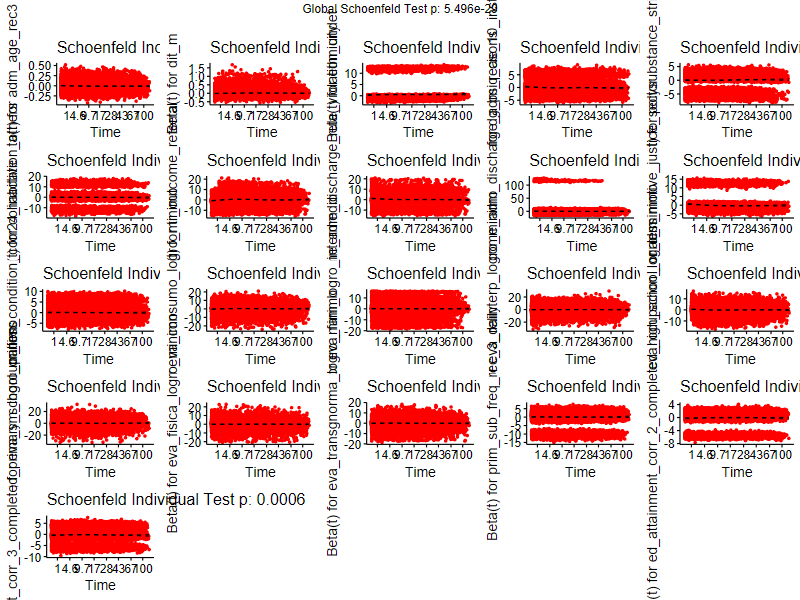

In [ ]:
#| label: nonprop2-test-coxzph-readm

# adjust plot size and resolution for high-quality output
options(repr.plot.width = 16*1.5, repr.plot.height = 12*1.5)
options(repr.plot.res = 300)

gc()

total_cpus <- parallel::detectCores()
cpus <- ifelse(total_cpus > 30, 16, 7)

# --- READMISSION MODEL ---
ph_test_readmit <- cox.zph(cox_readmit2)

# 1. Identify violators (you already have this part)
violations_readm <- ph_test_readmit$table |>
  data.table::data.table(keep.rownames = T) |>
  dplyr::mutate(p = as.numeric(p)) |>
  dplyr::filter(p < 0.05) |>
  dplyr::pull(rn) |>
  setdiff("GLOBAL")
# 2. Generate the combined plot
# ggcoxzph creates a list of plots if you pass multiple variables
combined_plots <- survminer::ggcoxzph(ph_test_readmit, var = violations_readm)
# Open a PDF device
pdf(paste0(project_root,"/cons/","_figs/ph_test_violations_readm.pdf"), 
  width = 16 * 1.5, 
  height = 12 * 1.5)
# Draw the combined plot
print(combined_plots)
# Close the device
dev.off()
png(
  filename = paste0(project_root,"/cons/","_figs/ph_test_violations_readm.png"),
  width = 16 * 1.5,
  height = 12 * 1.5,
  units = "in",
  res=300
)
print(combined_plots)
dev.off()

combined_plots

In [67]:
ph_test_readmit$table |>
  data.table::data.table(keep.rownames = TRUE) |>
  dplyr::arrange(desc(chisq)) |>
  dplyr::mutate(
    p_fmt = ifelse(p < 0.001, "<0.001", sprintf("%.3f", p)),
    chi_fmt = sprintf(
      "χ²(%d)= %.2f, p%s",
      df,
      chisq,
      ifelse(p < 0.001, "<0.001", paste0("=", p_fmt))
    )
  ) |>
  dplyr::select(covariable = rn, `χ²(gl), p` = chi_fmt) |>
  knitr::kable("markdown",caption = "Schofeld residuals, readmission")



Table: Schofeld residuals, readmission

|covariable                                                |χ²(gl), p               |
|:---------------------------------------------------------|:-----------------------|
|GLOBAL                                                    |χ²(64)= 281.07, p<0.001 |
|tr_outcome_adm_discharge_rule_violation_undet             |χ²(1)= 60.65, p<0.001   |
|adm_motive_justice_sector                                 |χ²(1)= 43.08, p<0.001   |
|dg_psiq_cie_10_instudy                                    |χ²(1)= 23.43, p<0.001   |
|dit_m                                                     |χ²(1)= 22.00, p<0.001   |
|polysubstance_strict                                      |χ²(1)= 18.48, p<0.001   |
|eva_ocupacion_logro_minimo                                |χ²(1)= 17.11, p<0.001   |
|ed_attainment_corr_3_completed_primary_school_or_less     |χ²(1)= 11.81, p<0.001   |
|eva_transgnorma_logro_minimo                              |χ²(1)= 8.26, p=0.004    |
|ed_attainme

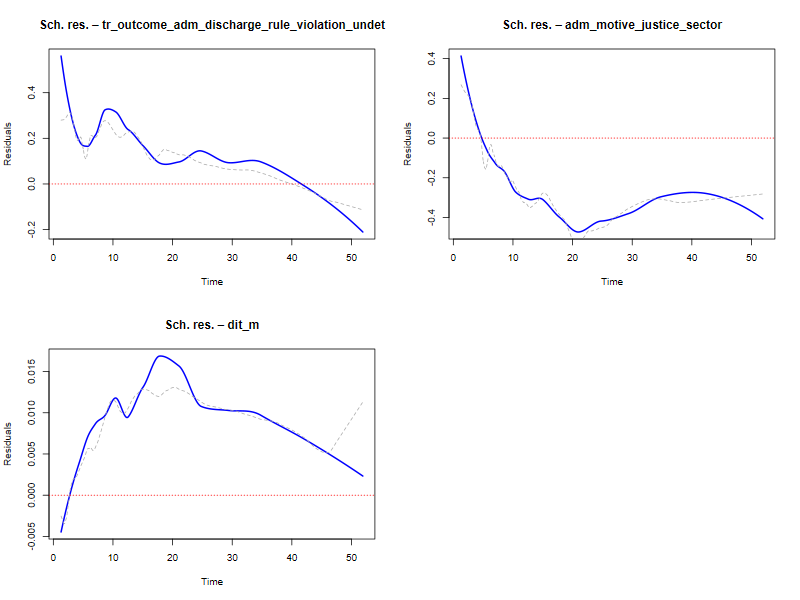

In [41]:
#| label: nonprop2-5-test-coxzph-readm-spec

#fixed windows based on data density rather than percentiles, and show raw residuals as points

par(mfrow=c(2,2))
plot_schoenfeld_residuals(
    formula = formula_readmit_updated,
    variable = "tr_outcome_adm_discharge_rule_violation_undet",
    df = py_corrected_datasets[[1]]
)
plot_schoenfeld_residuals(
    formula = formula_readmit_updated,
    variable = "adm_motive_justice_sector",
    df = py_corrected_datasets[[1]]
)
plot_schoenfeld_residuals(
    formula = formula_readmit_updated,
    variable = "dit_m",
    df = py_corrected_datasets[[1]]
)

The protective effect of "rule violation undetermined" diminishes over time. Initially associated with higher risk (or less protection), later becomes protective or neutral. Complex non-monotonic pattern. The effect of justice sector referral changes direction multiple times - initially neutral, then protective, then risk factor, then strongly protective again. Despite small scale, this shows the effect of dit_m is not constant - changes from positive to negative association over time.

### Residuals, death

Warning message:
In regularize.values(x, y, ties, missing(ties), na.rm = na.rm) :
  collapsing to unique 'x' values


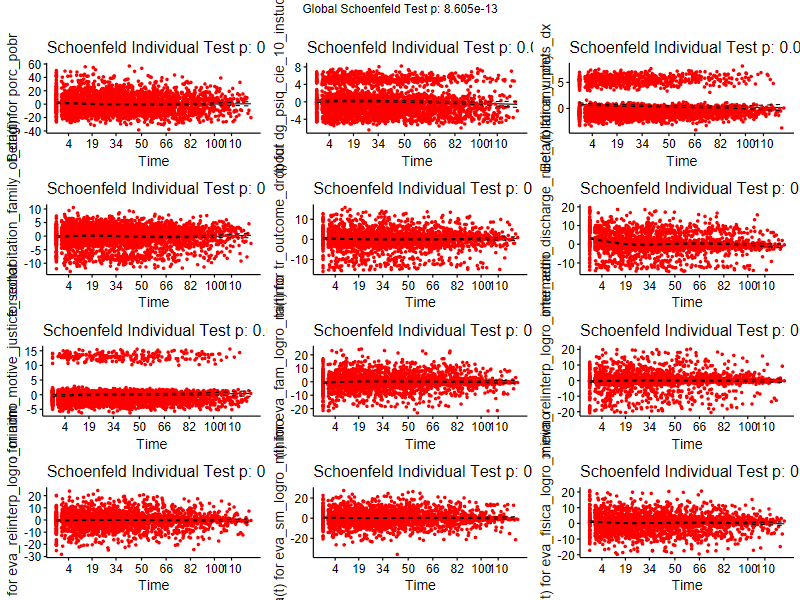

In [ ]:
#| label: nonprop3-test-coxzph-death
# --- DEATH MODEL ---
ph_test_death <- cox.zph(cox_death2)

# 1. Identify violators (you already have this part)
violations <- ph_test_death$table|> 
  data.table::data.table(keep.rownames = T)|> 
  dplyr::mutate(p = as.numeric(p))|> 
  dplyr::filter(p < 0.05)|> 
  dplyr::pull(rn)|> 
  setdiff("GLOBAL")
# 2. Generate the combined plot
# ggcoxzph creates a list of plots if you pass multiple variables
combined_plots <- survminer::ggcoxzph(ph_test_death, var = violations)
# Open a PDF device 
pdf(paste0(project_root,"/cons/","_figs/ph_test_violations_death.pdf"), 
    width = 16*1.5, 
    height = 12*1.5) 
# Draw the combined plot 
print(combined_plots) 
# Close the device 
dev.off()
png(
  filename = paste0(project_root,"/cons/","_figs/ph_test_violations_death.png"),
  width  = 16 * 1.5,
  height = 12 * 1.5,
  units  = "in",
  res = 300
)
print(combined_plots) 
dev.off()
combined_plots

In [68]:
ph_test_death$table|>
  data.table::data.table(keep.rownames = TRUE)|>
  dplyr::arrange(desc(chisq))|>
  dplyr::mutate(
    p_fmt = ifelse(p < 0.001, "<0.001", sprintf("%.3f", p)),
    chi_fmt = sprintf("χ²(%d)= %.2f, p%s", df, chisq, ifelse(p < 0.001, "<0.001", paste0("=", p_fmt))))|>
  dplyr::select(covariable = rn, `χ²(gl), p` = chi_fmt)|>
  knitr::kable("markdown", caption="Schofeld residuals, death")



Table: Schofeld residuals, death

|covariable                                                |χ²(gl), p               |
|:---------------------------------------------------------|:-----------------------|
|GLOBAL                                                    |χ²(64)= 178.78, p<0.001 |
|tr_outcome_adm_discharge_rule_violation_undet             |χ²(1)= 82.43, p<0.001   |
|any_phys_dx                                               |χ²(1)= 15.15, p<0.001   |
|eva_fisica_logro_minimo                                   |χ²(1)= 10.17, p=0.001   |
|tr_outcome_dropout                                        |χ²(1)= 8.64, p=0.003    |
|adm_motive_justice_sector                                 |χ²(1)= 7.93, p=0.005    |
|dg_psiq_cie_10_instudy                                    |χ²(1)= 7.07, p=0.008    |
|eva_relinterp_logro_minimo                                |χ²(1)= 7.02, p=0.008    |
|eva_sm_logro_minimo                                       |χ²(1)= 6.04, p=0.014    |
|porc_pobr        

We decided to stratify by treatment outcome for mortality by  `tr_outcome_adm_discharge_rule_violation_undet`.

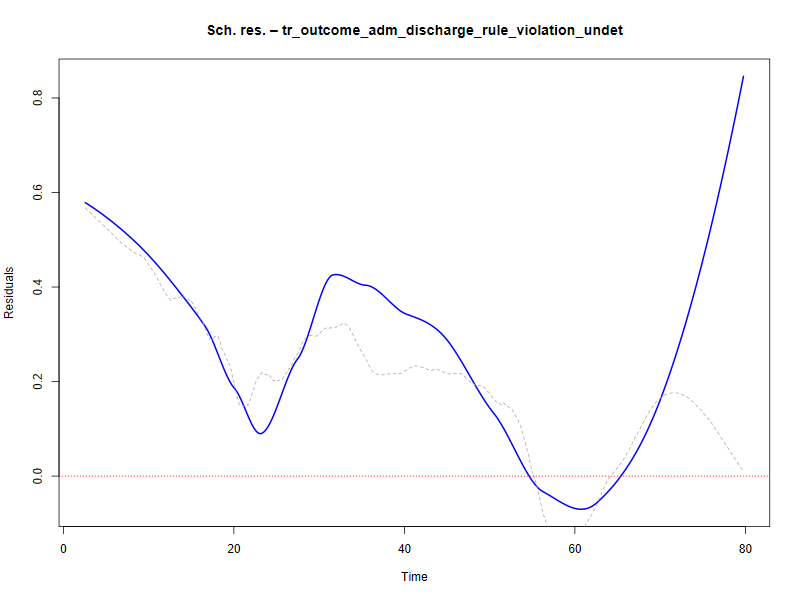

In [43]:
#| label: nonprop3-5-test-coxzph-death-spec
par(mfrow=c(1,1))
plot_schoenfeld_residuals(
    formula = formula_death_updated,
    variable = "tr_outcome_adm_discharge_rule_violation_undet",
    df = py_corrected_datasets[[1]]
)

We suspect an administrative artifact behind the concentration and violation of proportionallity of hazards

In [44]:
#| label: nonprop3-5-test-coxzph-death-artifact

# Create time intervals
time_breaks <- c(0, 5, 10, 20, 60, 120)
time_labels <- c("(0,5]", "(5,10]", "(10,20]", "(20,60]", "(60,120]")

# Cut the time variable
time_cut <- cut(py_corrected_datasets[[1]]$death_time_from_disch_m, 
                breaks = time_breaks, 
                labels = time_labels)

# Get variable names dynamically
var1 <- "tr_outcome_adm_discharge_rule_violation_undet"
var2 <- "tr_outcome_adm_discharge_adm_reasons"

# Create tables
total_table <- table(time_cut)
var1_table <- table(dplyr::pull(py_corrected_datasets[[1]], var1), time_cut)
var2_table <- table(dplyr::pull(py_corrected_datasets[[2]], var2), time_cut)

# Build data frame adaptively
result_df <- data.frame(
  Time_interval = time_labels,
  Total = as.numeric(total_table)
)

# Add var1 levels (excluding first level as reference)
for(i in 2:nrow(var1_table)) {
  col_name <- paste0(var1, "_", rownames(var1_table)[i])
  result_df[[col_name]] <- as.numeric(var1_table[i, ])
}

# Add var2 levels (excluding first level as reference)
for(i in 2:nrow(var2_table)) {
  col_name <- paste0(var2, "_", rownames(var2_table)[i])
  result_df[[col_name]] <- as.numeric(var2_table[i, ])
}

# Generate markdown table
knitr::kable(result_df, 
      format = "markdown",
      col.names = c("Intervals", "total", "Rule violation", "Adm reasons"),
      caption = "Distribution of death times by discharge outcome categories",
      align = c("l", rep("r", ncol(result_df) - 1)))



Table: Distribution of death times by discharge outcome categories

|Intervals | total| Rule violation| Adm reasons|
|:---------|-----:|--------------:|-----------:|
|(0,5]     |  6159|            256|         155|
|(5,10]    |  1464|             45|          30|
|(10,20]   |  5695|            174|         159|
|(20,60]   | 25526|           1158|         579|
|(60,120]  | 29412|           3269|           7|

We had to handle ties


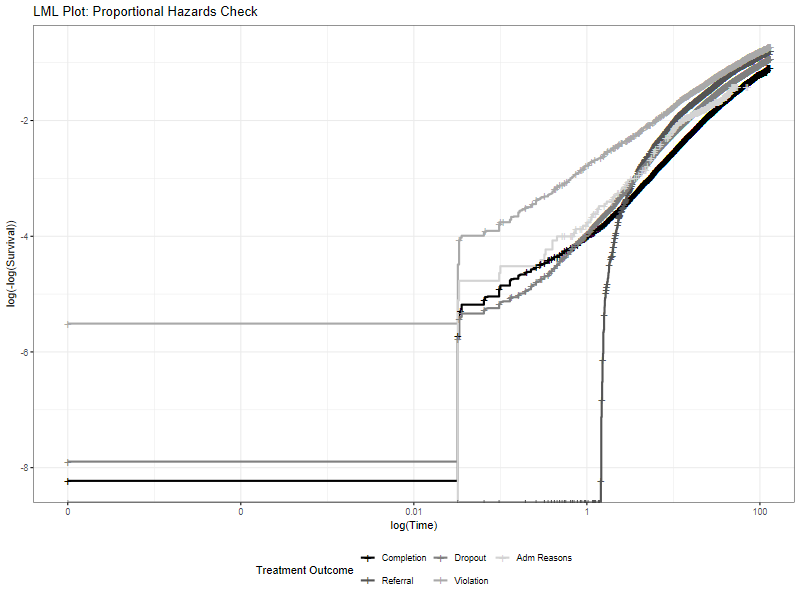

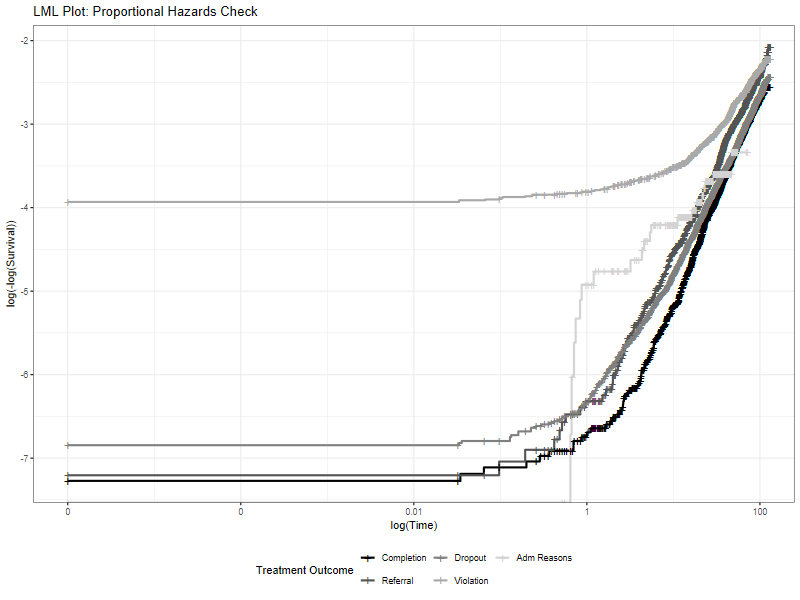

In [45]:
#| label: nonprop5-log-log

message("We had to handle ties")
df_surv <- py_corrected_datasets[[1]] %>%
  dplyr::mutate(
    tr_outcome_strata = case_when(
      tr_outcome_referral == 1 ~ "referral",
      tr_outcome_dropout == 1 ~ "dropout",
      tr_outcome_adm_discharge_rule_violation_undet == 1 ~ "rule violation/undet",
      tr_outcome_adm_discharge_adm_reasons == 1 ~ "adm reasons",
      #tr_outcome_other == 1 ~ "other",
      T~ "completion"
    ),
    tr_outcome_strata = factor(
      tr_outcome_strata,
      levels = c(
        "completion",
        "referral",
        "dropout",
        "rule violation/undet",
        "adm reasons"#,
        #"other"
      )
    )
  )
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
fit_stratified_readmit <- survfit(
  Surv(readmit_time_from_disch_m, readmit_event) ~ tr_outcome_strata,
  data = df_surv |> dplyr::filter(tr_outcome_strata!="other"))
fit_stratified_death <- survfit(
  Surv(death_time_from_disch_m, death_event) ~ tr_outcome_strata,
  data = df_surv |> dplyr::filter(tr_outcome_strata!="other"))
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# 1. Define tus colores en un vector claro
mis_colores <- c("#000000", "#545454", "#808080", "#A9A9A9", "#D3D3D3")
p <-survminer::ggsurvplot(
  fit_stratified_readmit, 
  fun = "cloglog", 
  conf.int = FALSE,              # Saca esto si se ve muy "sucio" o amontonado
  palette = mis_colores,         # AQUÍ se definen los colores
  title = "LML Plot: Proportional Hazards Check",
  xlab = "log(Time)",
  ylab = "log(-log(Survival))",
  legend.title = "Treatment Outcome",
  legend.labs = c("Completion", "Referral", "Dropout", "Violation", "Adm Reasons"),
  ggtheme = theme_bw()           # Fondo blanco limpio para tesis
)
p$plot <- p$plot + 
  theme(legend.position = "bottom") +
  guides(color = guide_legend(nrow = 2)) # Organiza la leyenda en 2 filas si es muy larga
p$plot
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# 1. Define tus colores en un vector claro
mis_colores <- c("#000000", "#545454", "#808080", "#A9A9A9", "#D3D3D3")
p_death_eng <-survminer::ggsurvplot(
  fit_stratified_death, 
  fun = "cloglog", 
  conf.int = FALSE,              # Saca esto si se ve muy "sucio" o amontonado
  palette = mis_colores,         # AQUÍ se definen los colores
  title = "LML Plot: Proportional Hazards Check",
  xlab = "log(Time)",
  ylab = "log(-log(Survival))",
  legend.title = "Treatment Outcome",
  legend.labs = c("Completion", "Referral", "Dropout", "Violation", "Adm Reasons"),
  ggtheme = theme_bw()           # Fondo blanco limpio para tesis
)
p_death_eng$plot <- p_death_eng$plot + 
  theme(legend.position = "bottom") +
  guides(color = guide_legend(nrow = 2)) # Organiza la leyenda en 2 filas si es muy larga
p_death_eng$plot

In [46]:
#| label: nonprop5-log-log-esp
# Readmission
p_esp_readm <- survminer::ggsurvplot(
  fit_stratified_readmit,
  fun = "cloglog",
  conf.int = TRUE,
  censor = FALSE,
  xlab = "log(Tiempo desde el alta)",
  ylab = "log(-log(Supervivencia))",
  legend.labs = c("Razones\nadministrativas",
                  "Violación\nde reglas",
                  "Finalización",
                  "Abandono",
                  "Derivación"),
  legend.title = "Resultado\ndel tratamiento",
  palette = c("#000000", "#505050", "#808080", "#B0B0B0", "#D9D9D9"),
  ggtheme = theme_minimal(base_family = "Arial")
)
p_esp_readm$plot <- p_esp_readm$plot +
  geom_point(aes(shape = strata, color = strata), size = 2) +
  scale_color_manual(
    values = c("#000000", "#505050", "#808080", "#B0B0B0", "#D9D9D9"),
    name = "Resultado\ndel tratamiento",
    labels = c("Razones\nadministrativas", "Violación\nde reglas", "Finalización", "Abandono", "Derivación")
  ) +
  scale_shape_manual(
    values = c(16, 17, 15, 18, 3),
    name = "Resultado\ndel tratamiento",
    labels = c("Razones\nadministrativas", "Violación\nde reglas", "Finalización", "Abandono", "Derivación")
  ) +
  theme(
    text = element_text(family = "Arial"),
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    plot.title = element_blank()
  )
# Death
p_esp_death <- survminer::ggsurvplot(
  fit_stratified_death,
  fun = "cloglog",
  conf.int = TRUE,
  censor = FALSE,
  xlab = "log(Tiempo desde el alta)",
  ylab = "log(-log(Supervivencia))",
  legend.labs = c("Razones\nadministrativas",
                  "Violación\nde reglas",
                  "Finalización",
                  "Abandono",
                  "Derivación"),
  legend.title = "Resultado\ndel tratamiento",
  palette = c("#000000", "#505050", "#808080", "#B0B0B0", "#D9D9D9"),
  ggtheme = theme_minimal(base_family = "Arial")
)
p_esp_death$plot <- p_esp_death$plot +
  geom_point(aes(shape = strata, color = strata), size = 2) +
  scale_color_manual(
    values = c("#000000", "#505050", "#808080", "#B0B0B0", "#D9D9D9"),
    name = "Resultado\ndel tratamiento",
    labels = c("Razones\nadministrativas", "Violación\nde reglas", "Finalización", "Abandono", "Derivación")
  ) +
  scale_shape_manual(
    values = c(16, 17, 15, 18, 3),
    name = "Resultado\ndel tratamiento",
    labels = c("Razones\nadministrativas", "Violación\nde reglas", "Finalización", "Abandono", "Derivación")
  ) +
  theme(
    text = element_text(family = "Arial"),
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    plot.title = element_blank()
  ) +
  labs(y = NULL) # remove Y label from readmission panel
# Combine with A) and B) in bold
plot_cloglog_comb <- (p_esp_readm$plot + p_esp_death$plot) +
  patchwork::plot_layout(ncol = 2, guides = "collect") +
  patchwork::plot_annotation(
    tag_levels = "A",
    tag_suffix = ")",
    theme = theme(plot.tag = element_text(face = "bold", family = "Arial"))
  ) &
  theme(legend.position = "bottom")
ggsave(
  filename = paste0(project_root, "/cons/", "_figs/supervivencia_cloglog_comb.png"),
  plot = plot_cloglog_comb,
  dpi = 300,
  width = 12*.75,
  height = 6*.75,
  units = "in"
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


We see that treatment outcome has different baseline shapes.


### Correction of strata

In [49]:
if(!require(future.callr)){install.packages("future.callr")}
evaluate_mi_cv_safe_strata <- function(
    formula,
    imputed_list,
    time_col,
    event_col,
    cv_strata_col = "plan_type_strata",
    k = 5,
    seed = 2125,
    n_eval_times = 100,
    n_repeats = 20,
    cpus = 16,
    id_col = NULL,
    verbose = FALSE,
    log_every = 100L
) {
    horizons_month <- c(12, 36, 60)
    is_pos_int <- function(x) {
        is.numeric(x) && length(x) == 1L && !is.na(x) && x > 0 && x == as.integer(x)
    }
    normalize_time <- function(x, varname) {
        if (!is.numeric(x)) {
            stop("Variable '", varname, "' must be numeric.")
        }
        x <- as.numeric(x)
        non_missing <- !is.na(x)
        if (any(!is.finite(x[non_missing]))) {
            stop("Variable '", varname, "' contains non-finite values.")
        }
        if (any(x[non_missing] < 0)) {
            stop("Variable '", varname, "' contains negative follow-up times.")
        }
        x
    }
    t_start <- Sys.time()
    if (!inherits(formula, "formula")) {
        formula <- stats::as.formula(formula, env = parent.frame())
    }
    if (!is.list(imputed_list) || length(imputed_list) == 0L) {
        stop("imputed_list must be a non-empty list.")
    }
    if (!is.character(time_col) || length(time_col) != 1L) {
        stop("time_col must be a single column name.")
    }
    if (!is.character(event_col) || length(event_col) != 1L) {
        stop("event_col must be a single column name.")
    }
    if (!is.character(cv_strata_col) || length(cv_strata_col) != 1L) {
        stop("cv_strata_col must be a single column name.")
    }
    if (!is_pos_int(k) || as.integer(k) < 2L) {
        stop("k must be an integer >= 2.")
    }
    if (!is_pos_int(n_repeats)) {
        stop("n_repeats must be a positive integer.")
    }
    if (!is_pos_int(n_eval_times) || as.integer(n_eval_times) < 2L) {
        stop("n_eval_times must be an integer >= 2.")
    }
    if (!is_pos_int(cpus)) {
        stop("cpus must be a positive integer.")
    }
    k <- as.integer(k)
    n_repeats <- as.integer(n_repeats)
    n_eval_times <- as.integer(n_eval_times)
    cpus <- as.integer(cpus)
    log_every <- as.integer(log_every)
    if (!is.finite(log_every) || log_every < 1L) {
        log_every <- 100L
    }
    df_list_raw <- lapply(imputed_list, as.data.frame)
    M <- length(df_list_raw)
    n_by_imp <- vapply(df_list_raw, nrow, integer(1))
    if (length(unique(n_by_imp)) != 1L) {
        stop("All imputations must have same number of rows.")
    }
    n <- n_by_imp[1L]
    if (k > n) {
        stop("k cannot exceed the number of rows.")
    }
    rhs_expr <- formula[[length(formula)]]
    rhs_vars <- unique(all.vars(rhs_expr))
    required_cols <- unique(c(rhs_vars, time_col, event_col, cv_strata_col))
    missing_by_imp <- lapply(df_list_raw, function(df) setdiff(required_cols, names(df)))
    bad <- which(lengths(missing_by_imp) > 0L)
    if (length(bad)) {
        detail <- paste(
            vapply(
                bad,
                function(i) {
                    sprintf("imputation %d missing: %s", i, paste(missing_by_imp[[i]], collapse = ", "))
                },
                character(1)
            ),
            collapse = "\n"
        )
        stop(
            sprintf(
                "Input schema mismatch.\nRequired vars: %s\n%s",
                paste(required_cols, collapse = ", "),
                detail
            ),
            call. = FALSE
        )
    }
    if (!is.null(id_col)) {
        if (!is.character(id_col) || length(id_col) != 1L) {
            stop("id_col must be NULL or a single column name.")
        }
        if (!all(vapply(df_list_raw, function(d) id_col %in% names(d), logical(1)))) {
            stop("id_col not found in at least one imputation.")
        }
        ref_id <- df_list_raw[[1L]][[id_col]]
        same_order <- vapply(df_list_raw, function(d) identical(d[[id_col]], ref_id), logical(1))
        if (!all(same_order)) {
            stop("Row order differs across imputations (checked with id_col).")
        }
    }
    df_list <- lapply(df_list_raw, function(d) {
        d <- as.data.frame(d)
        d[[time_col]] <- normalize_time(d[[time_col]], time_col)
        d[[event_col]] <- to01(d[[event_col]])
        d
    })
    if (M > 1L) {
        ref_time <- df_list[[1L]][[time_col]]
        ref_event <- df_list[[1L]][[event_col]]
        same_time <- vapply(
            df_list[-1L],
            function(d) isTRUE(all.equal(
                d[[time_col]],
                ref_time,
                tolerance = 1e-12,
                check.attributes = FALSE
            )),
            logical(1)
        )
        same_event <- vapply(
            df_list[-1L],
            function(d) identical(d[[event_col]], ref_event),
            logical(1)
        )
        if (!all(same_time) || !all(same_event)) {
            stop(
                "Outcome/time information differs across imputations. ",
                "This workflow assumes only predictors were imputed."
            )
        }
    }
    model_formula <- .mi_cv_rewrite_strata_calls(formula)
    class(model_formula) <- class(formula)
    environment(model_formula) <- environment(formula)
    strata_term_labels <- .mi_cv_collect_strata_term_labels(rhs_expr)
    explicit_factor_vars <- .mi_cv_collect_explicit_factor_vars(rhs_expr)
    character_factor_vars <- rhs_vars[vapply(
        rhs_vars,
        function(var) {
            any(vapply(
                df_list_raw,
                function(d) is.factor(d[[var]]) || is.character(d[[var]]),
                logical(1)
            ))
        },
        logical(1)
    )]
    categorical_formula_vars <- unique(c(explicit_factor_vars, character_factor_vars))
    if (length(categorical_formula_vars) > 0L) {
        mismatches <- character(0)
        for (var in categorical_formula_vars) {
            level_sets <- lapply(df_list_raw, function(d) .mi_cv_collect_observed_levels(d[[var]]))
            ref_levels <- level_sets[[1L]]
            same_levels <- vapply(level_sets[-1L], identical, logical(1), ref_levels)
            if (!all(same_levels)) {
                mismatches <- c(mismatches, paste0(var, " -> ", .mi_cv_format_level_sets(level_sets)))
            }
        }
        if (length(mismatches) > 0L) {
            stop(
                paste0(
                    "Categorical formula variables have inconsistent observed levels across imputations. ",
                    paste(mismatches, collapse = " | ")
                ),
                call. = FALSE
            )
        }
    }
    tau <- as.numeric(stats::quantile(df_list[[1L]][[time_col]], probs = 0.90, na.rm = TRUE))
    if (!is.numeric(tau) || length(tau) != 1L || !is.finite(tau) || tau <= 0) {
        stop("tau must resolve to a finite positive scalar.")
    }
    c_tau <- tau * 0.95
    t0_min <- min(1e-6, tau / 1000)
    eval_times <- seq(t0_min, tau, length.out = n_eval_times)
    pred_times <- sort(unique(c(eval_times, horizons_month)))
    eval_idx <- match(eval_times, pred_times)
    preflight_split <- .mi_cv_prepare_model_split(df_list[[1L]], df_list[[1L]], categorical_formula_vars)
    if (nzchar(preflight_split$error)) {
        stop("Preflight categorical preparation failed: ", preflight_split$error, call. = FALSE)
    }
    if (length(strata_term_labels) > 0L) {
        # Avoid evaluating outer strata(); build one deterministic key per row instead.
        preflight_strata <- .mi_cv_make_strata_signature_safe(
            data = preflight_split$train,
            strata_term_labels = strata_term_labels,
            formula_env = environment(model_formula)
        )
        if (length(preflight_strata) != nrow(preflight_split$train)) {
            stop(
                "Preflight safe strata signature failed for terms: ",
                paste(strata_term_labels, collapse = ", "),
                call. = FALSE
            )
        }
    }
    preflight_error <- tryCatch(
        {
            fit <- survival::coxph(
                model_formula,
                data = preflight_split$train,
                x = TRUE,
                y = TRUE,
                model = TRUE
            )
            tmp <- pec::predictSurvProb(
                fit,
                newdata = preflight_split$test[1L, , drop = FALSE],
                times = pred_times[1:2]
            )
            invisible(tmp)
            NULL
        },
        error = function(e) conditionMessage(e)
    )
    if (!is.null(preflight_error)) {
        stop("Preflight coxph/predictSurvProb failed: ", preflight_error, call. = FALSE)
    }
    total_models <- M * k * n_repeats
    cat(sprintf(
        "Starting Evaluation: %d Imputations x %d Folds x %d Repeats = %d Total Models\n",
        M, k, n_repeats, total_models
    ))
    cat("------------------------------------------------------------\n")
    cat(sprintf("Global evaluation tau: %.2f months | C-tau: %.2f months\n", tau, c_tau))
    cv_strata <- interaction(
        df_list[[1L]][[event_col]],
        df_list[[1L]][[cv_strata_col]],
        drop = TRUE,
        lex.order = TRUE
    )
    seeds <- seed + seq_len(n_repeats) - 1L
    folds_by_repeat <- lapply(seq_len(n_repeats), function(rep_id) {
        set.seed(seeds[rep_id])
        caret::createFolds(cv_strata, k = k, list = TRUE, returnTrain = FALSE)
    })
    fold_sizes_by_repeat <- lapply(
        folds_by_repeat,
        function(folds) vapply(folds, length, integer(1))
    )
    folds_first <- folds_by_repeat[[1L]]
    fold_id_first <- integer(length(cv_strata))
    for (ii in seq_along(folds_first)) {
        fold_id_first[folds_first[[ii]]] <- ii
    }
    cv_strata_table <- as.data.frame(table(cv_strata), stringsAsFactors = FALSE)
    names(cv_strata_table) <- c("cv_strata", "n")
    cv_strata_by_fold <- as.data.frame(
        table(fold = fold_id_first, cv_strata = cv_strata),
        stringsAsFactors = FALSE
    )
    c_array <- array(NA_real_, dim = c(n_repeats, M, k))
    unoC_array <- array(NA_real_, dim = c(n_repeats, M, k))
    ibs_array <- array(NA_real_, dim = c(n_repeats, M, k))
    ibs_ipcw_array <- array(NA_real_, dim = c(n_repeats, M, k))
    c_horizon <- array(
        NA_real_,
        dim = c(n_repeats, M, k, length(horizons_month)),
        dimnames = list(NULL, NULL, NULL, paste0("t", horizons_month))
    )
    task_grid <- expand.grid(
        r = seq_len(n_repeats),
        m = seq_len(M),
        i = seq_len(k),
        KEEP.OUT.ATTRS = FALSE,
        stringsAsFactors = FALSE
    )
    detected <- suppressWarnings(parallel::detectCores(logical = TRUE))
    if (!is.numeric(detected) || length(detected) != 1L || !is.finite(detected) || detected < 1L) {
        detected <- 1L
    }
    n_cores <- as.integer(max(1L, min(cpus, nrow(task_grid), max(1L, detected - 1L))))
    cat(sprintf("Booting up %d CPU cores using future backend...\n", n_cores))
    old_plan <- future::plan()
    on.exit(future::plan(old_plan), add = TRUE)
    if (n_cores > 1L) {
        if (requireNamespace("future.callr", quietly = TRUE)) {
            future::plan(future.callr::callr, workers = n_cores)
        } else {
            future::plan(future::multisession, workers = n_cores)
        }
    } else {
        future::plan(future::sequential)
    }
    all_results <- future.apply::future_lapply(
        X = seq_len(nrow(task_grid)),
        FUN = function(row_id) {
            rep_id <- task_grid$r[row_id]
            imp_id <- task_grid$m[row_id]
            fold_id <- task_grid$i[row_id]
            tryCatch(
                {
                    test_idx <- folds_by_repeat[[rep_id]][[fold_id]]
                    df_train <- df_list[[imp_id]][-test_idx, , drop = FALSE]
                    df_test <- df_list[[imp_id]][test_idx, , drop = FALSE]
                    prepared <- .mi_cv_prepare_model_split(df_train, df_test, categorical_formula_vars)
                    if (nzchar(prepared$error)) {
                        return(list(
                            r = rep_id,
                            m = imp_id,
                            i = fold_id,
                            c_uno = NA_real_,
                            unoC = NA_real_,
                            ibs = NA_real_,
                            ibs_ipcw = NA_real_,
                            c_horizons = rep(NA_real_, length(horizons_month)),
                            fail = prepared$error
                        ))
                    }
                    df_train <- prepared$train
                    df_test <- prepared$test
                    if (length(strata_term_labels) > 0L) {
                        train_strata <- .mi_cv_make_strata_signature_safe(
                            df_train,
                            strata_term_labels,
                            environment(model_formula)
                        )
                        test_strata <- .mi_cv_make_strata_signature_safe(
                            df_test,
                            strata_term_labels,
                            environment(model_formula)
                        )
                        train_keys <- unique(train_strata)
                        keep <- test_strata %in% train_keys
                        dropped <- sum(!keep)
                        if (!any(keep)) {
                            return(list(
                                r = rep_id,
                                m = imp_id,
                                i = fold_id,
                                c_uno = NA_real_,
                                unoC = NA_real_,
                                ibs = NA_real_,
                                ibs_ipcw = NA_real_,
                                c_horizons = rep(NA_real_, length(horizons_month)),
                                fail = "all_test_rows_unseen_strata"
                            ))
                        }
                        if (dropped > 0L) {
                            # Drop test rows whose strata combination never appears in training.
                            df_test <- df_test[keep, , drop = FALSE]
                        }
                        if (verbose && dropped > 0L && (row_id == 1L || row_id %% log_every == 0L)) {
                            message(sprintf(
                                "Rep %d Imp %d Fold %d | filtered %d rows with unseen strata combinations",
                                rep_id, imp_id, fold_id, dropped
                            ))
                        }
                    }
                    if (nrow(df_test) < 10L) {
                        return(list(
                            r = rep_id,
                            m = imp_id,
                            i = fold_id,
                            c_uno = NA_real_,
                            unoC = NA_real_,
                            ibs = NA_real_,
                            ibs_ipcw = NA_real_,
                            c_horizons = rep(NA_real_, length(horizons_month)),
                            fail = "too_few_test_rows_after_filter"
                        ))
                    }
                    cv_model <- survival::coxph(
                        model_formula,
                        data = df_train,
                        x = TRUE,
                        y = TRUE,
                        model = TRUE
                    )
                    surv_mat_all <- pec::predictSurvProb(cv_model, newdata = df_test, times = pred_times)
                    if (is.null(dim(surv_mat_all))) {
                        surv_mat_all <- matrix(
                            surv_mat_all,
                            nrow = nrow(df_test),
                            ncol = length(pred_times),
                            byrow = TRUE
                        )
                    }
                    if (nrow(surv_mat_all) != nrow(df_test) || ncol(surv_mat_all) != length(pred_times)) {
                        stop("Survival matrix dimensions do not match test data.")
                    }
                    surv_mat_eval <- surv_mat_all[, eval_idx, drop = FALSE]
                    if (any(!is.finite(surv_mat_eval))) {
                        stop("Non-finite survival predictions were produced.")
                    }
                    intervals <- diff(eval_times)
                    rmst_score <- as.numeric(
                        surv_mat_eval[, -ncol(surv_mat_eval), drop = FALSE] %*% intervals
                    )
                    risk_score <- -rmst_score
                    df_test$rmst_score <- rmst_score
                    df_test$risk_score <- risk_score
                    ev_train <- df_train[[event_col]]
                    ev_test <- df_test[[event_col]]
                    ok_c <- is.finite(risk_score) &
                        is.finite(df_test[[time_col]]) &
                        is.finite(ev_test)
                    c_uno_val <- if (sum(ok_c) >= 2L) {
                        tryCatch(
                            survival::concordance(
                                survival::Surv(df_test[[time_col]][ok_c], ev_test[ok_c]) ~ risk_score[ok_c],
                                timewt = "n/G2",
                                ymax = c_tau,
                                reverse = TRUE
                            )$concordance,
                            error = function(e) NA_real_
                        )
                    } else {
                        NA_real_
                    }
                    y_true_test <- survival::Surv(df_test[[time_col]], ev_test)
                    ibs_val <- tryCatch(
                        survex::integrated_brier_score(
                            y_true = y_true_test,
                            surv = surv_mat_eval,
                            times = eval_times
                        ),
                        error = function(e) NA_real_
                    )
                    ibs_ipcw_val <- tryCatch(
                        ibs_ipcw_train(
                            df_train = df_train,
                            df_test = df_test,
                            surv_mat = surv_mat_eval,
                            times = eval_times,
                            time_col = time_col,
                            event_col = event_col
                        ),
                        error = function(e) NA_real_
                    )
                    ok_uno <- ok_c & complete.cases(surv_mat_eval)
                    sf_cens <- survival::survfit(
                        survival::Surv(df_train[[time_col]], 1 - ev_train) ~ 1
                    )
                    g_ctau <- tryCatch(
                        summary(sf_cens, times = c_tau, extend = TRUE)$surv,
                        error = function(e) NA_real_
                    )
                    tau_uno <- c_tau
                    if (!is.finite(g_ctau) || g_ctau <= 1e-6) {
                        tt <- sf_cens$time[sf_cens$surv > 1e-6]
                        tau_uno <- if (length(tt)) min(c_tau, max(tt)) else NA_real_
                    }
                    unoC_val <- NA_real_
                    n_evt_tau <- NA_integer_
                    if (any(ok_uno) && is.finite(tau_uno) && tau_uno > 0) {
                        n_evt_tau <- sum(
                            ev_test[ok_uno] == 1L & df_test[[time_col]][ok_uno] <= tau_uno,
                            na.rm = TRUE
                        )
                        if (verbose && n_evt_tau < 50L) {
                            message(sprintf(
                                "Rep %d Imp %d Fold %d | UnoC computed with only %d events <= tau_uno",
                                rep_id, imp_id, fold_id, n_evt_tau
                            ))
                        }
                        lp_u <- rank(risk_score[ok_uno], ties.method = "average")
                        unoC_val <- tryCatch(
                            withCallingHandlers(
                                survAUC::UnoC(
                                    survival::Surv(df_train[[time_col]], ev_train),
                                    survival::Surv(df_test[[time_col]][ok_uno], ev_test[ok_uno]),
                                    lp_u,
                                    time = tau_uno
                                ),
                                warning = function(w) {
                                    if (verbose) {
                                        message(sprintf(
                                            "Rep %d Imp %d Fold %d | UnoC warning: %s",
                                            rep_id, imp_id, fold_id, conditionMessage(w)
                                        ))
                                    }
                                    invokeRestart("muffleWarning")
                                }
                            ),
                            error = function(e) NA_real_
                        )
                    }
                    if (verbose && (row_id == 1L || row_id %% log_every == 0L)) {
                        surv_f <- surv_mat_eval[is.finite(surv_mat_eval)]
                        surv_min <- if (length(surv_f)) min(surv_f) else NA_real_
                        surv_max <- if (length(surv_f)) max(surv_f) else NA_real_
                        rmst_min <- .mi_cv_mean_or_na(c(min(df_test$rmst_score, na.rm = TRUE)))
                        rmst_max <- .mi_cv_mean_or_na(c(max(df_test$rmst_score, na.rm = TRUE)))
                        message(sprintf(
                            "Rep %d Imp %d Fold %d | surv=[%.4f, %.4f] | RMST=[%.2f, %.2f] | G(c_tau)=%.3g | tau_uno=%.3f | UnoC=%s",
                            rep_id, imp_id, fold_id,
                            surv_min, surv_max,
                            rmst_min, rmst_max,
                            g_ctau, tau_uno, format(unoC_val, digits = 6)
                        ))
                    }
                    c_horizons_vec <- rep(NA_real_, length(horizons_month))
                    for (h in seq_along(horizons_month)) {
                        t_h <- horizons_month[h]
                        idx_h <- which(pred_times <= t_h)
                        if (length(idx_h) < 2L) {
                            next
                        }
                        rmst_t0 <- as.numeric(
                            surv_mat_all[, idx_h[-length(idx_h)], drop = FALSE] %*% diff(pred_times[idx_h])
                        )
                        risk_t0 <- -rmst_t0
                        ok_h <- is.finite(risk_t0) &
                            is.finite(df_test[[time_col]]) &
                            is.finite(ev_test)
                        c_horizons_vec[h] <- if (sum(ok_h) >= 2L) {
                            tryCatch(
                                survival::concordance(
                                    survival::Surv(df_test[[time_col]][ok_h], ev_test[ok_h]) ~ risk_t0[ok_h],
                                    timewt = "n/G2",
                                    ymax = t_h,
                                    reverse = TRUE
                                )$concordance,
                                error = function(e) NA_real_
                            )
                        } else {
                            NA_real_
                        }
                    }
                    list(
                        r = rep_id,
                        m = imp_id,
                        i = fold_id,
                        c_uno = c_uno_val,
                        unoC = unoC_val,
                        ibs = ibs_val,
                        ibs_ipcw = ibs_ipcw_val,
                        c_horizons = c_horizons_vec,
                        fail = ""
                    )
                },
                error = function(e) {
                    list(
                        r = rep_id,
                        m = imp_id,
                        i = fold_id,
                        c_uno = NA_real_,
                        unoC = NA_real_,
                        ibs = NA_real_,
                        ibs_ipcw = NA_real_,
                        c_horizons = rep(NA_real_, length(horizons_month)),
                        fail = paste0("fold_error:", conditionMessage(e))
                    )
                }
            )
        },
        future.seed = TRUE,
        future.packages = c("survival", "pec", "survex", "survAUC")
    )
    for (res in all_results) {
        c_array[res$r, res$m, res$i] <- res$c_uno
        unoC_array[res$r, res$m, res$i] <- res$unoC
        ibs_array[res$r, res$m, res$i] <- res$ibs
        ibs_ipcw_array[res$r, res$m, res$i] <- res$ibs_ipcw
        c_horizon[res$r, res$m, res$i, ] <- res$c_horizons
    }
    task_failures <- do.call(rbind, lapply(all_results, function(res) {
        data.frame(
            repetition = res$r,
            imputation = res$m,
            fold = res$i,
            error = res$fail,
            stringsAsFactors = FALSE
        )
    }))
    task_failures <- task_failures[nzchar(task_failures$error), , drop = FALSE]
    rep_mean <- function(arr3) {
        vapply(seq_len(dim(arr3)[1L]), function(rep_id) {
            .mi_cv_mean_or_na(as.numeric(arr3[rep_id, , ]))
        }, numeric(1))
    }
    c_rep <- rep_mean(c_array)
    unoC_rep <- rep_mean(unoC_array)
    ibs_rep <- rep_mean(ibs_array)
    ibs_ipcw_rep <- rep_mean(ibs_ipcw_array)
    ci95_c <- .mi_cv_quantile_or_na(c_rep, c(0.025, 0.975))
    ci95_unoC <- .mi_cv_quantile_or_na(unoC_rep, c(0.025, 0.975))
    ci95_ibs <- .mi_cv_quantile_or_na(ibs_rep, c(0.025, 0.975))
    ci95_ibs_ipcw <- .mi_cv_quantile_or_na(ibs_ipcw_rep, c(0.025, 0.975))
    final_pooled_c <- .mi_cv_mean_or_na(c_rep)
    final_pooled_unoC <- .mi_cv_mean_or_na(unoC_rep)
    final_pooled_ibs <- .mi_cv_mean_or_na(ibs_rep)
    final_pooled_ibs_ipcw <- .mi_cv_mean_or_na(ibs_ipcw_rep)
    h_rep <- vapply(seq_len(length(horizons_month)), function(h) {
        vapply(seq_len(n_repeats), function(rep_id) {
            .mi_cv_mean_or_na(as.numeric(c_horizon[rep_id, , , h]))
        }, numeric(1))
    }, numeric(n_repeats))
    if (n_repeats == 1L) {
        h_rep <- matrix(h_rep, nrow = 1L)
    }
    rmst_h_summary <- data.frame(
        horizon_month = horizons_month,
        c_mean = vapply(seq_len(length(horizons_month)), function(h) .mi_cv_mean_or_na(h_rep[, h]), numeric(1)),
        ci95_lower = vapply(seq_len(length(horizons_month)), function(h) .mi_cv_quantile_or_na(h_rep[, h], 0.025), numeric(1)),
        ci95_upper = vapply(seq_len(length(horizons_month)), function(h) .mi_cv_quantile_or_na(h_rep[, h], 0.975), numeric(1)),
        valid_repeats = vapply(seq_len(length(horizons_month)), function(h) sum(is.finite(h_rep[, h])), integer(1)),
        stringsAsFactors = FALSE
    )
    cat("\n============================================================\n")
    cat("FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)\n")
    cat("============================================================\n")
    cat(sprintf("Global Evaluation Time (tau): %.2f months\n", tau))
    cat(sprintf(
        "Pooled Uno's C-Index: %.4f (repeat-quantile interval %.4f-%.4f)\n",
        final_pooled_c, ci95_c[1L], ci95_c[2L]
    ))
    cat(sprintf(
        "Pooled UnoC (survAUC::UnoC): %.4f (repeat-quantile interval %.4f-%.4f)\n",
        final_pooled_unoC, ci95_unoC[1L], ci95_unoC[2L]
    ))
    cat(sprintf(
        "Pooled IBS: %.4f (repeat-quantile interval %.4f-%.4f)\n",
        final_pooled_ibs, ci95_ibs[1L], ci95_ibs[2L]
    ))
    cat(sprintf(
        "Pooled IBS (IPCW-train): %.4f (repeat-quantile interval %.4f-%.4f)\n",
        final_pooled_ibs_ipcw, ci95_ibs_ipcw[1L], ci95_ibs_ipcw[2L]
    ))
    cat("RMST-based Uno C-index by horizon:\n")
    for (hh in seq_len(nrow(rmst_h_summary))) {
        cat(sprintf(
            "  t=%d m: C=%.4f (repeat-quantile interval %.4f-%.4f, valid repeats=%d)\n",
            rmst_h_summary$horizon_month[hh],
            rmst_h_summary$c_mean[hh],
            rmst_h_summary$ci95_lower[hh],
            rmst_h_summary$ci95_upper[hh],
            rmst_h_summary$valid_repeats[hh]
        ))
    }
    cat("============================================================\n")
    si <- utils::sessionInfo()
    other_pkgs <- if (is.null(si$otherPkgs)) character(0) else names(si$otherPkgs)
    t_end <- Sys.time()
    elapsed_sec <- as.numeric(difftime(t_end, t_start, units = "secs"))
    cat(sprintf("\nTotal runtime: %.2f sec (%.2f min)\n", elapsed_sec, elapsed_sec / 60))
    invisible(list(
        raw_c_array = c_array,
        raw_unoC_array = unoC_array,
        raw_ibs_array = ibs_array,
        raw_ibs_ipcw_array = ibs_ipcw_array,
        ci95_pooled_c = unname(ci95_c),
        ci95_pooled_unoC = unname(ci95_unoC),
        ci95_pooled_ibs = unname(ci95_ibs),
        ci95_pooled_ibs_ipcw = unname(ci95_ibs_ipcw),
        repeat_values = list(
            c = c_rep,
            unoC = unoC_rep,
            ibs = ibs_rep,
            ibs_ipcw = ibs_ipcw_rep
        ),
        raw_failures = task_failures,
        reproducibility = list(
            call = match.call(),
            seed = seed,
            repeat_seeds = seeds,
            k = k,
            M = M,
            n_repeats = n_repeats,
            time_col = time_col,
            event_col = event_col,
            formula = paste(deparse(formula, width.cutoff = 500L), collapse = " "),
            tau = tau,
            c_tau = c_tau,
            n_eval_times = n_eval_times,
            eval_times = eval_times,
            prediction_times = pred_times,
            fold_sizes = fold_sizes_by_repeat[[1L]],
            fold_sizes_by_repeat = fold_sizes_by_repeat,
            folds_by_repeat = folds_by_repeat,
            rmst_unoC_by_horizon = c_horizon,
            rmst_unoC_summary = rmst_h_summary,
            cv_strata_table = cv_strata_table,
            cv_strata_by_fold = cv_strata_by_fold,
            categorical_formula_vars = categorical_formula_vars,
            strata_terms = strata_term_labels,
            timestamp = as.character(Sys.time()),
            R_version = R.version.string,
            attached_packages = other_pkgs
        )
    ))
}

Loading required package: future.callr
# Downloading packages -------------------------------------------------------
- Downloading future.callr from P3M ...         OK [98.7 Kb in 2.2s]
Successfully downloaded 1 package in 9 seconds.

The following package(s) will be installed:
- future.callr [0.10.2]
These packages will be installed into "G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
- Installing future.callr ...                   OK [installed binary in 6.2s]


Warning message:
In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package called ‘future.callr’


In [ ]:
#| label: patch-override-functions-2
# Override inline definitions with patched versions (rscript_args fix, memory trim, rm before future_lapply)
source("cons/_alt_scripts/evaluate_mi_cv_safe_strata.R")
source("cons/_alt_scripts/cph_evaluate_boot_oob_mi_corrected.R")

options(
  parallelly.makeNodePSOCK.rscript_args = "--no-init-file",
  parallelly.makeNodePSOCK.rscript_libs = .libPaths()
)
cat("Patched functions loaded.\n")

In [50]:
#| label: update-model-to-nph

gc()

total_cpus <- parallel::detectCores()
cpus <- ifelse(total_cpus > 30, 16, 7)

.t0 <- Sys.time()

# 1. Clean the Readmission Formula (Subtract the 1 violator)
formula_readmit_updated2 <- update(
  formula_readmit_updated,
  . ~ . - tr_outcome_adm_discharge_rule_violation_undet
)
# 2. Clean the Death Formula (Subtract both violators)
formula_death_updated2 <- update(
  formula_death_updated,
  . ~ . - tr_outcome_adm_discharge_rule_violation_undet # - tr_outcome_adm_discharge_adm_reasons
)
# 1. READMISSION FORMULA
# Safely collapse the formula into a single text string first
formula_readmit_updated2 <- as.formula(
  gsub(
    "strata\\(plan_type_strata\\)",
    "strata(plan_type_strata)+ strata(tr_outcome_adm_discharge_rule_violation_undet)",
    paste(deparse(formula_readmit_updated2), collapse = " ")
  )
)
# 2. DEATH FORMULA
# Safely collapse the formula into a single text string first
formula_death_updated2 <- as.formula(
  gsub(
    "strata\\(plan_type_strata\\)",
    "strata(plan_type_strata) +strata(tr_outcome_adm_discharge_rule_violation_undet)",
    paste(deparse(formula_death_updated2), collapse = " ")
  )
)

results_readmit3 <- evaluate_mi_cv_safe_strata(
  formula = formula_readmit_updated2,
  imputed_list = py_corrected_datasets,
  time_col = "readmit_time_from_disch_m",
  event_col = "readmit_event",
  k = 5,
  n_repeats = 20
)
results_death3 <- evaluate_mi_cv_safe_strata(
  formula = formula_death_updated2,
  imputed_list = py_corrected_datasets,
  time_col = "death_time_from_disch_m",
  event_col = "death_event",
  k = 5,
  n_repeats = 20
)
results_readmit3_ibs <- cph_evaluate_boot_oob_mi_corrected(
  formula = formula_readmit_updated2,
  imputed_list = py_corrected_datasets, # List of data.frames
  time_col = "readmit_time_from_disch_m",
  event_col = "readmit_event",
  tau = 99, # Evaluate up to 60 months
  B = 500,
  cpus = coress,
  verbose = TRUE,
  min_strata_events = 1
)
results_death3_ibs <- cph_evaluate_boot_oob_mi_corrected(
  formula = formula_death_updated2,
  imputed_list = py_corrected_datasets, # List of data.frames
  time_col = "death_time_from_disch_m",
  event_col = "death_event",
  tau = 107, # Evaluate up to 60 months
  B = 500,
  cpus = coress,
  verbose = TRUE,
  min_strata_events = 1
)

aicc_readmit_upd2 <- compute_mi_aicc(
  formula_readmit_updated2,
  py_corrected_datasets
)
cat(sprintf(
  "\nDifference in Mean AIC: %.2f\n",
  aicc_readmit_upd2$mean_aic - aicc_readmit_upd$mean_aic
))

aicc_death_upd2 <- compute_mi_aicc(
  formula_death_updated2,
  py_corrected_datasets
)
cat(sprintf(
  "\nDifference in Mean AIC: %.2f\n",
  aicc_death_upd2$mean_aic - aicc_death_upd$mean_aic
))

#compare_mi_models_d1(formula_readmit_updated2, formula_readmit_updated, py_corrected_datasets)
# Error en mitml::testModels(fit1, fit0, method = "D1", df.com = dfcom):
#   The 'model' and 'null.model' appear not to be nested or include the same set of parameters.
# Called from: mitml::testModels(fit1, fit0, method = "D1", df.com = dfcom)

compare_mi_models_d1(
  formula_readmit_updated,
  update(
    formula_readmit_updated,
    . ~ . - tr_outcome_adm_discharge_rule_violation_undet
  ),
  py_corrected_datasets
)
compare_mi_models_d1(
  formula_death_updated,
  update(
    formula_death_updated,
    . ~ . -
      tr_outcome_adm_discharge_rule_violation_undet -
      tr_outcome_adm_discharge_adm_reasons
  ),
  py_corrected_datasets
)

cal_readmit3 <-
  calibrate_cph_grouped(
    formula = formula_readmit_updated2, # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE
  )
print(cal_readmit3)

cal_death3 <-
  calibrate_cph_grouped(
    formula = formula_death_updated2, # Original formula with months variable
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE
  )
print(cal_death3)

dt_numeric <- as.numeric(Sys.time() - .t0, units = "secs")
cat(sprintf("Elapsed: %02d:%02d:%02d\n",
            dt_numeric %/% 3600,
            (dt_numeric %% 3600) %/% 60,
            round(dt_numeric %% 60)))

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6066 (repeat-quantile interval 0.6061-0.6070)
Pooled UnoC (survAUC::UnoC): 0.6844 (repeat-quantile interval 0.6547-0.7046)
Pooled IBS: 0.1601 (repeat-quantile interval 0.1600-0.1602)
Pooled IBS (IPCW-train): 0.3476 (repeat-quantile interval 0.3475-0.3479)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6287 (repeat-quantile interval 0.6281-0.6292, valid repeats=20)
  t=36 m: C=0.6146 (repeat-quantile interval 0.6141-0.6152, valid repeats=20)
  t=60 m: C=0.6097 (repeat-quantile interval 0.6092-0.6102, valid repeats=20)

Total runtime: 827.08 sec (13.78 min)
Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 To

Warning messages:
1: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  33 ; coefficient may be infinite. 
2: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  33 ; coefficient may be infinite. 
3: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  44 ; coefficient may be infinite. 
4: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  44 ; coefficient may be infinite. 
5: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  44 ; coefficient may be infinite. 
6: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  21 ; coefficient may be infinite. 
7: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before varia

Strata variables: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Categorical vars: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=107.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.0883 (95% CI: 0.0820 - 0.0955)
Valid bootstrap replicates: 500 / 500


Warning messages:
1: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  21 ; coefficient may be infinite. 
2: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  14 ; coefficient may be infinite. 
3: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  21 ; coefficient may be infinite. 
4: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  16 ; coefficient may be infinite. 
5: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  10 ; coefficient may be infinite. 
6: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  28 ; coefficient may be infinite. 
7: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before varia


AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272548.63
Mean AICc: 272549.16
Correction added (Penalty): 0.531120
Parameters (k): 63 | Effective Sample Size (Events): 15247

Difference in Mean AIC: -10132.02

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51493.53
Mean AICc: 51496.24
Correction added (Penalty): 2.710588
Parameters (k): 63 | Effective Sample Size (Events): 3039

Difference in Mean AIC: -2433.79
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1 df2 dfcom     p.value          riv
 1 ~~ 2  51.07488   1   4 15183 0.002028026 0.0001081492
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom      p.value          riv
 1 ~~ 2   25.7481   2 2972.522  2975 8.194034e-12 0.0003485494
Detected time 

Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Predicting repetition 1/20... done
Predicting repetition 2/20... done
Predicting repetition 3/20... done
Predicting repetition 4/20... done
Predicting repetition 5/20... done
Predicting repetition 6/20... done
Predicting repetition 7/20... done
Predicting repetition 8/20... done
Predicting repetition 9/20... done
Predicting repetition 10/20... done
Predicting repetition 11/20... done
Predicting repetition 12/20... done
Predicting repetition 13/20... done
Predicting repetition 14/20... done
Predicting repetition 15/20... done
Predicting repetition 16/20... done
Predicting repetition 17/20... done
Predicting repetition 18/20... done
Predicting repetition 19/20... done
Predicting repetition 20/20... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... d

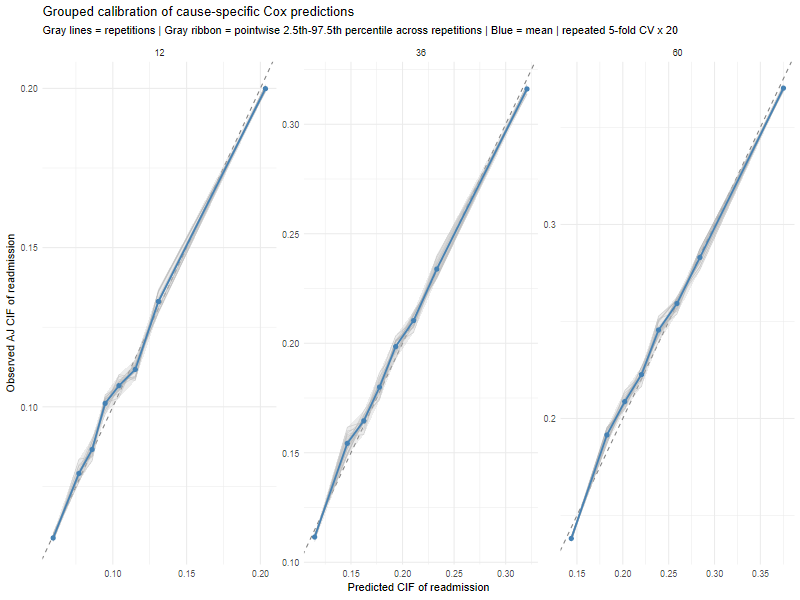

Elapsed: 04:54:46


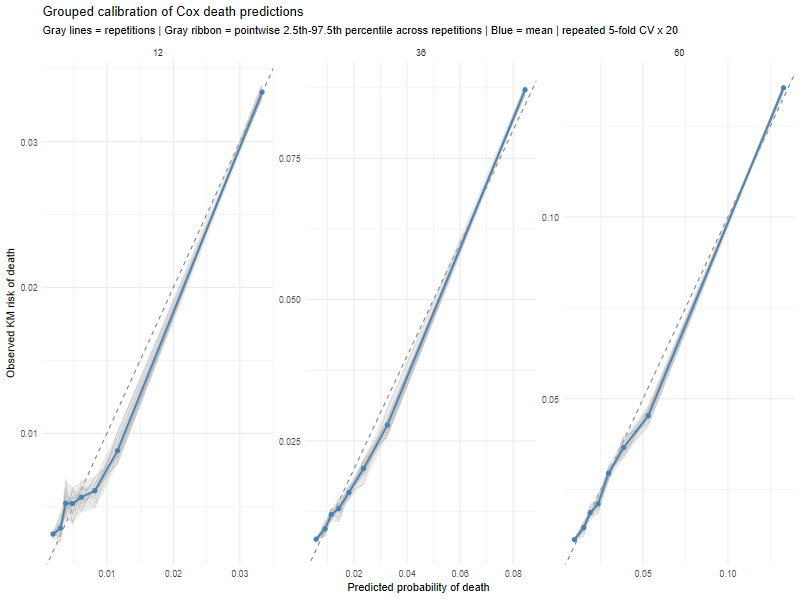

In [48]:
#| label: calibration-updated2-ICI
.t0 <- Sys.time()

cal_readmit_full_aj_rcv <- calibrate_cscox_aj_grouped(
    formula_readmit = formula_readmit_updated2,
    formula_death = formula_death_updated2,
    data = py_corrected_datasets,
    times = c(12, 36, 60),
    n_imputations = 5,
    validation = "cv",
    folds = 5,
    n_repeats = 20,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    g = 10,
    min_bin_n = 20,
    seed = 2125
)
print(cal_readmit_full_aj_rcv)
plot(cal_readmit_full_aj_rcv)

cal_death_full_ici <- calibrate_cph_grouped(
    formula = formula_death_updated2,
    data = py_corrected_datasets,
    times = c(12, 36, 60),
    validation = "cv",
    folds = 5,
    n_repeats = 20,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE
)
print(cal_death_full_ici)
plot(cal_death_full_ici)

dt_numeric <- as.numeric(Sys.time() - .t0, units = "secs")
cat(sprintf("Elapsed: %02d:%02d:%02d\n",
            dt_numeric %/% 3600,
            (dt_numeric %% 3600) %/% 60,
            round(dt_numeric %% 60)))

# Session info

In [ ]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true
message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", path))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

library(htmltools)
tabla <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  c(package, loadedversion, source)
) |> 
  DT::datatable(
    filter = 'top',
    colnames = c('Row number' = 1, 'Package' = 2, 'Version' = 3),
    caption = htmltools::tags$caption(
      style = 'caption-side: top; text-align: left;',
      '', htmltools::em('R packages')
    ),
    options = list(
      pageLength = 10,
      initComplete = htmlwidgets::JS(
        "function(settings, json) {",
        "$(this.api().tables().body()).css({
            'font-family': 'Helvetica Neue',
            'font-size': '70%', 
            'white-space': 'nowrap',
            'line-height': '0.75em'
        });",
        "}"
      )
    )
  )

htmlwidgets::saveWidget(tabla, "tabla_packages.html", selfcontained = TRUE)
#cat(readLines("tabla_packages.html"), sep = "\n")

R library: G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
Date: 2026-03-27 08:28:15.222344
Editor context: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpC6c9zP/file59382cd64bcb -V' had status 1


Save

In [53]:
#| label: save
#| echo: true
#| error: true
#| warning: true
#| message: true
#| paged.print: true
#| results: "hold"
#| eval: true
wdpath<-
paste0(gsub("/cons","",gsub("cons","",paste0(getwd(),"/cons"))))
envpath<- if(regmatches(wdpath, regexpr("[A-Za-z]+", wdpath))=="G"){"G:/Mi unidad/Alvacast/SISTRAT 2023/"}else{"E:/Mi unidad/Alvacast/SISTRAT 2023/"}
paste0(getwd(),"/cons")
file.path(paste0(wdpath,"data/20241015_out"))
file.path(paste0(envpath,"data/20241015_out"))
# Save
rdata_path <- file.path(wdpath, "data/20241015_out", paste0("pred21_ndp_", format(Sys.time(), "%Y_%m_%d"), ".Rdata"))
save.image(rdata_path)
cat("Saved in:",
    rdata_path)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
if (Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv")) {
  password <- Sys.getenv("PASSWORD_SECRET")
} else {
  if (interactive()) {
    utils::savehistory(tempfile())
    Sys.setenv(PASSWORD_SECRET = readLines(paste0(wdpath, "secret.txt"), warn = FALSE))
    utils::loadhistory()
  }
  Sys.setenv(PASSWORD_SECRET = readLines(paste0(wdpath, "secret.txt"), warn = FALSE))
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
save.image(paste0(rdata_path,".enc"))
# Encriptar el archivo en el mismo lugar
httr2::secret_encrypt_file(path = paste0(rdata_path,".enc"), key = "PASSWORD_SECRET")
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
cat("Copy renv lock into cons folder\n")
if (Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv")) {
  message("Running on RStudio Server or inside Docker. Folder copy skipped.")
} else {
    
  source_folder <- 
  destination_folder <- paste0(wdpath,"cons/renv")
  
  # Copy the folder recursively
    file.copy(paste0(wdpath,"renv.lock"), paste0(wdpath,"cons/renv.lock"), overwrite = TRUE)
  
  message("Renv lock copy performed.")
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
time_after_dedup2<-Sys.time()

Saved in: G:/My Drive/Alvacast/SISTRAT 2023//data/20241015_out/pred21_ndp_2026_03_26.RdataCopy renv lock into cons folder
Renv lock copy performed.
